# Spatial-Frequency Deepfake Video Detection

*Source-disjoint training, cross-dataset evaluation and evidence-aware analysis*

**Group 9 · University of the West of England · UFCEM1-60-M**

This notebook is the complete experimental record for a video-level facial-
manipulation detector. It asks whether a compact frequency pathway adds useful
evidence to an EfficientNet-B4 spatial baseline, whether any improvement remains
under a source-disjoint evaluation, and how the retained model behaves under
domain shift, controlled corruption and restricted frame budgets.

The contribution is empirical and methodological rather than a claim that
spatial-frequency fusion is unprecedented. The study combines a leakage-
resistant split, matched video-level evaluation, source-cluster bootstrap
intervals, a within-checkpoint intervention, external zero-shot evaluation and
an auditable decision-support layer.

## Research questions

1. Does additive spatial-frequency fusion improve video‑level detection over an EfficientNet‑B4 spatial baseline under a source‑component‑disjoint FaceForensics++ split, and does that improvement survive paired statistical and mechanistic testing?
2. How well do the locked spatial and fused detectors generalise, without retraining, to Celeb‑DF v2 under both the full‑collection and official test‑list protocols?
3. What do calibration, frame‑count sensitivity, corruption robustness, inference cost, explainability and selective‑referral analysis reveal about the detector’s reliability, and how should these findings constrain what an analyst interface is permitted to claim?


## Principal findings

| Result | Spatial | Dual | Interpretation |
|---|---:|---:|---|
| FF++ test video AUC | 0.9884 | 0.9901 | Small paired gain; source-cluster bootstrap 95% CI for the difference: +0.0005 to +0.0031 |
| Celeb-DF full-collection AUC | 0.8735 | 0.8786 | 6,463 of 6,529 videos were evaluable; a clear domain gap remains |
| Celeb-DF official-list AUC | 0.8305 | 0.8362 | 502 of 518 listed videos had usable saved face crops |
| Frequency residual disabled | - | 0.9663 | Removing the residual materially changes the trained model; this is mechanistic evidence, not standalone causal proof |
| Frequency-only baseline | - | 0.6439 | Frequency evidence is weak alone and more useful when fused with spatial features |

Validation-fitted temperature scaling did not improve held-out NLL, Brier score
or ECE, so the raw scores remain the reported outputs and are not described as
calibrated probabilities. MC Dropout is limited to an exploratory 100-crop
analysis and does not control the detector or referral policy.

## Study protocol and reproducibility rules

The split and selection rules below determine how every reported number should
be interpreted.

| Item | Protocol |
|---|---|
| Positive class | Manipulated/fake = 1; authentic/real = 0 |
| Primary dataset | FaceForensics++ C23: 1,000 real videos and four sets of 1,000 manipulated videos |
| Split unit | Two-source component, preventing a source identity from appearing in more than one split |
| Eligibility rule | At least five usable face crops per video |
| Final FF++ counts | 3,429 train, 719 validation and 738 test videos |
| Model selection | Validation video AUC; video log loss resolves candidates within the stated AUC tolerance |
| Test-set role | Final evaluation only; never used to choose a checkpoint or frame count |
| Video score | Mean of frame-level sigmoid scores over at most 20 uniformly selected face crops |
| Classification threshold | Fixed at 0.5; it is not optimised on the test set |
| External data | Celeb-DF v2 is strictly zero-shot and is reported under full-collection and official-list protocols |
| Missing faces | Coverage is reported; a video without usable crops is not silently counted as a prediction |

The displayed outputs form the submitted experimental record. Long-running
stages save intermediate artifacts so that interrupted work can be resumed.
Cells 14–16 retain the original training implementation but require an explicit
opt-in flag, preventing an accidental overwrite of the locked checkpoints.
The appendix explains how to restore state without repeating preprocessing or
training.

# 1. Environment, configuration and artifact safeguards

This section defines the software dependencies, paths, random seed and processing
configuration used throughout the study. The opening inventory is read-only: it
checks whether the crop caches, manifests, checkpoints and selection record are
available. A compact environment record is saved to support later reproduction.

In [1]:
# CELL 0 - Read-only artifact inventory

import os
import shutil

def count_jpg_files(folder):
    if not os.path.exists(folder):
        return None
    return sum(1 for name in os.listdir(folder) if name.lower().endswith(".jpg"))

def check_state():
    ff_folders = {
        "train/real": "/kaggle/working/processed/ff/train/real",
        "train/fake": "/kaggle/working/processed/ff/train/fake",
        "val/real": "/kaggle/working/processed/ff/val/real",
        "val/fake": "/kaggle/working/processed/ff/val/fake",
        "test/real": "/kaggle/working/processed/ff/test/real",
        "test/fake": "/kaggle/working/processed/ff/test/fake",
    }

    celeb_folders = {
        "real": "/kaggle/working/processed/celeb/real",
        "fake": "/kaggle/working/processed/celeb/fake",
    }

    print("FF++ CROP INVENTORY")
    ff_counts = {}
    for name, path in ff_folders.items():
        count = count_jpg_files(path)
        ff_counts[name] = count
        value = "MISSING" if count is None else f"{count:,}"
        print(f"  {name:<12}: {value:>10}")

    ff_total = sum(count for count in ff_counts.values() if count is not None)
    print(f"{'TOTAL':<12}: {ff_total:>10,}")

    print("\nCELEB-DF CROP INVENTORY")
    celeb_counts = {}
    for name, path in celeb_folders.items():
        count = count_jpg_files(path)
        celeb_counts[name] = count
        value = "MISSING" if count is None else f"{count:,}"
        print(f"  {name:<12}: {value:>10}")

    celeb_total = sum(count for count in celeb_counts.values() if count is not None)
    print(f"{'TOTAL':<12}: {celeb_total:>10,}")

    files = {
        "FF++ full manifest":
            "/kaggle/working/processed/ff_manifest_all5000.csv",
        "FF++ filtered manifest":
            "/kaggle/working/processed/ff_manifest_final.csv",
        "Celeb-DF manifest":
            "/kaggle/working/processed/celeb_manifest.csv",
        "Spatial checkpoint":
            "/kaggle/working/checkpoints/spatial_best.pth",
        "Official dual checkpoint":
            "/kaggle/working/checkpoints/dual_best.pth",
        "Tuned candidate checkpoint":
            "/kaggle/working/checkpoints/dual_tuned_best.pth",
        "Frequency-only checkpoint":
            "/kaggle/working/checkpoints/frequency_only_best.pth",
        "Step 4 decision":
            "/kaggle/working/experiments/"
            "step4_final_decision_video_auc_v2.json",
        "Combined results":
            "/kaggle/working/experiments/additional_experiments/"
            "final_combined_results.json",
    }

    print("\nARTIFACT INVENTORY")
    for name, path in files.items():
        if os.path.exists(path):
            print(f"{name:<29}: present ({os.path.getsize(path)/1e6:.1f} MB)")
        else:
            print(f"{name:<29}: MISSING")

    free_gb = shutil.disk_usage("/kaggle/working").free / 1e9
    print(f"\nFree working space: {free_gb:.2f} GB")

    ff_populated = (
        ff_total > 0 and all(count is not None and count > 0 for count in ff_counts.values())
    )
    celeb_populated = (
        celeb_total > 0 and all(count is not None and count > 0 for count in celeb_counts.values())
    )

    print("\nSTATE ASSESSMENT")
    if not ff_populated:
        print("One or more FF++ crop folders are absent or empty.")
        print("Restore the processed FF++ backup before evaluation.")
    elif not celeb_populated:
        print("One or more Celeb-DF crop folders are absent or empty.")
        print("Restore the processed Celeb-DF backup before external evaluation.")
    elif not os.path.exists(files["FF++ filtered manifest"]):
        print("FF++ crops exist, but the filtered manifest is missing.")
    elif not os.path.exists(files["Step 4 decision"]):
        print("The locked checkpoint decision is missing.")
    else:
        print("Crop folders, manifests and the locked selection record are present.")
        print("Experiment cells perform the authoritative per-video coverage checks.")

check_state()

FF++ CROP INVENTORY
  train/real  :     19,689
  train/fake  :     78,643
  val/real    :      4,095
  val/fake    :     16,487
  test/real   :      4,246
  test/fake   :     16,988
TOTAL       :    140,148

CELEB-DF CROP INVENTORY
  real        :     15,277
  fake        :    103,378
TOTAL       :    118,655

ARTIFACT INVENTORY
FF++ full manifest           : present (0.6 MB)
FF++ filtered manifest       : present (0.6 MB)
Celeb-DF manifest            : present (0.9 MB)
Spatial checkpoint           : present (74.6 MB)
Official dual checkpoint     : present (85.2 MB)
Tuned candidate checkpoint   : present (85.1 MB)
Frequency-only checkpoint    : present (1.7 MB)
Step 4 decision              : present (0.0 MB)
Combined results             : present (0.1 MB)

Free working space: 10.76 GB

STATE ASSESSMENT
Crop folders, manifests and the locked selection record are present.
Experiment cells perform the authoritative per-video coverage checks.


## 1.1 Configuration

In [1]:
# CELL 1 - Imports, paths, configuration

import os, cv2, json, random, time, io, shutil, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from tqdm.notebook import tqdm
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix, roc_curve)
import timm
import matplotlib.pyplot as plt
from PIL import Image as PILImage

warnings.filterwarnings('ignore')
 
FF_ROOT         = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23"
CELEB_ROOT      = "/kaggle/input/datasets/reubensuju/celeb-df-v2"
OUT_ROOT        = "/kaggle/working/processed"
FF_PROCESSED    = "/kaggle/working/processed/ff"
CELEB_PROCESSED = "/kaggle/working/processed/celeb"
CKPT_DIR        = "/kaggle/working/checkpoints"
MODEL_DIR       = "/kaggle/working/models"
GRADCAM_DIR     = "/kaggle/working/gradcam"
MC_DIR          = "/kaggle/working/mc_dropout"
EXP_DIR         = "/kaggle/working/experiments"
 
MANIFEST_FF_ALL = f"{OUT_ROOT}/ff_manifest_all5000.csv"
MANIFEST_FF     = f"{OUT_ROOT}/ff_manifest_final.csv"
MANIFEST_CELEB  = f"{OUT_ROOT}/celeb_manifest.csv"
LOG_FF          = f"{OUT_ROOT}/ff_completed.csv"
LOG_CELEB       = f"{OUT_ROOT}/celeb_completed.csv"
 
for d in [OUT_ROOT, CKPT_DIR, MODEL_DIR, GRADCAM_DIR, MC_DIR, EXP_DIR]:
    os.makedirs(d, exist_ok=True)
 
CFG = {
    "frames_ff"        : 30,   # FF++ at 30 so 10/20/30 frame ablation is possible
    "frames_celeb"     : 20,   # Celeb-DF is evaluation only, no ablation needed
    "face_size"        : 224,
    "face_conf_thresh" : 0.90,
    "min_crops"        : 5,    # videos below this are excluded from the manifest
    "batch_size"       : 32,
    "seed"             : 42,
}
FF_REAL_FOLDERS = ["original"]
FF_FAKE_FOLDERS = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]
 
random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Configuration ready")
print(f"  Device        : {device}")
if torch.cuda.is_available():
    print(f"  GPU           : {torch.cuda.get_device_name(0)}")
print(f"  FF++ frames   : {CFG['frames_ff']}")
print(f"  Celeb frames  : {CFG['frames_celeb']}")
print(f"  Min crops/vid : {CFG['min_crops']}") 

Configuration ready
  Device        : cuda
  GPU           : Tesla T4
  FF++ frames   : 30
  Celeb frames  : 20
  Min crops/vid : 5


## 1.2 Software environment

Library versions and accelerator details are recorded separately from the
model results. This does not guarantee bitwise reproduction across hardware,
but it makes the execution environment auditable.


In [3]:
# CELL 1A - Record the software environment used by this session

import platform
import PIL
import scipy
import sklearn
import torchvision

environment_record = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "pytorch": torch.__version__,
    "torchvision": torchvision.__version__,
    "timm": getattr(timm, "__version__", "unknown"),
    "opencv": cv2.__version__,
    "pillow": PIL.__version__,
    "scikit_learn": sklearn.__version__,
    "scipy": scipy.__version__,
    "cuda_available": bool(torch.cuda.is_available()),
    "cuda_runtime": torch.version.cuda,
    "cudnn": torch.backends.cudnn.version(),
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available() else None
    ),
}

environment_path = f"{EXP_DIR}/software_environment.json"
temporary_path = environment_path + ".tmp"

with open(temporary_path, "w") as file:
    json.dump(environment_record, file, indent=2)

os.replace(temporary_path, environment_path)

print("SOFTWARE ENVIRONMENT")
for name, value in environment_record.items():
    print(f"  {name:<18}: {value}")
print(f"\nSaved environment record to {environment_path}")


SOFTWARE ENVIRONMENT
  python            : 3.12.13
  platform          : Linux-6.12.90+-x86_64-with-glibc2.35
  numpy             : 2.0.2
  pandas            : 2.3.3
  pytorch           : 2.10.0+cu128
  torchvision       : 0.25.0+cu128
  timm              : 1.0.26
  opencv            : 4.13.0
  pillow            : 11.3.0
  scikit_learn      : 1.6.1
  scipy             : 1.16.3
  cuda_available    : True
  cuda_runtime      : 12.8
  cudnn             : 91002
  gpu               : Tesla T4

Saved environment record to /kaggle/working/experiments/software_environment.json


## 1.3 Face-detector dependency

The OpenCV ResNet-SSD face detector is downloaded only when its two model files
are absent from the working directory.

In [3]:
# CELL 2 - Download OpenCV DNN face detector weights
# Download the public model files only when they are not already present.

import urllib.request
 
PROTOTXT_URL = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
WEIGHTS_URL  = "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"
PROTOTXT     = os.path.join(MODEL_DIR, "deploy.prototxt")
WEIGHTS      = os.path.join(MODEL_DIR, "face_detector.caffemodel")
 
if not os.path.exists(PROTOTXT):
    urllib.request.urlretrieve(PROTOTXT_URL, PROTOTXT)
    print("Downloaded deploy.prototxt")
else:
    print("deploy.prototxt already present")
 
if not os.path.exists(WEIGHTS):
    urllib.request.urlretrieve(WEIGHTS_URL, WEIGHTS)
    print("Downloaded face_detector.caffemodel")
else:
    print("face_detector.caffemodel already present")
 
print(f"  prototxt : {os.path.getsize(PROTOTXT)/1024:.1f} KB")
print(f"  weights  : {os.path.getsize(WEIGHTS)/1024:.1f} KB")

deploy.prototxt already present
face_detector.caffemodel already present
  prototxt : 27.4 KB
  weights  : 10416.2 KB


# 2. Datasets, source-disjoint splitting and preprocessing

FaceForensics++ supplies real source videos and four manipulation families:
Deepfakes, Face2Face, FaceSwap and NeuralTextures. Manipulated filenames encode
the two source videos used in their construction. The manifest builder assigns
each complete two-source component to one split, preventing source-related
content from crossing training, validation and test partitions.

Frames are sampled uniformly over the video. An OpenCV ResNet-SSD detector keeps
the highest-confidence face, adds a 15% margin and resizes the crop to 224 × 224.
FF++ stores up to 30 crops to support the later 10/20/30-frame sensitivity
analysis; the locked evaluation protocol uses at most 20. Videos with fewer than
five usable crops are excluded from the final FF++ manifest. Celeb-DF is used
only for zero-shot evaluation.

## 2.1 Dataset Exploration

In [9]:
# CELL 3 - Dataset structure

print("FF++ STRUCTURE")
for item in sorted(os.listdir(FF_ROOT)):
    p = os.path.join(FF_ROOT, item)
    if os.path.isdir(p):
        n = len([f for f in os.listdir(p) if f.endswith('.mp4')])
        print(f"  {item:<22} {n:>5} videos")
 
print("\nCELEB-DF v2 STRUCTURE")
celeb_total = 0
for item in sorted(os.listdir(CELEB_ROOT)):
    p = os.path.join(CELEB_ROOT, item)
    if os.path.isdir(p):
        n = len([f for f in os.listdir(p) if f.endswith('.mp4')])
        celeb_total += n
        print(f"  {item:<22} {n:>5} videos")
    elif item.endswith('.txt'):
        print(f"  {item}")
print(f"  Total: {celeb_total} videos")

FF++ STRUCTURE
  DeepFakeDetection       1000 videos
  Deepfakes               1000 videos
  Face2Face               1000 videos
  FaceShifter             1000 videos
  FaceSwap                1000 videos
  NeuralTextures          1000 videos
  csv                        0 videos
  original                1000 videos

CELEB-DF v2 STRUCTURE
  Celeb-real               590 videos
  Celeb-synthesis         5639 videos
  List_of_testing_videos.txt
  YouTube-real             300 videos
  Total: 6529 videos


In [10]:
# CELL 4 - Sample video properties

folder = os.path.join(FF_ROOT, "original")
sample = os.path.join(folder, sorted(os.listdir(folder))[0])
cap = cv2.VideoCapture(sample)
print(f"Sample video : {os.path.basename(sample)}")
print(f"  Frames     : {int(cap.get(cv2.CAP_PROP_FRAME_COUNT))}")
print(f"  FPS        : {cap.get(cv2.CAP_PROP_FPS):.1f}")
print(f"  Resolution : {int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))}x{int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))}")
cap.release()

Sample video : 000.mp4
  Frames     : 396
  FPS        : 25.0
  Resolution : 640x480


## 2.2 Face extraction and crop generation

In [4]:
# CELL 5 - Frame extraction and face detection functions

# Load OpenCV DNN face detector
_face_net = cv2.dnn.readNetFromCaffe(PROTOTXT, WEIGHTS)
_face_net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
_face_net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)
print("Face detector loaded (OpenCV ResNet-SSD, CPU backend)")
 
 
def extract_frames(video_path, n_frames):
    """Uniformly sample n_frames across the full video duration."""
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs  = (list(range(total)) if total < n_frames
             else np.linspace(0, total - 1, n_frames, dtype=int).tolist())
    frames = []
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ok, frame = cap.read()
        if ok:
            frames.append(frame)
    cap.release()
    return frames
 
 
def detect_and_crop_face(frame, size=224, conf_thresh=0.90):
    """Return the highest-confidence face crop as RGB uint8, or None."""
    h, w = frame.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(frame, (300, 300)),
                                  1.0, (300, 300), (104.0, 177.0, 123.0))
    _face_net.setInput(blob)
    dets = _face_net.forward()
 
    best, best_conf = None, 0.0
    for i in range(dets.shape[2]):
        conf = float(dets[0, 0, i, 2])
        if conf < conf_thresh or conf <= best_conf:
            continue
        best_conf = conf
        best = (int(dets[0, 0, i, 3] * w), int(dets[0, 0, i, 4] * h),
                int(dets[0, 0, i, 5] * w), int(dets[0, 0, i, 6] * h))
 
    if best is None:
        return None
    x1, y1, x2, y2 = best
    px, py = int((x2 - x1) * 0.15), int((y2 - y1) * 0.15)
    x1, y1 = max(0, x1 - px), max(0, y1 - py)
    x2, y2 = min(w, x2 + px), min(h, y2 + py)
    if x2 <= x1 or y2 <= y1:
        return None
    crop = cv2.resize(frame[y1:y2, x1:x2], (size, size))
    return cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
 
 
def process_video(video_path, out_dir, video_id, n_frames, cfg):
    """Extract frames, detect faces, write JPEG crops. Returns stats."""
    frames = extract_frames(video_path, n_frames)
    saved = failed = 0
    for i, frame in enumerate(frames):
        face = detect_and_crop_face(frame, cfg["face_size"], cfg["face_conf_thresh"])
        if face is None:
            failed += 1
            continue
        cv2.imwrite(os.path.join(out_dir, f"{video_id}_f{i:02d}.jpg"),
                    cv2.cvtColor(face, cv2.COLOR_RGB2BGR),
                    [cv2.IMWRITE_JPEG_QUALITY, 95])
        saved += 1
    return {"video_id": video_id, "frames_read": len(frames),
            "faces_saved": saved, "faces_failed": failed}
 
print("Preprocessing functions ready")

Face detector loaded (OpenCV ResNet-SSD, CPU backend)
Preprocessing functions ready


In [12]:
# CELL 6 - Build source-disjoint FF++ manifest and Celeb-DF manifest
#
# FF++ fake filenames are TARGET_SOURCE.mp4 (for example, 479_706.mp4).
# In this collection, every source video ID occurs in exactly one two-node component of the filename-derived source-pair graph.
#Assigning complete components to train, validation and test prevents source-video overlap while retaining all 5,000 videos.

def build_ff_manifest_source_disjoint(ff_root, real_folders, fake_folders, seed=42):
    rng = random.Random(seed)

    fake_records = []
    for folder in fake_folders:
        fp = os.path.join(ff_root, folder)
        for fname in sorted(os.listdir(fp)):
            if not fname.endswith(".mp4"):
                continue
            parts = fname[:-4].split("_")
            if len(parts) < 2:
                raise ValueError(f"Unexpected FF++ filename: {fname}")
            src_a, src_b = parts[:2]
            fake_records.append({
                "path"      : os.path.join(fp, fname),
                "label"     : 1,
                "label_str" : "fake",
                "category"  : folder,
                "video_id"  : f"{folder}_{fname[:-4]}",
                "src_a"     : src_a,
                "src_b"     : src_b,
            })

    pairs = sorted(set(tuple(sorted((r["src_a"], r["src_b"]))) for r in fake_records))
    flat  = [s for pair in pairs for s in pair]
    assert len(flat) == len(set(flat)), \
        "A source ID appears in more than one pair; component split unsafe."

    print("FF++ SOURCE-DISJOINT SPLIT")
    print(f"  Fake videos     : {len(fake_records):,}")
    print(f"  Source pairs    : {len(pairs):,}")
    print(f"  Unique sources  : {len(set(flat)):,}")

    rng.shuffle(pairs)
    n       = len(pairs)
    n_train = int(n * 0.70)
    n_val   = int(n * 0.15)
    train_pairs = set(pairs[:n_train])
    val_pairs   = set(pairs[n_train:n_train + n_val])
    test_pairs  = set(pairs[n_train + n_val:])

    assert not (train_pairs & val_pairs)
    assert not (train_pairs & test_pairs)
    assert not (val_pairs & test_pairs)
    assert train_pairs | val_pairs | test_pairs == set(pairs)

    print(f"\n  Train pairs     : {len(train_pairs)}")
    print(f"  Val pairs       : {len(val_pairs)}")
    print(f"  Test pairs      : {len(test_pairs)}")

    def which_split(a, b):
        key = tuple(sorted((a, b)))
        if key in train_pairs: return "train"
        if key in val_pairs:   return "val"
        if key in test_pairs:  return "test"
        raise ValueError(f"Pair {key} unassigned")

    for r in fake_records:
        r["split"] = which_split(r["src_a"], r["src_b"])

    source_split = {}
    for group, split in [(train_pairs, "train"), (val_pairs, "val"), (test_pairs, "test")]:
        for pair in group:
            for src in pair:
                assert src not in source_split, f"Source {src} in multiple components"
                source_split[src] = split

    real_records = []
    for folder in real_folders:
        fp = os.path.join(ff_root, folder)
        for fname in sorted(os.listdir(fp)):
            if not fname.endswith(".mp4"):
                continue
            src = fname[:-4]
            if src not in source_split:
                raise ValueError(f"Real source {src} not in pair graph")
            real_records.append({
                "path"      : os.path.join(fp, fname),
                "label"     : 0,
                "label_str" : "real",
                "category"  : folder,
                "video_id"  : f"real_{src}",
                "src_a"     : src,
                "src_b"     : src,
                "split"     : source_split[src],
            })

    df = pd.DataFrame(fake_records + real_records)

    print("\n  FINAL MANIFEST")
    for (sp, lb), cnt in df.groupby(["split", "label_str"]).size().items():
        print(f"    {sp:<6} {lb:<5}: {cnt:,}")
    print(f"    Total       : {len(df):,}")

    tr = set(df[df.split == "train"]["src_a"]) | set(df[df.split == "train"]["src_b"])
    va = set(df[df.split == "val"]["src_a"])   | set(df[df.split == "val"]["src_b"])
    te = set(df[df.split == "test"]["src_a"])  | set(df[df.split == "test"]["src_b"])

    print("\n  LEAKAGE VERIFICATION")
    print(f"    Train/test overlap : {len(tr & te)}")
    print(f"    Train/val overlap  : {len(tr & va)}")
    print(f"    Val/test overlap   : {len(va & te)}")
    assert not (tr & te), "Source leakage between train and test"
    assert not (tr & va), "Source leakage between train and val"
    assert not (va & te), "Source leakage between val and test"
    assert df["video_id"].is_unique, "Duplicate video_id in manifest"
    print("    Zero source leakage confirmed. All video IDs unique.")

    print("\n  MANIPULATION DISTRIBUTION")
    print(df.groupby(["split", "category"]).size().to_string())
    return df

def build_celeb_manifest(celeb_root):
    records = []
    for folder, label, label_str in [("Celeb-real", 0, "real"),("YouTube-real", 0, "real"),("Celeb-synthesis", 1, "fake")]:
        fp = os.path.join(celeb_root, folder)
        for fname in sorted(os.listdir(fp)):
            if fname.endswith(".mp4"):
                records.append({"path": os.path.join(fp, fname), "label": label,
                                 "label_str": label_str, "category": folder,
                                 "video_id": f"{folder}_{fname[:-4]}"})
    df = pd.DataFrame(records)
    print("\nCELEB-DF MANIFEST")
    for (lb, cat), cnt in df.groupby(["label_str", "category"]).size().items():
        print(f"  {lb:<5} {cat:<18}: {cnt:,}")
    print(f"  Total: {len(df):,}")
    return df

for split in ["train", "val", "test"]:
    for label in ["real", "fake"]:
        os.makedirs(f"{FF_PROCESSED}/{split}/{label}", exist_ok=True)
for label in ["real", "fake"]:
    os.makedirs(f"{CELEB_PROCESSED}/{label}", exist_ok=True)

ff_manifest    = build_ff_manifest_source_disjoint(
    FF_ROOT, FF_REAL_FOLDERS, FF_FAKE_FOLDERS, CFG["seed"])
celeb_manifest = build_celeb_manifest(CELEB_ROOT)

ff_manifest.to_csv(MANIFEST_FF_ALL, index=False)
celeb_manifest.to_csv(MANIFEST_CELEB, index=False)
print(f"\nSaved full FF++ manifest: {MANIFEST_FF_ALL}")
print(f"Saved Celeb-DF manifest : {MANIFEST_CELEB}")

FF++ SOURCE-DISJOINT SPLIT
  Fake videos     : 4,000
  Source pairs    : 500
  Unique sources  : 1,000

  Train pairs     : 350
  Val pairs       : 75
  Test pairs      : 75

  FINAL MANIFEST
    test   fake : 600
    test   real : 150
    train  fake : 2,800
    train  real : 700
    val    fake : 600
    val    real : 150
    Total       : 5,000

  LEAKAGE VERIFICATION
    Train/test overlap : 0
    Train/val overlap  : 0
    Val/test overlap   : 0
    Zero source leakage confirmed. All video IDs unique.

  MANIPULATION DISTRIBUTION
split  category      
test   Deepfakes         150
       Face2Face         150
       FaceSwap          150
       NeuralTextures    150
       original          150
train  Deepfakes         700
       Face2Face         700
       FaceSwap          700
       NeuralTextures    700
       original          700
val    Deepfakes         150
       Face2Face         150
       FaceSwap          150
       NeuralTextures    150
       original          150

C

In [5]:
# CELL 7 - Process FF++ videos into face crops(runs ~4.5 hrs  for 5000 videos)

# The completion log makes extraction restartable.
# A zero-crop video is still recorded so that a genuine detection failure is not retried forever.

def process_dataset(manifest, out_base, name, n_frames, cfg,
                    log_path, has_split=True):
    done = set()
    if os.path.exists(log_path):
        done = set(pd.read_csv(log_path)["video_id"])
        print(f"Resuming: {len(done):,} videos already completed")
 
    rows = []
    if done:
        rows = pd.read_csv(log_path).to_dict("records")
 
    todo = manifest[~manifest["video_id"].isin(done)]
    print(f"{name}: {len(todo):,} videos to process, {n_frames} frames each")
 
    since_save = 0
    for _, row in tqdm(todo.iterrows(), total=len(todo), desc=name):
        out_dir = (os.path.join(out_base, row["split"], row["label_str"])
                   if has_split else os.path.join(out_base, row["label_str"]))
        os.makedirs(out_dir, exist_ok=True)
        stats = process_video(row["path"], out_dir, row["video_id"], n_frames, cfg)
        rows.append({**stats, "split": row.get("split", ""),
                      "label_str": row["label_str"]})
        since_save += 1
        if since_save >= 200: # checkpoint the log regularly
            pd.DataFrame(rows).to_csv(log_path, index=False)
            since_save = 0
 
    out = pd.DataFrame(rows)
    out.to_csv(log_path, index=False)
 
    print(f"\n{name} complete")
    print(f"  Videos processed  : {len(out):,}")
    print(f"  Total crops       : {out['faces_saved'].sum():,}")
    print(f"  Mean crops/video  : {out['faces_saved'].mean():.1f}")
    print(f"  Zero-crop videos  : {(out['faces_saved'] == 0).sum():,}")
    print(f"  Below {cfg['min_crops']} crops     : "
          f"{(out['faces_saved'] < cfg['min_crops']).sum():,}")
    return out
 
 
ff_manifest = pd.read_csv(MANIFEST_FF_ALL)
print(f"Manifest: {len(ff_manifest):,} FF++ videos\n")
 
for split in ["train", "val", "test"]:
    for label in ["real", "fake"]:
        os.makedirs(f"{FF_PROCESSED}/{split}/{label}", exist_ok=True)
 
ff_log = process_dataset(ff_manifest, FF_PROCESSED, "FaceForensics++",
                          CFG["frames_ff"], CFG, LOG_FF, has_split=True)
 
print("\n>>> SAVE VERSION before starting Celeb-DF <<<")

Manifest: 5,000 FF++ videos

Resuming: 4,800 videos already completed
FaceForensics++: 200 videos to process, 30 frames each


FaceForensics++:   0%|          | 0/200 [00:00<?, ?it/s]


FaceForensics++ complete
  Videos processed  : 5,000
  Total crops       : 140,148
  Mean crops/video  : 28.0
  Zero-crop videos  : 44
  Below 5 crops     : 114

>>> SAVE VERSION before starting Celeb-DF <<<


In [ ]:
# CELL 8 - Process Celeb-DF (runs ~2–3 hrs)

celeb_manifest = pd.read_csv(MANIFEST_CELEB)
print(f"Manifest: {len(celeb_manifest):,} Celeb-DF videos\n")
 
for label in ["real", "fake"]:
    os.makedirs(f"{CELEB_PROCESSED}/{label}", exist_ok=True)
 
celeb_log = process_dataset(celeb_manifest, CELEB_PROCESSED, "Celeb-DF v2",
                            CFG["frames_celeb"], CFG, LOG_CELEB, has_split=False)
 
print(f"\nDisk used: {shutil.disk_usage('/kaggle/working').used/1e9:.2f} GB of 20 GB")
print("\n>>> SAVE VERSION NOW <<<")

In [7]:
# CELL 9 - Quality filter: enforce a uniform minimum crop count  
#
# Replaces the old rebuild/swap cells. Videos yielding fewer than min_crops
# usable face crops are excluded from the manifest, applied uniformly across
# the whole dataset rather than only to videos that happened to fail twice.

from collections import Counter
 
manifest = pd.read_csv(MANIFEST_FF_ALL)
 
crop_counts = Counter()
for split in ["train", "val", "test"]:
    for label in ["real", "fake"]:
        d = os.path.join(FF_PROCESSED, split, label)
        if not os.path.exists(d):
            continue
        for f in os.listdir(d):
            if f.endswith(".jpg"):
                crop_counts[f.rsplit("_f", 1)[0]] += 1
 
manifest["n_crops"] = manifest["video_id"].map(crop_counts).fillna(0).astype(int)
 
print("Crop count distribution")
for lo, hi, lab in [(0, 0, "0"), (1, 4, "1-4"), (5, 9, "5-9"), (10, 19, "10-19"),
                    (20, 29, "20-29"), (30, 99, "30")]:
    n = ((manifest.n_crops >= lo) & (manifest.n_crops <= hi)).sum()
    print(f"  {lab:<6} crops : {n:>5} videos")
 
keep = manifest[manifest.n_crops >= CFG["min_crops"]].copy()
print(f"\nBefore filter : {len(manifest):,} videos")
print(f"After filter  : {len(keep):,} videos")
print(f"Excluded      : {len(manifest) - len(keep):,} "
      f"(fewer than {CFG['min_crops']} usable crops)")
 
print("\nSplit breakdown after filtering")
print(keep.groupby(["split", "label_str"]).size().to_string())
print("\nPer-category")
print(keep.groupby(["split", "category"]).size().to_string())
 
# Exclusion cannot create overlap, but repeat the check for the saved manifest.
tr = set(keep[keep.split == "train"]["src_a"]) | set(keep[keep.split == "train"]["src_b"])
va = set(keep[keep.split == "val"]["src_a"])   | set(keep[keep.split == "val"]["src_b"])
te = set(keep[keep.split == "test"]["src_a"])  | set(keep[keep.split == "test"]["src_b"])
print(f"\nSource overlap  train/test {len(tr & te)}  "
      f"train/val {len(tr & va)}  val/test {len(va & te)}")
assert not (tr & te) and not (tr & va) and not (va & te), "Source leakage detected"
 
keep.drop(columns=["n_crops"]).to_csv(MANIFEST_FF, index=False)
print(f"\nSaved filtered manifest to {MANIFEST_FF}")
print(">>> SAVE VERSION NOW <<<")

Crop count distribution
  0      crops :    44 videos
  1-4    crops :    70 videos
  5-9    crops :    72 videos
  10-19  crops :   171 videos
  20-29  crops :   662 videos
  30     crops :  3981 videos

Before filter : 5,000 videos
After filter  : 4,886 videos
Excluded      : 114 (fewer than 5 usable crops)

Split breakdown after filtering
split  label_str
test   fake          591
       real          147
train  fake         2741
       real          688
val    fake          575
       real          144

Per-category
split  category      
test   Deepfakes         148
       Face2Face         148
       FaceSwap          147
       NeuralTextures    148
       original          147
train  Deepfakes         681
       Face2Face         683
       FaceSwap          689
       NeuralTextures    688
       original          688
val    Deepfakes         144
       Face2Face         143
       FaceSwap          145
       NeuralTextures    143
       original          144

Source overlap  t

In [3]:
# RESUME CELL A - run after any session restart, before Section 4
# Rebuilds imports, paths, config and constants without repeating preprocessing.Assumes preprocessing is already done.
# Run it instead of re-running Cells 1–9 after a restart.

import os, cv2, json, random, time, io, shutil, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from tqdm.notebook import tqdm
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix, roc_curve)
import timm
import matplotlib.pyplot as plt
from PIL import Image as PILImage
warnings.filterwarnings('ignore')

# Paths
FF_ROOT         = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23"
CELEB_ROOT      = "/kaggle/input/datasets/reubensuju/celeb-df-v2"
OUT_ROOT        = "/kaggle/working/processed"
FF_PROCESSED    = "/kaggle/working/processed/ff"
CELEB_PROCESSED = "/kaggle/working/processed/celeb"
CKPT_DIR        = "/kaggle/working/checkpoints"
MODEL_DIR       = "/kaggle/working/models"
GRADCAM_DIR     = "/kaggle/working/gradcam"
MC_DIR          = "/kaggle/working/mc_dropout"
EXP_DIR         = "/kaggle/working/experiments"
MANIFEST_FF     = f"{OUT_ROOT}/ff_manifest_final.csv"
MANIFEST_FF_ALL = f"{OUT_ROOT}/ff_manifest_all5000.csv"
MANIFEST_CELEB  = f"{OUT_ROOT}/celeb_manifest.csv"

for d in [CKPT_DIR, MODEL_DIR, GRADCAM_DIR, MC_DIR, EXP_DIR]:
    os.makedirs(d, exist_ok=True)

CFG = {
    "frames_ff"        : 30,
    "frames_celeb"     : 20,
    "face_size"        : 224,
    "face_conf_thresh" : 0.90,
    "min_crops"        : 5,
    "batch_size"       : 32,
    "seed"             : 42,
}
LOG_FF    = f"{OUT_ROOT}/ff_completed.csv"
LOG_CELEB = f"{OUT_ROOT}/celeb_completed.csv"
TRAIN_FRAMES = 20

FF_REAL_FOLDERS = ["original"]
FF_FAKE_FOLDERS = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]

random.seed(42); np.random.seed(42); torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Manifest present: {os.path.exists(MANIFEST_FF)}")
print("Run CELL 10 next.")

Device: cuda
Manifest present: True
Run CELL 10 next.


In [10]:
# STEP 0 - Backup existing checkpoints, manifests, and results
# SAFEGUARD - Snapshot critical manifests, checkpoints and result records
# Existing backup files are retained and are not overwritten. Persist the
# notebook output or download the backup before ending an unsaved session.

BACKUP_DIR = "/kaggle/working/checkpoints_v1_backup"
os.makedirs(BACKUP_DIR, exist_ok=True)

files_to_backup = [
    f"{CKPT_DIR}/spatial_best.pth",
    f"{CKPT_DIR}/dual_best.pth",
    f"{CKPT_DIR}/spatial_history.json",
    f"{CKPT_DIR}/dual_history.json",
    f"{CKPT_DIR}/spatial_test_results.json",
    f"{CKPT_DIR}/dual_test_results.json",
    f"{CKPT_DIR}/celeb_results.json",
    f"{CKPT_DIR}/ablation_summary.json",
    f"{CKPT_DIR}/per_manipulation_results.json",
    MANIFEST_FF,
    MANIFEST_FF_ALL,
    MANIFEST_CELEB,
]

print("Backing up existing results")
backed_up, already_present, missing = [], [], []

for path in files_to_backup:
    if os.path.exists(path):
        dst = os.path.join(BACKUP_DIR, os.path.basename(path))
        if os.path.exists(dst):
            already_present.append(os.path.basename(path))
        else:
            shutil.copy2(path, dst)
            backed_up.append(os.path.basename(path))
    else:
        missing.append(path)

print(f"\nNewly backed up {len(backed_up)} files to {BACKUP_DIR}:")
for f in backed_up:
    print(f"  {f}")

if already_present:
    print(f"\nAlready present in backup and not overwritten:")
    for f in already_present:
        print(f"  {f}")

if missing:
    print(f"\nNot found (check whether these results have been created yet):")
    for f in missing:
        print(f"  {f}")

backup_files = [
    f for f in os.listdir(BACKUP_DIR)
    if os.path.isfile(os.path.join(BACKUP_DIR, f))
]
backup_size = sum(
    os.path.getsize(os.path.join(BACKUP_DIR, f))
    for f in backup_files
) / 1e6

print(f"\nBackup contains {len(backup_files)} files ({backup_size:.1f} MB)")
print("\nImportant: this backup is still inside /kaggle/working.")
print("Use Kaggle Save Version or download the checkpoints and manifests")
print("before ending the session. At minimum preserve:")
print("  spatial_best.pth")
print("  dual_best.pth")
print("  ff_manifest_final.csv")
print("  ff_manifest_all5000.csv")
print("  celeb_manifest.csv")

Backing up existing results

Newly backed up 3 files to /kaggle/working/checkpoints_v1_backup:
  ff_manifest_final.csv
  ff_manifest_all5000.csv
  celeb_manifest.csv

Already present in backup and not overwritten:
  spatial_best.pth
  dual_best.pth
  spatial_history.json
  dual_history.json
  spatial_test_results.json
  dual_test_results.json
  celeb_results.json
  ablation_summary.json
  per_manipulation_results.json

Backup contains 12 files (161.9 MB)

Important: this backup is still inside /kaggle/working.
Use Kaggle Save Version or download the checkpoints and manifests
before ending the session. At minimum preserve:
  spatial_best.pth
  dual_best.pth
  ff_manifest_final.csv
  ff_manifest_all5000.csv
  celeb_manifest.csv


# 3. Data pipeline and model architecture

The spatial branch uses an ImageNet-pretrained EfficientNet-B4. RGB crops are
normalised using ImageNet statistics, while the frequency branch receives the
same augmented crops in the unnormalised [0, 1] range. It converts each crop to
grayscale, applies a centred two-dimensional FFT, takes `log1p` magnitude,
normalises that spectrum per crop and resizes it to 112 × 112 before a compact
convolutional encoder.

Let $s$ denote the frozen spatial feature vector and $f$ the frequency feature
vector. The dual model projects $f$ into the spatial feature space and forms

$$z = s + \alpha P(f),$$

where the sample-wise gate $\alpha \in [0,1]$ scales the frequency residual. It
is a multiplier, not a standalone feature-importance or causal-contribution
measure. A new fusion classifier operates on $z$, and frame probabilities are
averaged to obtain the video score.


## 3.1 Transforms and dataset loaders

In [4]:
# CELL 10 - Transforms and dataset classes

class GeneralisationAugment:
    """Simulates cross-dataset variation: JPEG, blur, sharpness, sensor noise."""
    def __call__(self, img):
        from PIL import ImageFilter, ImageEnhance
        if random.random() < 0.3:
            buf = io.BytesIO()
            img.save(buf, format='JPEG', quality=random.randint(50, 95))
            buf.seek(0)
            img = PILImage.open(buf).convert('RGB')
        if random.random() < 0.2:
            img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.1, 1.5)))
        if random.random() < 0.2:
            img = ImageEnhance.Sharpness(img).enhance(random.uniform(0.5, 2.5))
        if random.random() < 0.2:
            arr = np.array(img).astype(np.float32)
            arr = np.clip(arr + np.random.normal(0, random.uniform(2, 8), arr.shape),
                           0, 255).astype(np.uint8)
            img = PILImage.fromarray(arr)
        return img

_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

train_augment = transforms.Compose([
    GeneralisationAugment(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.15, hue=0.08),
    transforms.RandomGrayscale(p=0.05),
])
norm_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=_MEAN, std=_STD),
])
raw_transform  = transforms.Compose([transforms.ToTensor()])
val_transform  = norm_transform


class FaceDataset(Dataset):
    """
    Face crops from root/split/label/*.jpg, restricted to video IDs present in
    the manifest so that quality-filtered videos are excluded consistently.
    max_frames caps crops per video, used by the frame-count ablation.
    """
    def __init__(self, root, split, manifest_path, augment=None, max_frames=None):
        self.samples, self.augment = [], augment
        manifest  = pd.read_csv(manifest_path)
        valid_ids = set(manifest[manifest["split"] == split]["video_id"])

        by_video = {}
        for label_str, label in [("real", 0), ("fake", 1)]:
            folder = os.path.join(root, split, label_str)
            if not os.path.exists(folder):
                continue
            for fname in sorted(os.listdir(folder)):
                if not fname.endswith(".jpg"):
                    continue
                vid = fname.rsplit("_f", 1)[0]
                if vid not in valid_ids:
                    continue
                by_video.setdefault((vid, label), []).append(
                    os.path.join(folder, fname))

        for (vid, label), paths in by_video.items():
            paths = sorted(paths)
            if max_frames is not None and len(paths) > max_frames:
                sel   = np.linspace(0, len(paths) - 1, max_frames, dtype=int)
                paths = [paths[i] for i in sel]
            for p in paths:
                self.samples.append((p, label))

        random.shuffle(self.samples)
        n_real = sum(1 for _, l in self.samples if l == 0)
        print(f"  {split:<6}: {len(self.samples):>8,} crops from "
              f"{len(by_video):>5,} videos "
              f"(real={n_real:,}, fake={len(self.samples)-n_real:,})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        pil = PILImage.fromarray(img)
        if self.augment is not None:
            pil = self.augment(pil)
        return norm_transform(pil), raw_transform(pil), \
               torch.tensor(label, dtype=torch.float32)


class CelebDataset(Dataset):
    """Celeb-DF crops, evaluation only, no augmentation."""
    def __init__(self, root):
        self.samples = []
        for label_str, label in [("real", 0), ("fake", 1)]:
            folder = os.path.join(root, label_str)
            if not os.path.exists(folder):
                continue
            for fname in os.listdir(folder):
                if fname.endswith(".jpg"):
                    self.samples.append((os.path.join(folder, fname), label))
        n_real = sum(1 for _, l in self.samples if l == 0)
        print(f"  Celeb : {len(self.samples):>8,} crops "
              f"(real={n_real:,}, fake={len(self.samples)-n_real:,})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        pil = PILImage.fromarray(img)
        return norm_transform(pil), raw_transform(pil), \
               torch.tensor(label, dtype=torch.float32)


def make_weighted_sampler(dataset):
    """Balances real/fake exposure per epoch. FF++ is roughly 4:1 fake:real."""
    labels  = [label for _, label in dataset.samples]
    counts  = [labels.count(0), labels.count(1)]
    weights = [1.0 / counts[l] for l in labels]
    return WeightedRandomSampler(weights, len(weights), replacement=True)

print("Transforms and dataset classes ready")

Transforms and dataset classes ready


In [5]:
# CELL 11 - DataLoaders

TRAIN_FRAMES = 20

print("Loading datasets")
train_ds = FaceDataset(FF_PROCESSED, "train", MANIFEST_FF,
                        augment=train_augment, max_frames=TRAIN_FRAMES)
val_ds   = FaceDataset(FF_PROCESSED, "val",   MANIFEST_FF,
                        augment=None, max_frames=TRAIN_FRAMES)
test_ds  = FaceDataset(FF_PROCESSED, "test",  MANIFEST_FF,
                        augment=None, max_frames=TRAIN_FRAMES)
celeb_ds = CelebDataset(CELEB_PROCESSED)

BS = CFG["batch_size"]
train_loader = DataLoader(train_ds, batch_size=BS,
                           sampler=make_weighted_sampler(train_ds),
                           num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BS*2, shuffle=False,
                           num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BS*2, shuffle=False,
                           num_workers=2, pin_memory=True)
celeb_loader = DataLoader(celeb_ds, batch_size=BS*2, shuffle=False,
                           num_workers=2, pin_memory=True)

print(f"\nFrames per video used for training : {TRAIN_FRAMES}")
print(f"Batches - train {len(train_loader)}, val {len(val_loader)}, "
      f"test {len(test_loader)}, celeb {len(celeb_loader)}")

Loading datasets
  train :   67,248 crops from 3,429 videos (real=13,482, fake=53,766)
  val   :   14,160 crops from   719 videos (real=2,823, fake=11,337)
  test  :   14,544 crops from   738 videos (real=2,908, fake=11,636)
  Celeb :  118,655 crops (real=15,277, fake=103,378)

Frames per video used for training : 20
Batches - train 2102, val 222, test 228, celeb 1854


## 3.2 Spatial, frequency and fusion architectures

In [6]:
# CELL 12 - Model architectures

class SpatialBranch(nn.Module):
    """EfficientNet-B4 backbone. Detects blending and texture artefacts."""
    def __init__(self, pretrained=True, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model("efficientnet_b4", pretrained=pretrained,
                                           num_classes=0, global_pool="avg")
        feat_dim = self.backbone.num_features            # 1792
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(feat_dim, 512),
            nn.ReLU(), nn.Dropout(dropout / 2), nn.Linear(512, 1),
        )

    def forward(self, x):
        return self.classifier(self.backbone(x)).squeeze(1)

    def get_features(self, x):
        return self.backbone(x)


class FrequencyBranchV2(nn.Module):
    """
    2D FFT magnitude spectrum through a small CNN. Takes raw [0,1] pixels so
    the spectrum reflects the true pixel distribution. Retains 2D structure
    rather than collapsing to a radial profile, so directional GAN artefacts
    remain visible to the convolutions.
    """
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),   nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )

    def forward(self, x_raw):
        gray    = 0.299 * x_raw[:, 0] + 0.587 * x_raw[:, 1] + 0.114 * x_raw[:, 2]
        fft = torch.fft.fft2(gray, dim=(-2, -1))
        fft = torch.fft.fftshift(fft, dim=(-2, -1))
        mag = torch.abs(fft)
        assert mag.shape == gray.shape, "fftshift must preserve batch dimension order"
        log_mag = torch.log1p(mag)
        b  = log_mag.size(0)
        mn = log_mag.view(b, -1).min(1).values.view(b, 1, 1)
        mx = log_mag.view(b, -1).max(1).values.view(b, 1, 1)
        log_mag = (log_mag - mn) / (mx - mn + 1e-8)
        log_mag = F.interpolate(log_mag.unsqueeze(1), size=(112, 112),
                                 mode='bilinear', align_corners=False)
        return self.cnn(log_mag).squeeze(-1).squeeze(-1)


class DualBranchFinal(nn.Module):
    """
    Attention-gated fusion. The gate outputs alpha in [0,1] per sample and the
    fused representation is s + alpha * P(f). The fused representation is s + alpha * P(f). Alpha is the learned weight
    on the projected frequency residual; its prediction-level effect is measured
    separately using the frequency-disabled counterfactual.
    """
    def __init__(self, spatial_ckpt=None, dropout=0.4):
        super().__init__()
        self.spatial = SpatialBranch(pretrained=False, dropout=dropout)
        if spatial_ckpt is not None:
            if not os.path.exists(spatial_ckpt):
                raise FileNotFoundError(f"Spatial checkpoint not found: {spatial_ckpt}")
            ckpt = torch.load(spatial_ckpt, map_location="cpu", weights_only=False)
            self.spatial.load_state_dict(ckpt["model_state"])
            print(f"  Spatial weights loaded (val AUC={ckpt['val_auc']:.4f})")
            
        self.freq      = FrequencyBranchV2()
        self.freq_proj = nn.Sequential(
            nn.Linear(256, 512), nn.ReLU(), nn.Linear(512, 1792))
        self.gate = nn.Sequential(
            nn.Linear(1792 + 256, 128), nn.ReLU(),
            nn.Linear(128, 1), nn.Sigmoid())
        self.classifier = nn.Sequential(
            nn.Linear(1792, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(512, 1))

    def forward(self, x, x_raw):
        s     = self.spatial.get_features(x)
        f     = self.freq(x_raw)
        alpha = self.gate(torch.cat([s, f], dim=1))
        blend = s + alpha * self.freq_proj(f)
        return self.classifier(blend).squeeze(1), alpha

    def forward_pred(self, x, x_raw):
        logits, _ = self.forward(x, x_raw)
        return logits


_s  = SpatialBranch(pretrained=False).to(device)
_f  = FrequencyBranchV2().to(device)
_x  = torch.randn(2, 3, 224, 224).to(device)
_xr = torch.rand(2, 3, 224, 224).to(device)
print(f"SpatialBranch feature dim     : {list(_s.get_features(_x).shape)}")
print(f"FrequencyBranchV2 feature dim : {list(_f(_xr).shape)}")
del _s, _f, _x, _xr

SpatialBranch feature dim     : [2, 1792]
FrequencyBranchV2 feature dim : [2, 256]


# 4. Training record, hyperparameter screening and model selection

Training uses class-balanced sampling for the imbalanced FF++ crop population,
augmentation on the training split and natural class prevalence for validation.
The spatial branch is trained first. During dual-branch training its parameters
and BatchNorm state are frozen; only the frequency projection, gate and final
classifier are optimised.

The sequential search screens three learning rates and three dropout values in
five controlled three-epoch trials. Every trial starts from the same seed and
spatial checkpoint and is ranked using final-epoch validation **video AUC**,
with video log loss as the tolerance tie-break. The selected candidate is then
trained for the full eight-epoch budget and compared with the existing
eight-epoch checkpoint on the same validation pipeline. The test split remains
unseen throughout selection.


In [7]:
# CELL 13 - Training and evaluation utilities

# Note on freezing: setting requires_grad=False stops gradient updates but does
# NOT stop BatchNorm running statistics drifting in train mode. When the spatial
# branch is meant to be frozen we also force it into eval mode each epoch.

def train_one_epoch(model, loader, optimizer, criterion, device,
                    dual=False, freeze_spatial=False):
    model.train()
    if dual and freeze_spatial:
        model.spatial.eval()      # freeze BatchNorm running stats too
    total_loss, correct, total = 0.0, 0, 0
    for imgs, imgs_raw, labels in loader:
        imgs, imgs_raw, labels = imgs.to(device), imgs_raw.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model.forward_pred(imgs, imgs_raw) if dual else model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += ((torch.sigmoid(logits) >= 0.5).float() == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device, dual=False):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    probs_all, labels_all, alphas = [], [], []
    with torch.no_grad():
        for imgs, imgs_raw, labels in loader:
            imgs, imgs_raw, labels = imgs.to(device), imgs_raw.to(device), labels.to(device)
            if dual:
                logits, alpha = model.forward(imgs, imgs_raw)
                alphas.extend(alpha.cpu().numpy().flatten())
            else:
                logits = model(imgs)
            loss  = criterion(logits, labels)
            probs = torch.sigmoid(logits)
            total_loss += loss.item() * imgs.size(0)
            correct    += ((probs >= 0.5).float() == labels).sum().item()
            total      += imgs.size(0)
            probs_all.extend(probs.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
    auc = roc_auc_score(labels_all, probs_all)
    return (total_loss / total, correct / total, auc,
            float(np.mean(alphas)) if alphas else None)

def _metrics_from_scores(labels, probs, elapsed, n_units, unit="sample"):
    preds = [1 if p >= 0.5 else 0 for p in probs]
    cm    = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    fpr_val = fp / (fp + tn) if (fp + tn) else 0.0
    fnr_val = fn / (fn + tp) if (fn + tp) else 0.0
    fpr_c, tpr_c, _ = roc_curve(labels, probs)
    fnr_c   = 1 - tpr_c
    idx     = int(np.argmin(np.abs(fpr_c - fnr_c)))
    eer     = float((fpr_c[idx] + fnr_c[idx]) / 2)
    return {
        "auc"  : float(roc_auc_score(labels, probs)),
        "acc"  : float(accuracy_score(labels, preds)),
        "prec" : float(precision_score(labels, preds, zero_division=0)),
        "rec"  : float(recall_score(labels, preds, zero_division=0)),
        "f1"   : float(f1_score(labels, preds, zero_division=0)),
        "fpr"  : float(fpr_val),
        "fnr"  : float(fnr_val),
        "eer"  : eer,
        "cm"   : cm.tolist(),
        f"n_{unit}s"          : int(n_units),
        f"time_per_{unit}_ms" : float((elapsed / n_units) * 1000),
    }


def full_metrics(model, loader, device, dual=False):
    """Frame-level metrics. Every face crop counts as one sample."""
    model.eval()
    probs_all, labels_all = [], []
    t0, n = time.time(), 0
    with torch.no_grad():
        for imgs, imgs_raw, labels in tqdm(loader, desc="Frame-level eval"):
            imgs, imgs_raw = imgs.to(device), imgs_raw.to(device)
            logits = (model.forward(imgs, imgs_raw)[0] if dual else model(imgs))
            probs_all.extend(torch.sigmoid(logits).cpu().numpy())
            labels_all.extend(labels.numpy())
            n += imgs.size(0)
    return _metrics_from_scores(labels_all, probs_all, time.time() - t0, n, "sample")


def video_level_metrics(model, manifest_path, split, processed_root,
                         device, dual=False, max_frames=None, return_scores=False):
    """
    Video-level metrics. Frame probabilities are averaged per video, which is
    what the deployed application does, so this is the primary reported metric.
    max_frames limits how many crops per video are used (for frame ablation).
    """
    manifest = pd.read_csv(manifest_path)
    subset   = manifest[manifest["split"] == split]
    model.eval()
    vid_probs, vid_labels, vid_ids = [], [], []
    t0 = time.time()

    for _, row in tqdm(subset.iterrows(), total=len(subset),desc=f"Video-level eval ({split})"):
        folder = os.path.join(processed_root, split, row["label_str"])
        crops  = sorted([f for f in os.listdir(folder) if f.startswith(row["video_id"] + "_f") and f.endswith(".jpg")])
        if not crops:
            continue
        if max_frames is not None and len(crops) > max_frames:
            sel = np.linspace(0, len(crops) - 1, max_frames, dtype=int)
            crops = [crops[i] for i in sel]

        frame_probs = []
        for c in crops:
            img = cv2.cvtColor(cv2.imread(os.path.join(folder, c)), cv2.COLOR_BGR2RGB)
            pil = PILImage.fromarray(img)
            t   = norm_transform(pil).unsqueeze(0).to(device)
            tr  = raw_transform(pil).unsqueeze(0).to(device)
            with torch.no_grad():
                logit = (model.forward(t, tr)[0] if dual else model(t))
                frame_probs.append(torch.sigmoid(logit).item())

        vid_probs.append(float(np.mean(frame_probs)))
        vid_labels.append(int(row["label"]))
        vid_ids.append(row["video_id"])

    out = _metrics_from_scores(vid_labels, vid_probs,time.time() - t0, len(vid_probs), "video")
    if return_scores:
        return out, pd.DataFrame({"video_id": vid_ids, "label": vid_labels,"prob": vid_probs})
    return out

def print_metrics(m, title, unit="sample"):
    cm = np.array(m["cm"])
    print(f"\n{title}")
    print(f"  AUC        : {m['auc']:.4f}")
    print(f"  Accuracy   : {m['acc']:.4f}")
    print(f"  Precision  : {m['prec']:.4f}")
    print(f"  Recall/TPR : {m['rec']:.4f}")
    print(f"  F1         : {m['f1']:.4f}")
    print(f"  FPR        : {m['fpr']:.4f}   real wrongly flagged as fake")
    print(f"  FNR        : {m['fnr']:.4f}   fake wrongly passed as real")
    print(f"  EER        : {m['eer']:.4f}")
    print(f"  Time/{unit:<6}: {m[f'time_per_{unit}_ms']:.1f} ms")
    print(f"  Confusion matrix")
    print(f"                Pred real   Pred fake")
    print(f"    True real : {cm[0][0]:>9,}   {cm[0][1]:>9,}")
    print(f"    True fake : {cm[1][0]:>9,}   {cm[1][1]:>9,}")


def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

print("Training and evaluation utilities ready")

Training and evaluation utilities ready


## 4.1 Original training implementation

Cells 14-16 preserve the original spatial and dual training path for
reproducibility. The submitted checkpoints already exist, so the training cells
are disabled by default and require deliberate opt-in. This avoids changing the
experimental record when the notebook is inspected or partially rerun.

In [ ]:
# ARCHIVED REPRODUCTION CODE - spatial-branch training
# HISTORICAL DO NOT RERUN, would overwrite spatial_best.pth / dual_best.pth
# CELL 14 - Train the spatial branch (EfficientNet-B4 baseline)

RUN_ARCHIVED_SPATIAL_TRAINING = False

if not RUN_ARCHIVED_SPATIAL_TRAINING:
    print(
        "Skipped archived spatial-branch training. "
        "Set RUN_ARCHIVED_SPATIAL_TRAINING=True only if a deliberate full "
        "reproduction is required."
    )
else:
    # Original implementation retained for methodological transparency.
    # Ten-epoch spatial training protocol.
    spatial_model = SpatialBranch(pretrained=True, dropout=0.4).to(device)
    criterion     = nn.BCEWithLogitsLoss()
    optimizer_sp  = optim.AdamW(spatial_model.parameters(), lr=1e-4, weight_decay=1e-4)
    N_EPOCHS_SP   = 10
    scheduler_sp  = optim.lr_scheduler.CosineAnnealingLR(optimizer_sp,
                                                          T_max=N_EPOCHS_SP, eta_min=1e-6)
    
    print(f"Training SpatialBranch for {N_EPOCHS_SP} epochs")
    print("Class balance is handled by the weighted sampler alone; no pos_weight,")
    print("to avoid correcting for the same imbalance twice.\n")
    
    best_sp_auc, sp_history = 0.0, []
    for epoch in range(1, N_EPOCHS_SP + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(spatial_model, train_loader,
                                           optimizer_sp, criterion, device)
        vl_loss, vl_acc, vl_auc, _ = evaluate(spatial_model, val_loader, criterion, device)
        scheduler_sp.step()
        print(f"Epoch {epoch:02d}/{N_EPOCHS_SP} | train loss {tr_loss:.4f} acc {tr_acc:.3f} "
              f"| val loss {vl_loss:.4f} acc {vl_acc:.3f} auc {vl_auc:.4f} "
              f"| lr {optimizer_sp.param_groups[0]['lr']:.2e} | {time.time()-t0:.0f}s")
        sp_history.append({"epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc,
                            "val_loss": vl_loss, "val_acc": vl_acc, "val_auc": vl_auc})
        if vl_auc > best_sp_auc:
            best_sp_auc = vl_auc
            torch.save({"epoch": epoch, "model_state": spatial_model.state_dict(),
                        "val_auc": vl_auc}, f"{CKPT_DIR}/spatial_best.pth")
            print(f"          best spatial checkpoint saved (val AUC {vl_auc:.4f})")
    
    save_json(sp_history, f"{CKPT_DIR}/spatial_history.json")
    print(f"\nSpatial training complete. Best val AUC {best_sp_auc:.4f}")

In [ ]:
# ARCHIVED REPRODUCTION CODE - spatial-only historical evaluation
# CELL 15 - Evaluate the spatial branch, frame level and video level(on FF++ test set)
#The official checkpoints have already been selected. This cell is retained for methodological transparency and is disabled by default.

RUN_ARCHIVED_SPATIAL_EVALUATION = False

if not RUN_ARCHIVED_SPATIAL_EVALUATION:
    print(
        "Skipped archived spatial-only historical evaluation. "
        "Set RUN_ARCHIVED_SPATIAL_EVALUATION=True only if a deliberate full "
        "reproduction is required."
    )
else:
    # CELL 15 - Evaluate the spatial branch, frame level and video level(on FF++ test set)
    # Historical spatial evaluation. CELL 17 (rewritten) supersedes this for standardized reporting.
    
    ckpt = torch.load(f"{CKPT_DIR}/spatial_best.pth", map_location=device, weights_only=False)
    spatial_model.load_state_dict(ckpt["model_state"])
    print(f"Loaded spatial checkpoint from epoch {ckpt['epoch']} "
          f"(val AUC {ckpt['val_auc']:.4f})")
    
    sp_frame = full_metrics(spatial_model, test_loader, device, dual=False)
    print_metrics(sp_frame, "SPATIAL BRANCH - FF++ TEST, FRAME LEVEL", "sample")
    
    sp_video = video_level_metrics(
        spatial_model, MANIFEST_FF, "test", FF_PROCESSED, device,
        dual=False, max_frames=20)
    
    print_metrics(sp_video, "SPATIAL BRANCH - FF++ TEST, VIDEO LEVEL", "video")
    
    save_json({"frame": sp_frame, "video": sp_video},
              f"{CKPT_DIR}/spatial_test_results.json")
    
    SPATIAL_FRAME_AUC = sp_frame["auc"]
    SPATIAL_VIDEO_AUC = sp_video["auc"]
    print(f"\nObjective 1 target AUC >= 0.85")
    print(f"  frame level: {SPATIAL_FRAME_AUC:.4f}  "
          f"{'met' if SPATIAL_FRAME_AUC >= 0.85 else 'not met'}")
    print(f"  video level: {SPATIAL_VIDEO_AUC:.4f}  "
          f"{'met' if SPATIAL_VIDEO_AUC >= 0.85 else 'not met'}")

In [ ]:
# HISTORICAL DO NOT RERUN, would overwrite spatial_best.pth / dual_best.pth
#ARCHIVED REPRODUCTION CODE - original dual-branch training
# The official checkpoints have already been selected. This cell is retained for methodological transparency and is disabled by default.
# CELL 16 - Train the dual-branch model with the spatial branch held fixed

# The spatial branch is frozen in weights AND in BatchNorm behaviour, so it acts
# as a genuinely fixed feature extractor. Any change in AUC relative to the
# spatial baseline is therefore attributable to the frequency branch and the
# fusion head, not to further tuning of EfficientNet.

RUN_ARCHIVED_DUAL_TRAINING = False

if not RUN_ARCHIVED_DUAL_TRAINING:
    print(
        "Skipped archived original dual-branch training. "
        "Set RUN_ARCHIVED_DUAL_TRAINING=True only if a deliberate full "
        "reproduction is required.")
else:
    dual_model = DualBranchFinal(spatial_ckpt=f"{CKPT_DIR}/spatial_best.pth",
                                  dropout=0.4).to(device)
    for p in dual_model.spatial.parameters():
        p.requires_grad = False
    
    trainable = sum(p.numel() for p in dual_model.parameters() if p.requires_grad)
    total_p   = sum(p.numel() for p in dual_model.parameters())
    print(f"  Total parameters     : {total_p/1e6:.1f}M")
    print(f"  Trainable parameters : {trainable/1e6:.1f}M (frequency + fusion only)")
    
    criterion      = nn.BCEWithLogitsLoss()
    optimizer_dual = optim.AdamW([
        {"params": dual_model.freq.parameters(),       "lr": 5e-4},
        {"params": dual_model.freq_proj.parameters(),  "lr": 5e-4},
        {"params": dual_model.gate.parameters(),       "lr": 5e-4},
        {"params": dual_model.classifier.parameters(), "lr": 5e-4},
    ], weight_decay=1e-4)
    N_EPOCHS_DUAL  = 8
    scheduler_dual = optim.lr_scheduler.CosineAnnealingLR(optimizer_dual,
                                                           T_max=N_EPOCHS_DUAL, eta_min=1e-6)
    
    print(f"\nTraining frequency + fusion for {N_EPOCHS_DUAL} epochs\n")
    best_dual_auc, dual_history = 0.0, []
    for epoch in range(1, N_EPOCHS_DUAL + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(dual_model, train_loader, optimizer_dual,
                                           criterion, device, dual=True,
                                           freeze_spatial=True)
        vl_loss, vl_acc, vl_auc, avg_alpha = evaluate(dual_model, val_loader,
                                                       criterion, device, dual=True)
        scheduler_dual.step()
        print(f"Epoch {epoch:02d}/{N_EPOCHS_DUAL} | train loss {tr_loss:.4f} acc {tr_acc:.3f} "
              f"| val auc {vl_auc:.4f} alpha {avg_alpha:.4f} "
              f"| lr {optimizer_dual.param_groups[0]['lr']:.2e} | {time.time()-t0:.0f}s")
        dual_history.append({"epoch": epoch, "train_loss": tr_loss, "val_auc": vl_auc,
                              "avg_alpha": avg_alpha})
        if vl_auc > best_dual_auc:
            best_dual_auc = vl_auc
            torch.save({"epoch": epoch, "model_state": dual_model.state_dict(),
                        "val_auc": vl_auc, "avg_alpha": avg_alpha},
                       f"{CKPT_DIR}/dual_best.pth")
            print(f"          best dual checkpoint saved "
                  f"(val AUC {vl_auc:.4f}, alpha {avg_alpha:.4f})")
    
    save_json(dual_history, f"{CKPT_DIR}/dual_history.json")
    print(f"\nDual training complete. Best val AUC {best_dual_auc:.4f}")

## 4.2 Recorded training histories

The saved histories are plotted without reconstructing unavailable quantities.
The retained dual history contains training loss, validation AUC and mean gate
alpha, but not validation loss or validation accuracy; the notebook does not
infer those missing curves.

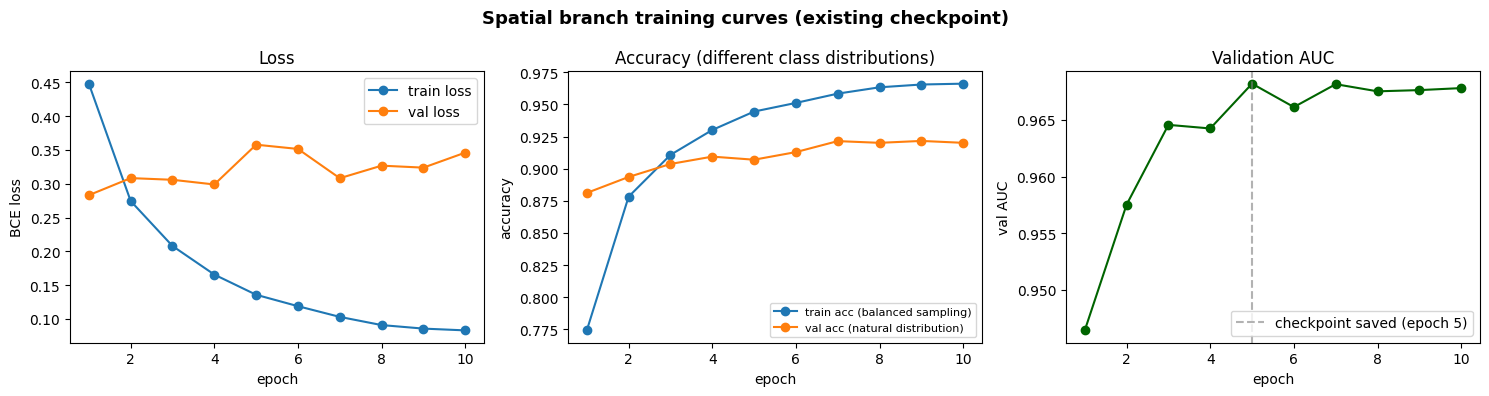

Best spatial checkpoint: epoch 5, val AUC 0.9682

Training uses class-balanced sampling, data augmentation, and dropout.
Validation uses the natural imbalanced distribution, no augmentation,
and model.eval(), which disables dropout. Train and validation accuracy
are therefore descriptive but should not be subtracted or interpreted
as a direct generalisation gap.

Assess possible overfitting using the combined pattern of decreasing
training loss, increasing validation loss, and plateauing or decreasing
validation AUC. Do not claim overfitting from accuracy difference alone.


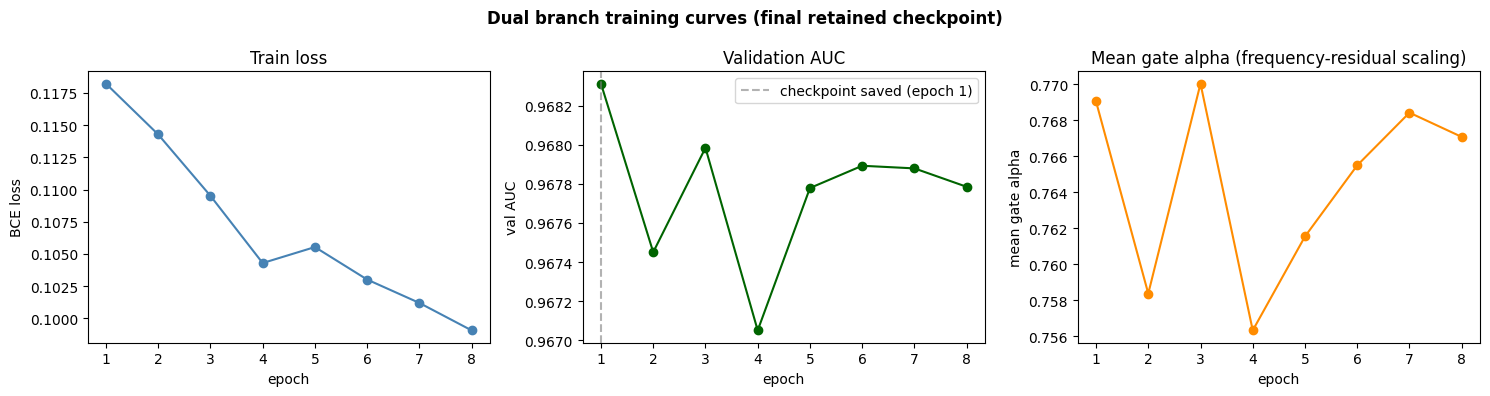

Final retained dual checkpoint: epoch 1, val AUC 0.9683, alpha 0.7691

Step 4 retained dual_best.pth as the official dual checkpoint.
dual_history.json is therefore the final retained model's training history.
It contains training loss, validation AUC and mean gate alpha, but not
validation loss or validation accuracy; those curves cannot be reconstructed
for this retained run.


In [10]:
# STEP 1 - Reconstruct training histories and learning-curve figures

with open(f"{CKPT_DIR}/spatial_history.json") as f:
    sp_hist = json.load(f)
with open(f"{CKPT_DIR}/dual_history.json") as f:
    du_hist = json.load(f)

sp_df = pd.DataFrame(sp_hist)
du_df = pd.DataFrame(du_hist)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Spatial branch training curves (existing checkpoint)",
             fontsize=13, fontweight="bold")

axes[0].plot(sp_df.epoch, sp_df.train_loss, label="train loss", marker="o")
axes[0].plot(sp_df.epoch, sp_df.val_loss,   label="val loss",   marker="o")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(sp_df.epoch, sp_df.train_acc,
             label="train acc (balanced sampling)", marker="o")
axes[1].plot(sp_df.epoch, sp_df.val_acc,
             label="val acc (natural distribution)", marker="o")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy (different class distributions)")
axes[1].legend(fontsize=8)

axes[2].plot(sp_df.epoch, sp_df.val_auc, marker="o", color="darkgreen")
best_ep = sp_df.loc[sp_df.val_auc.idxmax(), "epoch"]
axes[2].axvline(best_ep, linestyle="--", color="gray", alpha=0.6,
                 label=f"checkpoint saved (epoch {int(best_ep)})")
axes[2].set_xlabel("epoch"); axes[2].set_ylabel("val AUC")
axes[2].set_title("Validation AUC"); axes[2].legend()

plt.tight_layout()
plt.savefig(f"{EXP_DIR}/spatial_training_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Best spatial checkpoint: epoch {int(best_ep)}, "
      f"val AUC {sp_df.val_auc.max():.4f}")
print("\nTraining uses class-balanced sampling, data augmentation, and dropout.")
print("Validation uses the natural imbalanced distribution, no augmentation,")
print("and model.eval(), which disables dropout. Train and validation accuracy")
print("are therefore descriptive but should not be subtracted or interpreted")
print("as a direct generalisation gap.")
print("\nAssess possible overfitting using the combined pattern of decreasing")
print("training loss, increasing validation loss, and plateauing or decreasing")
print("validation AUC. Do not claim overfitting from accuracy difference alone.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Dual branch training curves (final retained checkpoint)", fontsize=12, fontweight="bold")

axes[0].plot(du_df.epoch, du_df.train_loss, marker="o", color="steelblue")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title("Train loss")

axes[1].plot(du_df.epoch, du_df.val_auc, marker="o", color="darkgreen")
best_ep_du = du_df.loc[du_df.val_auc.idxmax(), "epoch"]
axes[1].axvline(best_ep_du, linestyle="--", color="gray", alpha=0.6,
                 label=f"checkpoint saved (epoch {int(best_ep_du)})")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val AUC")
axes[1].set_title("Validation AUC"); axes[1].legend()

axes[2].plot(du_df.epoch, du_df.avg_alpha, marker="o", color="darkorange")
axes[2].set_xlabel("epoch"); axes[2].set_ylabel("mean gate alpha")
axes[2].set_title("Mean gate alpha (frequency-residual scaling)")

plt.tight_layout()
plt.savefig(f"{EXP_DIR}/dual_training_curves_final.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Final retained dual checkpoint: epoch {int(best_ep_du)}, "
      f"val AUC {du_df.val_auc.max():.4f}, "
      f"alpha {du_df.loc[du_df.val_auc.idxmax(), 'avg_alpha']:.4f}")
#print("\nThe existing dual history contains training loss, validation AUC,")
#print("and mean gate alpha. It does not contain validation loss or validation")
#print("accuracy, so a train-versus-validation loss gap cannot be reconstructed")
#print("for this existing run. The hyperparameter experiments should save these")
#print("additional values in their history.")
#print("\nThis figure is PRELIMINARY. If the hyperparameter search selects and")
#print("retrains a different configuration, regenerate this plot from the new")
#print("history before using it in the report.")

#updated
print("\nStep 4 retained dual_best.pth as the official dual checkpoint.")
print("dual_history.json is therefore the final retained model's training history.")
print("It contains training loss, validation AUC and mean gate alpha, but not")
print("validation loss or validation accuracy; those curves cannot be reconstructed")
print("for this retained run.")

## 4.3 Standardised video-level evaluation

The functions below implement the common evaluation contract used by all later
experiments: one row per video, one optional row per selected frame, explicit
coverage checks, mean-of-frame-probabilities aggregation and atomic CSV writes.

In [8]:
# STEP 2 - Reusable video evaluation and standardized prediction files

PRED_DIR = f"{EXP_DIR}/predictions"
os.makedirs(PRED_DIR, exist_ok=True)

# Crop indexing
def _index_crops(processed_root, split, has_split):
    by_video = {}
    for label_str in ["real", "fake"]:
        folder = (
            os.path.join(processed_root, split, label_str)
            if has_split else os.path.join(processed_root, label_str))
        if not os.path.exists(folder):
            continue
        for fname in os.listdir(folder):
            if not fname.lower().endswith(".jpg"):
                continue
            video_id = fname.rsplit("_f", 1)[0]
            by_video.setdefault((video_id, label_str), []).append(fname)
    for key in by_video:
        by_video[key].sort()
    return by_video

# Atomic CSV output
def _atomic_dataframe_save(dataframe, path):
    temporary_path = path + ".tmp"
    dataframe.to_csv(temporary_path, index=False)
    os.replace(temporary_path, path)

#  Prediction coverage check 
def validate_prediction_coverage(prediction_df,manifest_path,split,has_split,description,require_complete=True,):
    manifest = pd.read_csv(manifest_path)
    
    subset = (manifest[manifest["split"] == split].copy()if has_split else manifest.copy())
    if subset["video_id"].duplicated().any():
        raise RuntimeError(f"{description}: the manifest contains duplicate video IDs.")
    if prediction_df["video_id"].duplicated().any():
        raise RuntimeError(f"{description}: predictions contain duplicate video IDs." )

    expected_ids = set(subset["video_id"].astype(str))
    predicted_ids = set(prediction_df["video_id"].astype(str))
    missing_ids = sorted(expected_ids - predicted_ids)
    unexpected_ids = sorted(predicted_ids - expected_ids)
    if unexpected_ids:
        raise RuntimeError(
            f"{description}: predictions contain "
            f"{len(unexpected_ids)} unexpected video IDs."
        )
    coverage = (len(predicted_ids) / len(expected_ids)if expected_ids else 0.0)

    print(f"\n{description} coverage")
    print(f"  Expected  : {len(expected_ids):,}")
    print(f"  Evaluated : {len(predicted_ids):,}")
    print(f"  Missing   : {len(missing_ids):,}")
    print(f"  Coverage  : {coverage:.2%}")

    if require_complete and missing_ids:
        raise RuntimeError(f"{description}: {len(missing_ids)} expected videos were not evaluated.")

    return {
        "expected_videos": int(len(expected_ids)),
        "evaluated_videos": int(len(predicted_ids)),
        "missing_videos": int(len(missing_ids)),
        "coverage": float(coverage),
        "missing_video_ids": missing_ids,
    }

# Prediction generation 
def generate_predictions(model,manifest_path,split,processed_root,device,dual,model_name,max_frames=20,has_split=True,batch_size=20,condition="clean",output_tag=None,image_transform=None,):
    required_columns = {"video_id", "label", "label_str"}
    manifest = pd.read_csv(manifest_path)
    missing_columns = required_columns - set(manifest.columns)

    if missing_columns:
        raise ValueError(
            f"Manifest is missing required columns: "
            f"{sorted(missing_columns)}")

    if has_split and "split" not in manifest.columns:
        raise ValueError("Manifest must contain a split column when has_split=True.")
    if batch_size < 1:
        raise ValueError("batch_size must be at least 1.")
    if max_frames is not None and max_frames < 1:
        raise ValueError("max_frames must be at least 1 or None.")
    subset = (manifest[manifest["split"] == split].copy() if has_split else manifest.copy())

    if subset.empty:
        raise ValueError(f"No manifest rows found for split={split}.")

    crop_index = _index_crops(processed_root, split, has_split)
    model.eval()

    video_rows = []
    frame_rows = []
    missing_videos = 0
    unreadable_crops = 0

    for _, row in tqdm(subset.iterrows(), total=len(subset), desc=f"{model_name} {split} {condition}", ):
        label_str = row["label_str"]
        key = (row["video_id"], label_str)
        crops = crop_index.get(key)

        if not crops:
            missing_videos += 1
            continue

        if max_frames is not None and len(crops) > max_frames:
            selected_indices = np.linspace(0, len(crops) - 1, max_frames, dtype=int)
            crops = [crops[index] for index in selected_indices]

        folder = (
            os.path.join(processed_root, split, label_str)
            if has_split else os.path.join(processed_root, label_str)
        )

        if torch.device(device).type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        norm_images = []
        raw_images = []
        valid_crops = []

        for crop_name in crops:
            crop_path = os.path.join(folder, crop_name)
            bgr = cv2.imread(crop_path)

            if bgr is None:
                unreadable_crops += 1
                print(f"Warning: could not read {crop_path}")
                continue

            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            pil = PILImage.fromarray(rgb)

            if image_transform is not None:
                pil = image_transform(pil)
            norm_images.append(norm_transform(pil))

            if dual:
                raw_images.append(raw_transform(pil))
            valid_crops.append(crop_name)

        if not norm_images:
            missing_videos += 1
            continue

        frame_logits = []
        frame_scores = []
        frame_alphas = []

        for start in range(0, len(norm_images), batch_size):
            norm_chunk = torch.stack(norm_images[start:start + batch_size]).to(device)

            with torch.inference_mode():
                if dual:
                    raw_chunk = torch.stack(raw_images[start:start + batch_size]).to(device)
                    logits, alphas = model(norm_chunk, raw_chunk)
                    frame_alphas.extend(alphas.detach().float().view(-1).cpu().numpy().tolist())
                else:
                    logits = model(norm_chunk)

            logits_cpu = (logits.detach().float().view(-1).cpu())
            scores_cpu = torch.sigmoid(logits_cpu)
            frame_logits.extend(logits_cpu.numpy().tolist())

            frame_scores.extend(scores_cpu.numpy().tolist())

        if torch.device(device).type == "cuda":
            torch.cuda.synchronize()

        elapsed_ms = (time.perf_counter() - start_time) * 1000

        if len(frame_logits) != len(valid_crops):
            raise RuntimeError(f"Prediction count mismatch for {row['video_id']}.")

        if dual and len(frame_alphas) != len(valid_crops):
            raise RuntimeError(f"Gate-alpha count mismatch for {row['video_id']}.")

        category = (
            row["category"]
            if "category" in row.index and pd.notna(row["category"])
            else ""
        )

        for index, crop_name in enumerate(valid_crops):
            frame_rows.append({
                "video_id": row["video_id"],
                "frame_name": crop_name,
                "frame_order": int(index),
                "true_label": int(row["label"]),
                "category": category,
                "model": model_name,
                "condition": condition,
                "split": split,
                "frame_logit": float(frame_logits[index]),
                "frame_score": float(frame_scores[index]),
                "gate_alpha": (
                    float(frame_alphas[index])
                    if dual else np.nan
                ),
            })

        video_score = float(np.mean(frame_scores))
        mean_frame_logit = float(np.mean(frame_logits))

        mean_gate_alpha = (float(np.mean(frame_alphas))if dual else np.nan)
        epsilon = 1e-7
        clipped_score = min(max(video_score, epsilon),1 - epsilon,)
        video_score_log_odds = float(np.log(clipped_score / (1 - clipped_score)))

        video_rows.append({
            "video_id": row["video_id"],
            "true_label": int(row["label"]),
            "category": category,
            "model": model_name,
            "condition": condition,
            "n_frames": int(len(valid_crops)),
            "split": split,
            "video_score": video_score,
            "mean_frame_logit": mean_frame_logit,
            "video_score_log_odds": video_score_log_odds,
            "pred_label": 1 if video_score >= 0.5 else 0,
            "mean_gate_alpha": mean_gate_alpha,
            "scoring_pipeline_ms": float(elapsed_ms),
        })

    video_dataframe = pd.DataFrame(video_rows)
    frame_dataframe = pd.DataFrame(frame_rows)

    file_tag = (
        output_tag
        if output_tag is not None
        else f"{model_name}_{split}"
    )

    file_tag = (
        str(file_tag)
        .strip()
        .replace(" ", "_")
        .replace("/", "_")
    )

    if not file_tag:
        raise ValueError("output_tag must not be empty.")

    video_path = f"{PRED_DIR}/{file_tag}.csv"
    frame_path = f"{PRED_DIR}/{file_tag}_frames.csv"
    _atomic_dataframe_save(video_dataframe, video_path)
    _atomic_dataframe_save(frame_dataframe, frame_path)

    print(f"Saved {len(video_dataframe)} video rows to {video_path}")
    print(f"Saved {len(frame_dataframe)} frame rows to {frame_path}")
    print(f"Videos without usable crops: {missing_videos}")
    print(f"Unreadable crop files: {unreadable_crops}")

    return video_dataframe, frame_dataframe

# Video-level metrics
def metrics_from_predictions(dataframe, threshold=0.5):
    if dataframe.empty:
        raise ValueError("Prediction DataFrame is empty.")

    required_columns = {
        "true_label",
        "video_score",
        "scoring_pipeline_ms",
    }
    missing_columns = required_columns - set(dataframe.columns)
    if missing_columns:
        raise ValueError(
            f"Prediction DataFrame is missing columns: "
            f"{sorted(missing_columns)}"
        )
    labels = dataframe["true_label"].astype(int).to_numpy()
    scores = dataframe["video_score"].astype(float).to_numpy()
    predictions = (scores >= threshold).astype(int)

    if len(np.unique(labels)) < 2:
        raise ValueError("AUC and EER require both real and fake labels.")

    matrix = confusion_matrix(labels,predictions,labels=[0, 1],)

    true_negative, false_positive, false_negative, true_positive = (matrix.ravel())
    false_positive_rate = (false_positive / (false_positive + true_negative) if false_positive + true_negative else 0.0)
    false_negative_rate = (false_negative / (false_negative + true_positive) if false_negative + true_positive else 0.0)
    true_positive_rate = (true_positive / (true_positive + false_negative) if true_positive + false_negative else 0.0)
    true_negative_rate = (true_negative / (true_negative + false_positive) if true_negative + false_positive else 0.0)

    balanced_accuracy = (true_positive_rate + true_negative_rate) / 2
    fpr_curve, tpr_curve, _ = roc_curve(labels, scores)
    fnr_curve = 1 - tpr_curve
    eer_index = int( np.argmin(np.abs(fpr_curve - fnr_curve)))
    equal_error_rate = float((fpr_curve[eer_index] + fnr_curve[eer_index]) / 2)

    return {
        "auc": float(roc_auc_score(labels, scores)),
        "acc": float(accuracy_score(labels, predictions)),
        "balanced_acc": float(balanced_accuracy),
        "prec": float(precision_score(labels,predictions,zero_division=0,)),
        "rec": float(recall_score(labels,predictions,zero_division=0,)),
        "specificity": float(true_negative_rate),
        "f1": float(f1_score(labels,predictions,zero_division=0,)),
        "fpr": float(false_positive_rate),
        "fnr": float(false_negative_rate),
        "eer": equal_error_rate,
        "threshold": float(threshold),
        "cm": matrix.tolist(),
        "n_videos": int(len(dataframe)),
        "mean_scoring_pipeline_ms": float(dataframe["scoring_pipeline_ms"].mean()),
        "median_scoring_pipeline_ms": float(dataframe["scoring_pipeline_ms"].median()),
    }


print(
    "generate_predictions, metrics_from_predictions and "
    "validate_prediction_coverage ready"
)
print(f"Prediction CSVs will be saved to {PRED_DIR}")
print("Use a unique output_tag for every frame-count or robustness condition.")
print("Calibration must preserve the deployed mean-of-frame-probabilities aggregation.")

generate_predictions, metrics_from_predictions and validate_prediction_coverage ready
Prediction CSVs will be saved to /kaggle/working/experiments/predictions
Use a unique output_tag for every frame-count or robustness condition.
Calibration must preserve the deployed mean-of-frame-probabilities aggregation.


## 4.4 Bounded sequential hyperparameter screening

Learning rate is screened first at dropout 0.4; dropout is then screened at the
selected learning rate, reusing the shared trial. This coordinate-wise design
costs five runs but cannot establish a global optimum or interactions outside
the tested values.

In [7]:
# STEP 3 - FINAL sequential hyperparameter tuning (learning rate, then dropout)

import hashlib

# Search configuration
SEARCH_VERSION = "video_auc_v2"
SEARCH_SEED      = 42
TRIAL_EPOCHS     = 3
FULL_TRAIN_EPOCHS = 8
TIE_TOLERANCE    = 0.001
LR_CANDIDATES      = [1e-4, 5e-4, 1e-3]
DROPOUT_CANDIDATES = [0.2, 0.4, 0.5]
WEIGHT_DECAY = 1e-4
ETA_MIN      = 1e-6

# Configuration used by the existing full eight-epoch dual_best.pth
CURRENT_LR      = 5e-4
CURRENT_DROPOUT = 0.4

SEARCH_DIR = os.path.join(EXP_DIR,f"hyperparameter_search_trials_{SEARCH_VERSION}")

SUMMARY_PATH = os.path.join(EXP_DIR,f"hyperparameter_search_{SEARCH_VERSION}.json")

os.makedirs(SEARCH_DIR, exist_ok=True)

# Check that the saved data and training objects match the study protocol
if torch.device(device).type != "cuda":
    raise RuntimeError(
        "GPU not detected. Enable a Kaggle GPU, restart the session,then run Resume A, Cells 10-13, Step 2 and this cell.")

required_paths = [MANIFEST_FF,f"{CKPT_DIR}/spatial_best.pth", f"{CKPT_DIR}/dual_best.pth",]

for required_path in required_paths:
    if not os.path.exists(required_path):
        raise FileNotFoundError(f"Required file missing: {required_path}")

required_objects = {
    "train_loader"             : "Run Cell 11",
    "val_loader"               : "Run Cell 11",
    "DualBranchFinal"          : "Run Cell 12",
    "train_one_epoch"          : "Run Cell 13",
    "evaluate"                 : "Run Cell 13",
    "generate_predictions"     : "Run Step 2",
    "metrics_from_predictions" : "Run Step 2",
}

for object_name, instruction in required_objects.items():
    if object_name not in globals():
        raise RuntimeError(f"{object_name} is missing. {instruction} first.")

manifest_check = pd.read_csv(MANIFEST_FF)
required_columns = {"video_id", "label", "label_str", "split",}
missing_columns = required_columns - set(manifest_check.columns)

if missing_columns:
    raise ValueError(
        f"FF++ manifest is missing columns: "
        f"{sorted(missing_columns)}")

validation_manifest = manifest_check[manifest_check["split"] == "val"].copy()

if validation_manifest.empty:
    raise ValueError("The FF++ validation split is empty.")

if validation_manifest["label"].nunique() != 2:
    raise ValueError("Validation video AUC requires both real and fake labels.")

if len(train_loader.dataset) == 0:
    raise ValueError("The training dataset is empty.")

if len(val_loader.dataset) == 0:
    raise ValueError("The validation dataset is empty.")

# Experiment signature
def sha256_file(path, block_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as source:
        while True:
            block = source.read(block_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


SEARCH_CONFIG = {
    "version"                   : SEARCH_VERSION,
    "method"                    : "sequential_coordinate_search",
    "selection_epoch"           : "final_epoch_for_every_trial",
    "selection_metric"          : "validation_video_auc",
    "aggregation"               : "mean_frame_probability",
    "tie_break"                 : "validation_video_log_loss",
    "seed"                      : SEARCH_SEED,
    "trial_epochs"              : TRIAL_EPOCHS,
    "scheduler_t_max"           : FULL_TRAIN_EPOCHS,
    "tie_tolerance"             : TIE_TOLERANCE,
    "lr_candidates"             : LR_CANDIDATES,
    "dropout_candidates"        : DROPOUT_CANDIDATES,
    "weight_decay"              : WEIGHT_DECAY,
    "eta_min"                   : ETA_MIN,
    "train_frames"              : int(TRAIN_FRAMES),
    "batch_size"                : int(BS),
    "manifest_sha256"           : sha256_file(MANIFEST_FF),
    "spatial_checkpoint_sha256" : sha256_file(f"{CKPT_DIR}/spatial_best.pth"),
}

SEARCH_SIGNATURE = hashlib.sha256(
    json.dumps(SEARCH_CONFIG,sort_keys=True).encode("utf-8")).hexdigest()

print("STEP 3 PREFLIGHT PASSED")
print(f"  Device: {device}")
print(f"  Training crops : {len(train_loader.dataset):,}")
print(f"  Validation crops: {len(val_loader.dataset):,}")
print(f"  Validation videos: {len(validation_manifest):,}")
print(f"  Frames per video: {TRAIN_FRAMES}")
print(f"  Search : 5 trials x {TRIAL_EPOCHS} epochs")
print(f"  Signature : {SEARCH_SIGNATURE[:16]}...")

# Saving, reproducibility and selection helpers
def atomic_save_json(obj, path):
    """
    Saves through a temporary file so an interrupted write does not leave a
    partially written final JSON file.
    """
    temporary_path = path + ".tmp"
    with open(temporary_path, "w") as destination:
        json.dump(obj, destination, indent=2)
    os.replace(temporary_path, path)

def reset_trial_seed():
    """
    Resets randomness before every trial so candidates begin from comparable
    initialization and sampling states.
    """
    random.seed(SEARCH_SEED)
    np.random.seed(SEARCH_SEED)
    torch.manual_seed(SEARCH_SEED)
    torch.cuda.manual_seed_all(SEARCH_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def calculate_video_log_loss(prediction_df):
    """
    Binary log loss applied to the deployed video score: mean(sigmoid(frame_logits))
    """
    labels = prediction_df["true_label"].astype(int).to_numpy()
    scores = prediction_df["video_score"].astype(float).to_numpy()
    scores = np.clip(scores, 1e-7, 1 - 1e-7)
    loss = -np.mean(labels * np.log(scores)+ (1 - labels) * np.log(1 - scores))
    return float(loss)

def select_with_auc_tolerance(rows, final_tie_column):
    """
    Primary selection:maximum validation video AUC
    Near-tie:any candidate within TIE_TOLERANCE of maximum AUC
    Tie-break:lowest validation video log loss
    Final deterministic tie-break:lowest value of final_tie_column
    """
    if not rows:
        raise ValueError("No candidate results were supplied.")
    maximum_auc = max(float(row["video_auc"])for row in rows)
    close_rows = [row for row in rows if float(row["video_auc"]) >= maximum_auc - TIE_TOLERANCE]
    selected = min(close_rows,key=lambda row: (float(row["video_log_loss"]),float(row[final_tie_column]),),)
    return selected

# One controlled screening trial
search_log = []
def run_trial(lr, dropout, tag):
    lr = float(lr)
    dropout = float(dropout)
    trial_path = os.path.join(SEARCH_DIR,f"{tag}.json")

    # Reuse only a fully completed trial produced by this exact search design.
    if os.path.exists(trial_path):
        with open(trial_path) as source:
            result = json.load(source)

        if result.get("search_signature") != SEARCH_SIGNATURE:
            raise RuntimeError(
                f"Incompatible old trial found:\n{trial_path}\n"
                "Do not reuse this file. Change SEARCH_VERSION before running a modified search.")

        if not np.isclose(result["lr"],lr,rtol=0,atol=1e-12,):
            raise RuntimeError(f"Stored learning rate does not match trial {tag}.")

        if not np.isclose(result["dropout"],dropout,rtol=0,atol=1e-12,):
            raise RuntimeError(f"Stored dropout does not match trial {tag}.")

        print(f"\nReusing completed trial {tag}: video AUC={result['video_auc']:.4f}")

        search_log.append(result)
        return result

    reset_trial_seed()
    trial = DualBranchFinal(spatial_ckpt=f"{CKPT_DIR}/spatial_best.pth",dropout=dropout,).to(device)

    for parameter in trial.spatial.parameters():
        parameter.requires_grad = False

    optimizer = optim.AdamW([
            {"params": trial.freq.parameters(),"lr": lr,},
            {"params": trial.freq_proj.parameters(),"lr": lr,},
            {"params": trial.gate.parameters(),"lr": lr,},
            {"params": trial.classifier.parameters(),"lr": lr,},],
        weight_decay=WEIGHT_DECAY,)

    # T_max remains eight so the screening run follows the first three epochs
    # of the same LR trajectory that will be used by the full eight-epoch run.
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=FULL_TRAIN_EPOCHS,eta_min=ETA_MIN,)

    criterion = nn.BCEWithLogitsLoss()
    history = []

    print(f"\nTRIAL {tag}:lr={lr:.0e}, dropout={dropout}")

    for epoch in range(1, TRIAL_EPOCHS + 1):
        epoch_start = time.time()
        train_loss, train_acc = train_one_epoch(trial,train_loader,optimizer,criterion,device,dual=True,freeze_spatial=True,)
        val_loss, val_acc, frame_val_auc, avg_alpha = evaluate(trial,val_loader,criterion,device,dual=True,)
        scheduler.step()
        elapsed = time.time() - epoch_start

        history.append({
            "epoch"            : int(epoch),
            "train_loss"       : float(train_loss),
            "train_acc"        : float(train_acc),
            "frame_val_loss"   : float(val_loss),
            "frame_val_acc"    : float(val_acc),
            "frame_val_auc"    : float(frame_val_auc),
            "avg_alpha"        : float(avg_alpha),
            "lr_after_epoch"   :
                float(optimizer.param_groups[0]["lr"]),
            "epoch_seconds"    : float(elapsed),
        })

        print(
            f"  epoch {epoch}/{TRIAL_EPOCHS} | "
            f"train loss {train_loss:.4f} "
            f"acc {train_acc:.3f} | "
            f"frame val loss {val_loss:.4f} "
            f"acc {val_acc:.3f} "
            f"AUC {frame_val_auc:.4f} | "
            f"alpha {avg_alpha:.4f} | "
            f"{elapsed:.0f}s"
        )

    # All candidates receive video-level evaluation after exactly epoch 3.
    video_df, frame_df = generate_predictions(
        model=trial,
        manifest_path=MANIFEST_FF,
        split="val",
        processed_root=FF_PROCESSED,
        device=device,
        dual=True,
        model_name=f"hparam_{tag}",
        max_frames=TRAIN_FRAMES,
        has_split=True,
        batch_size=20,
        condition="clean",
        output_tag=(
            f"{SEARCH_VERSION}_{tag}_"
            f"val_epoch{TRIAL_EPOCHS}"
        ),
    )

    expected_validation_videos = len(validation_manifest)

    if len(video_df) != expected_validation_videos:
        raise RuntimeError(
            f"Trial {tag} produced {len(video_df):,} validation videos; "
            f"expected {expected_validation_videos:,}.")

    video_metrics = metrics_from_predictions(video_df)
    final_video_log_loss = calculate_video_log_loss(video_df)

    result = {
        "search_signature"    : SEARCH_SIGNATURE,
        "tag"                 : tag,
        "lr"                  : lr,
        "dropout"             : dropout,
        "trial_epochs"        : TRIAL_EPOCHS,
        "selection_epoch"     : TRIAL_EPOCHS,
        "video_auc"           : float(video_metrics["auc"]),
        "video_log_loss"      : final_video_log_loss,
        "video_metrics"       : video_metrics,
        "final_frame_val_auc" :
            float(history[-1]["frame_val_auc"]),
        "history"             : history,
    }

    atomic_save_json(result, trial_path)

    print(
        f"  FINAL-EPOCH VIDEO AUC "
        f"{result['video_auc']:.4f} | "
        f"video log loss "
        f"{result['video_log_loss']:.4f}"
    )
    print(f"  Completed trial saved to {trial_path}")

    search_log.append(result)

    del trial
    del optimizer
    del scheduler
    del criterion
    del video_df
    del frame_df
    torch.cuda.empty_cache()

    return result

def result_row(result):
    return {
        "lr"                   : float(result["lr"]),
        "dropout"              : float(result["dropout"]),
        "video_auc"            : float(result["video_auc"]),
        "video_log_loss"       :
            float(result["video_log_loss"]),
        "frame_auc_diagnostic" :
            float(result["final_frame_val_auc"]),
    }

# Stage 1: learning-rate tuning
print("\nSTAGE 1: learning-rate tuning(dropout fixed at 0.4)")
stage1_results = []
for lr in LR_CANDIDATES:
    tag = f"lr{lr:.0e}_do0.4"
    stage1_results.append(run_trial(lr=lr,dropout=0.4,tag=tag,))

stage1_rows = [result_row(result) for result in stage1_results]
stage1_df = pd.DataFrame(stage1_rows).sort_values("lr")
best_lr_row = select_with_auc_tolerance(stage1_rows,final_tie_column="lr",)
best_lr = float(best_lr_row["lr"])

print("\nStage 1 summary")
print(stage1_df.to_string(index=False))

print(
    f"\nSelected LR: {best_lr:.0e} | "
    f"video AUC {best_lr_row['video_auc']:.4f} | "
    f"video log loss "
    f"{best_lr_row['video_log_loss']:.4f}"
)

# Stage 2: dropout tuning
print(f"\nSTAGE 2 - dropout tuning (LR fixed at {best_lr:.0e})")
stage2_results = []
for dropout in [
    value
    for value in DROPOUT_CANDIDATES
    if not np.isclose(value,CURRENT_DROPOUT,rtol=0,atol=1e-12,)]:
    tag = f"lr{best_lr:.0e}_do{dropout}"
    stage2_results.append(run_trial(lr=best_lr,dropout=dropout,tag=tag,))

# Reuse the dropout=0.4 result at the winning LR from Stage 1.
default_result = [
    result
    for result in stage1_results
    if np.isclose(result["lr"],best_lr,rtol=0,atol=1e-12,)]

if len(default_result) != 1:
    raise RuntimeError("Could not uniquely recover the winning-LR/dropout=0.4 result.")

stage2_results.append(default_result[0])
stage2_rows = [result_row(result) for result in stage2_results]
stage2_df = pd.DataFrame(stage2_rows).sort_values("dropout")
best_combo = select_with_auc_tolerance(stage2_rows,final_tie_column="dropout",)
selected_lr = float(best_combo["lr"])
selected_dropout = float(best_combo["dropout"])

print("\nStage 2 summary")
print(stage2_df.to_string(index=False))

print("FINAL SELECTED HYPERPARAMETERS")

print(f"Learning rate : {selected_lr:.0e}")
print(f"Dropout : {selected_dropout}")
print(f"Screening epochs: {TRIAL_EPOCHS}")
print(f"Validation video AUC: {best_combo['video_auc']:.4f}")
print(f"Validation video loss:{best_combo['video_log_loss']:.4f}")
print(f"  Frame AUC diagnostic:{best_combo['frame_auc_diagnostic']:.4f}")

# Conditional retraining decision
same_as_current = (np.isclose(selected_lr,CURRENT_LR,rtol=0,atol=1e-12,)and
    np.isclose(selected_dropout,CURRENT_DROPOUT,rtol=0,atol=1e-12,))

if same_as_current:
    RETRAIN_DECISION = "keep_current"
    CANDIDATE_DUAL_CHECKPOINT = None
    FINAL_DUAL_CHECKPOINT = f"{CKPT_DIR}/dual_best.pth"

    print("\nRETRAINING DECISION: KEEP CURRENT MODEL")
    print("The selected configuration exactly matches the existing full eight-epoch model.")
    print("Neither the spatial nor dual model needs retraining.")

else:
    RETRAIN_DECISION = "train_and_compare"
    CANDIDATE_DUAL_CHECKPOINT = (f"{CKPT_DIR}/dual_tuned_best.pth")
    FINAL_DUAL_CHECKPOINT = None

    print("\nRETRAINING DECISION: TRAIN CANDIDATE AND COMPARE")
    print("The selected configuration differs from the existing model.")
    print("Run Step 4 to train the frequency/fusion components for eight epochs.")
    print("The spatial branch remains frozen.")
    print("dual_tuned_best.pth will remain a candidate until it is compared")
    print("with dual_best.pth using validation video-level metrics.")

# Save final search record
summary = {
    "search_signature" : SEARCH_SIGNATURE,
    "search_config" :SEARCH_CONFIG,
    "stage1" : stage1_rows,
    "stage2":stage2_rows,
    "selected_lr":selected_lr,
    "selected_dropout" : selected_dropout,
    "selected_validation_video_auc" :float(best_combo["video_auc"]),
    "selected_validation_video_log_loss": float(best_combo["video_log_loss"]),
    "decision" : RETRAIN_DECISION,
    "candidate_dual_checkpoint": CANDIDATE_DUAL_CHECKPOINT,
    "final_dual_checkpoint": FINAL_DUAL_CHECKPOINT,
    "unique_trial_results" :search_log,
}

atomic_save_json(summary,SUMMARY_PATH,)

print(f"\nSaved search summary to {SUMMARY_PATH}")
print(f"RETRAIN_DECISION = '{RETRAIN_DECISION}'")

if FINAL_DUAL_CHECKPOINT is not None:
    print(f"FINAL_DUAL_CHECKPOINT = '{FINAL_DUAL_CHECKPOINT}'")
else:
    print(f"CANDIDATE_DUAL_CHECKPOINT = '{CANDIDATE_DUAL_CHECKPOINT}'")
    print("FINAL_DUAL_CHECKPOINT remains undecided until Step 4 comparison.")

STEP 3 PREFLIGHT PASSED
  Device: cuda
  Training crops : 67,248
  Validation crops: 14,160
  Validation videos: 719
  Frames per video: 20
  Search : 5 trials x 3 epochs
  Signature : cd14386256bb0b2c...

STAGE 1: learning-rate tuning(dropout fixed at 0.4)
  Spatial weights loaded (val AUC=0.9682)

TRIAL lr1e-04_do0.4:lr=1e-04, dropout=0.4
  epoch 1/3 | train loss 0.1170 acc 0.954 | frame val loss 0.2962 acc 0.918 AUC 0.9658 | alpha 0.1507 | 441s
  epoch 2/3 | train loss 0.1091 acc 0.958 | frame val loss 0.2780 acc 0.921 AUC 0.9677 | alpha 0.1230 | 454s
  epoch 3/3 | train loss 0.1050 acc 0.959 | frame val loss 0.3100 acc 0.920 AUC 0.9678 | alpha 0.1077 | 478s


hparam_lr1e-04_do0.4 val clean:   0%|          | 0/719 [00:00<?, ?it/s]

Saved 719 video rows to /kaggle/working/experiments/predictions/video_auc_v2_lr1e-04_do0.4_val_epoch3.csv
Saved 14160 frame rows to /kaggle/working/experiments/predictions/video_auc_v2_lr1e-04_do0.4_val_epoch3_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0
  FINAL-EPOCH VIDEO AUC 0.9817 | video log loss 0.1522
  Completed trial saved to /kaggle/working/experiments/hyperparameter_search_trials_video_auc_v2/lr1e-04_do0.4.json
  Spatial weights loaded (val AUC=0.9682)

TRIAL lr5e-04_do0.4:lr=5e-04, dropout=0.4
  epoch 1/3 | train loss 0.1184 acc 0.954 | frame val loss 0.3078 acc 0.920 AUC 0.9662 | alpha 0.0761 | 483s
  epoch 2/3 | train loss 0.1111 acc 0.958 | frame val loss 0.2868 acc 0.923 AUC 0.9679 | alpha 0.0746 | 468s
  epoch 3/3 | train loss 0.1065 acc 0.959 | frame val loss 0.3257 acc 0.921 AUC 0.9680 | alpha 0.0710 | 483s


hparam_lr5e-04_do0.4 val clean:   0%|          | 0/719 [00:00<?, ?it/s]

Saved 719 video rows to /kaggle/working/experiments/predictions/video_auc_v2_lr5e-04_do0.4_val_epoch3.csv
Saved 14160 frame rows to /kaggle/working/experiments/predictions/video_auc_v2_lr5e-04_do0.4_val_epoch3_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0
  FINAL-EPOCH VIDEO AUC 0.9816 | video log loss 0.1530
  Completed trial saved to /kaggle/working/experiments/hyperparameter_search_trials_video_auc_v2/lr5e-04_do0.4.json
  Spatial weights loaded (val AUC=0.9682)

TRIAL lr1e-03_do0.4:lr=1e-03, dropout=0.4
  epoch 1/3 | train loss 0.1196 acc 0.954 | frame val loss 0.2983 acc 0.919 AUC 0.9656 | alpha 0.0469 | 475s
  epoch 2/3 | train loss 0.1113 acc 0.957 | frame val loss 0.2849 acc 0.922 AUC 0.9681 | alpha 0.0774 | 492s
  epoch 3/3 | train loss 0.1072 acc 0.959 | frame val loss 0.3410 acc 0.919 AUC 0.9677 | alpha 0.0696 | 478s


...

Saved 719 video rows to /kaggle/working/experiments/predictions/video_auc_v2_lr1e-03_do0.4_val_epoch3.csv
Saved 14160 frame rows to /kaggle/working/experiments/predictions/video_auc_v2_lr1e-03_do0.4_val_epoch3_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0
  FINAL-EPOCH VIDEO AUC 0.9815 | video log loss 0.1576
  Completed trial saved to /kaggle/working/experiments/hyperparameter_search_trials_video_auc_v2/lr1e-03_do0.4.json

Stage 1 summary
    lr  dropout  video_auc  video_log_loss  frame_auc_diagnostic
0.0001      0.4   0.981715        0.152216              0.967845
0.0005      0.4   0.981630        0.152996              0.968042
0.0010      0.4   0.981522        0.157604              0.967689

Selected LR: 1e-04 | video AUC 0.9817 | video log loss 0.1522

STAGE 2 - dropout tuning (LR fixed at 1e-04)
  Spatial weights loaded (val AUC=0.9682)

TRIAL lr1e-04_do0.2:lr=1e-04, dropout=0.2
  epoch 1/3 | train loss 0.1161 acc 0.954 | frame val loss 0.3009 acc 0.919 AUC 0

hparam_lr1e-04_do0.2 val clean:   0%|          | 0/719 [00:00<?, ?it/s]

Saved 719 video rows to /kaggle/working/experiments/predictions/video_auc_v2_lr1e-04_do0.2_val_epoch3.csv
Saved 14160 frame rows to /kaggle/working/experiments/predictions/video_auc_v2_lr1e-04_do0.2_val_epoch3_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0
  FINAL-EPOCH VIDEO AUC 0.9816 | video log loss 0.1525
  Completed trial saved to /kaggle/working/experiments/hyperparameter_search_trials_video_auc_v2/lr1e-04_do0.2.json
  Spatial weights loaded (val AUC=0.9682)

TRIAL lr1e-04_do0.5:lr=1e-04, dropout=0.5
  epoch 1/3 | train loss 0.1173 acc 0.954 | frame val loss 0.2963 acc 0.919 AUC 0.9661 | alpha 0.1546 | 487s
  epoch 2/3 | train loss 0.1096 acc 0.958 | frame val loss 0.2768 acc 0.922 AUC 0.9678 | alpha 0.1232 | 487s
  epoch 3/3 | train loss 0.1055 acc 0.959 | frame val loss 0.3123 acc 0.920 AUC 0.9679 | alpha 0.1094 | 481s


hparam_lr1e-04_do0.5 val clean:   0%|          | 0/719 [00:00<?, ?it/s]

Saved 719 video rows to /kaggle/working/experiments/predictions/video_auc_v2_lr1e-04_do0.5_val_epoch3.csv
Saved 14160 frame rows to /kaggle/working/experiments/predictions/video_auc_v2_lr1e-04_do0.5_val_epoch3_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0
  FINAL-EPOCH VIDEO AUC 0.9818 | video log loss 0.1523
  Completed trial saved to /kaggle/working/experiments/hyperparameter_search_trials_video_auc_v2/lr1e-04_do0.5.json

Stage 2 summary
    lr  dropout  video_auc  video_log_loss  frame_auc_diagnostic
0.0001      0.2   0.981558        0.152514              0.967901
0.0001      0.4   0.981715        0.152216              0.967845
0.0001      0.5   0.981824        0.152255              0.967918
FINAL SELECTED HYPERPARAMETERS
Learning rate : 1e-04
Dropout : 0.4
Screening epochs: 3
Validation video AUC: 0.9817
Validation video loss:0.1522
  Frame AUC diagnostic:0.9678

RETRAINING DECISION: TRAIN CANDIDATE AND COMPARE
The selected configuration differs from the existi

## 4.5 Full-budget candidate comparison

The retained checkpoint is first measured with the same validation-video
pipeline as the screening trials. The displayed 3-epoch and 8-epoch values are
descriptive only because their budgets differ. Step 4 then trains the changed
configuration for the full eight epochs and makes the final validation-only
comparison on matched footing.

In [10]:
# Validation check ahead of full candidate retraining
# Establishes the current checkpoint's validation video AUC on the same
# evaluation pipeline used for the hyperparameter trials, so that the
# subsequent decision to retrain or retain the checkpoint is made on a directly comparable basis.

current_dual = DualBranchFinal(dropout=0.4).to(device)
ckpt = torch.load(f"{CKPT_DIR}/dual_best.pth", map_location=device, weights_only=False)
current_dual.load_state_dict(ckpt["model_state"])

current_val_df, _ = generate_predictions(
    model=current_dual, manifest_path=MANIFEST_FF, split="val",
    processed_root=FF_PROCESSED, device=device, dual=True,
    model_name="dual_current", max_frames=TRAIN_FRAMES, has_split=True,
    batch_size=20, condition="clean",
    output_tag="video_auc_v2_current_dual_val_check",
)

current_val_metrics = metrics_from_predictions(current_val_df)
current_val_log_loss = calculate_video_log_loss(current_val_df)

print(f"\nCurrent dual_best.pth (lr=5e-4, dropout=0.4, 8 epochs)")
print(f"  Video AUC (val split)      : {current_val_metrics['auc']:.6f}")
print(f"  Video log loss (val split) : {current_val_log_loss:.6f}")

print(f"\nBest 3-epoch screening trial (lr=1e-4, dropout=0.4)")
print(f"  Video AUC (val split)      : 0.981715")
print(f"  Video log loss (val split) : 0.152216")

diff = current_val_metrics['auc'] - 0.981715
print(f"\nDifference (current - best trial): {diff:+.6f}")

if abs(diff) < 0.001:
    print("\nCurrent model already sits inside the same statistically flat")
    print("region as all five trial configurations. Retraining is unlikely")
    print("to produce a meaningfully different result. Recommend: KEEP current,")
    print("report hyperparameter insensitivity as a finding, skip Step 4.")
else:
    print("\nA real gap exists on matched footing. Proceed to Step 4 and")
    print("retrain the candidate for the full 8 epochs, then re-compare.")

del current_dual
torch.cuda.empty_cache()

dual_current val clean:   0%|          | 0/719 [00:00<?, ?it/s]

Saved 719 video rows to /kaggle/working/experiments/predictions/video_auc_v2_current_dual_val_check.csv
Saved 14160 frame rows to /kaggle/working/experiments/predictions/video_auc_v2_current_dual_val_check_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0

Current dual_best.pth (lr=5e-4, dropout=0.4, 8 epochs)
  Video AUC (val split)      : 0.983273
  Video log loss (val split) : 0.144116

Best 3-epoch screening trial (lr=1e-4, dropout=0.4)
  Video AUC (val split)      : 0.981715
  Video log loss (val split) : 0.152216

Difference (current - best trial): +0.001558

A real gap exists on matched footing. Proceed to Step 4 and
retrain the candidate for the full 8 epochs, then re-compare.


In [7]:
# STEP 4 - Full 8-epoch candidate training and final validation comparison
# Selects epochs and models using validation VIDEO AUC, video log loss as
# the tie-break inside the tolerance from Step 3. Test split is not used.
# The tuned candidate will have a complete training history containing
# training loss/accuracy and validation loss/accuracy, frame AUC,
# video AUC, video log loss and gate alpha.
import hashlib

STEP3_SUMMARY_PATH = f"{EXP_DIR}/hyperparameter_search_video_auc_v2.json"
CURRENT_CKPT_PATH  = f"{CKPT_DIR}/dual_best.pth"
TUNED_CKPT_PATH    = f"{CKPT_DIR}/dual_tuned_best.pth"

if torch.device(device).type != "cuda":
    raise RuntimeError("GPU not detected. Enable a Kaggle GPU, then run "
                       "Resume A, Cells 10-13, Step 2 and this Step 4 cell.")

required_objects = {
    "train_loader": "Cell 11", "val_loader": "Cell 11",
    "DualBranchFinal": "Cell 12", "train_one_epoch": "Cell 13",
    "evaluate": "Cell 13", "generate_predictions": "Step 2",
    "metrics_from_predictions": "Step 2",
}
for name, instr in required_objects.items():
    if name not in globals():
        raise RuntimeError(f"{name} is missing. Run {instr} first.")

required_paths = [STEP3_SUMMARY_PATH, MANIFEST_FF,
                   f"{CKPT_DIR}/spatial_best.pth", CURRENT_CKPT_PATH]
for p in required_paths:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Required file missing: {p}")

with open(STEP3_SUMMARY_PATH) as f:
    step3_summary = json.load(f)
if step3_summary["decision"] != "train_and_compare":
    raise RuntimeError("Step 3 says candidate training is not required.")

SEARCH_SIGNATURE = step3_summary["search_signature"]
SEARCH_CONFIG    = step3_summary["search_config"]

# Verify that Step 4 uses the exact data and spatial checkpoint used by Step 3
def step4_sha256_file(path, block_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as source:
        while True:
            block = source.read(block_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()

if int(TRAIN_FRAMES) != int(SEARCH_CONFIG["train_frames"]):
    raise RuntimeError("TRAIN_FRAMES differs from the Step 3 search configuration.")

if int(BS) != int(SEARCH_CONFIG["batch_size"]):
    raise RuntimeError("Batch size differs from the Step 3 search configuration.")

current_manifest_hash = step4_sha256_file(MANIFEST_FF)
expected_manifest_hash = SEARCH_CONFIG["manifest_sha256"]

if current_manifest_hash != expected_manifest_hash:
    raise RuntimeError("ff_manifest_final.csv has changed since Step 3.Do not continue with incompatible data.")

spatial_path = f"{CKPT_DIR}/spatial_best.pth"
current_spatial_hash = step4_sha256_file(spatial_path)
expected_spatial_hash = SEARCH_CONFIG["spatial_checkpoint_sha256"]

if current_spatial_hash != expected_spatial_hash:
    raise RuntimeError("spatial_best.pth has changed since Step 3.Do not continue with an incompatible spatial model.")

SELECTED_LR      = float(step3_summary["selected_lr"])
SELECTED_DROPOUT = float(step3_summary["selected_dropout"])
SEARCH_SEED       = int(SEARCH_CONFIG["seed"])
FULL_TRAIN_EPOCHS = int(SEARCH_CONFIG["scheduler_t_max"])
TIE_TOLERANCE     = float(SEARCH_CONFIG["tie_tolerance"])
WEIGHT_DECAY      = float(SEARCH_CONFIG["weight_decay"])
ETA_MIN           = float(SEARCH_CONFIG["eta_min"])
CURRENT_LR, CURRENT_DROPOUT = 5e-4, 0.4
LOSS_TIE_EPSILON = 1e-6

validation_manifest = pd.read_csv(MANIFEST_FF)
validation_manifest = validation_manifest[validation_manifest["split"] == "val"].copy()
if validation_manifest.empty:
    raise ValueError("The validation split is empty.")
if validation_manifest["label"].nunique() != 2:
    raise ValueError("Validation AUC requires real and fake videos.")
EXPECTED_VAL_VIDEOS = len(validation_manifest)

STEP4_VERSION = SEARCH_CONFIG["version"]
STEP4_DIR     = os.path.join(EXP_DIR, f"step4_full_training_{STEP4_VERSION}")
EPOCH_DIR     = os.path.join(STEP4_DIR, "epoch_checkpoints")
PROGRESS_PATH = os.path.join(STEP4_DIR, "training_progress.pth")
HISTORY_PATH  = os.path.join(STEP4_DIR, "dual_tuned_history.json")
DECISION_PATH = os.path.join(EXP_DIR, f"step4_final_decision_{STEP4_VERSION}.json")
os.makedirs(EPOCH_DIR, exist_ok=True)

free_gb = shutil.disk_usage("/kaggle/working").free / 1e9
if free_gb < 2.0:
    raise RuntimeError(f"Only {free_gb:.2f} GB free. Step 4 needs ~2 GB.")

print("STEP 4 PREFLIGHT PASSED")
print(f"  Candidate          : LR={SELECTED_LR:.0e}, dropout={SELECTED_DROPOUT}")
print(f"  Training budget    : {FULL_TRAIN_EPOCHS} epochs")
print(f"  Validation videos  : {EXPECTED_VAL_VIDEOS:,}")
print(f"  AUC tolerance      : {TIE_TOLERANCE}")
print(f"  Available disk     : {free_gb:.2f} GB")
print("  Test split         : NOT USED")


def step4_atomic_json(obj, path):
    tmp = path + ".tmp"
    with open(tmp, "w") as f:
        json.dump(obj, f, indent=2)
    os.replace(tmp, path)


def step4_atomic_torch(obj, path):
    tmp = path + ".tmp"
    torch.save(obj, tmp)
    os.replace(tmp, path)


def step4_set_seed():
    random.seed(SEARCH_SEED); np.random.seed(SEARCH_SEED)
    torch.manual_seed(SEARCH_SEED); torch.cuda.manual_seed_all(SEARCH_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def step4_capture_rng():
    return {"python": random.getstate(), "numpy": np.random.get_state(),
            "torch": torch.get_rng_state(), "cuda": torch.cuda.get_rng_state_all()}


def step4_restore_rng(state):
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch"].cpu())
    cuda_states = [
        cuda_state.cpu()
        for cuda_state in state["cuda"]]
    torch.cuda.set_rng_state_all(cuda_states)

def step4_video_log_loss(df):
    labels = df["true_label"].astype(int).to_numpy()
    scores = np.clip(df["video_score"].astype(float).to_numpy(), 1e-7, 1 - 1e-7)
    return float(-np.mean(labels * np.log(scores) + (1 - labels) * np.log(1 - scores)))


def step4_validate_predictions(df, description):
    if len(df) != EXPECTED_VAL_VIDEOS:
        raise RuntimeError(f"{description} produced {len(df):,} videos; "
                           f"expected {EXPECTED_VAL_VIDEOS:,}.")
    if df["video_id"].duplicated().any():
        raise RuntimeError(f"{description} contains duplicate video IDs.")
    if set(df["video_id"]) != set(validation_manifest["video_id"]):
        raise RuntimeError(f"{description} video IDs do not match the manifest.")


def step4_select_epoch(history):
    max_auc = max(r["video_auc"] for r in history)
    close = [r for r in history if r["video_auc"] >= max_auc - TIE_TOLERANCE]
    return min(close, key=lambda r: (r["video_log_loss"], r["epoch"]))


def step4_load_model(checkpoint_path, dropout):
    model = DualBranchFinal(spatial_ckpt=None, dropout=dropout).to(device)
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, ckpt


def step4_evaluate_checkpoint(checkpoint_path, dropout, model_name, output_tag):
    model, ckpt = step4_load_model(checkpoint_path, dropout)
    video_df, frame_df = generate_predictions(
        model=model, manifest_path=MANIFEST_FF, split="val",
        processed_root=FF_PROCESSED, device=device, dual=True,
        model_name=model_name, max_frames=TRAIN_FRAMES, has_split=True,
        batch_size=20, condition="clean", output_tag=output_tag)
    step4_validate_predictions(video_df, model_name)
    metrics = metrics_from_predictions(video_df)
    log_loss = step4_video_log_loss(video_df)
    del model, video_df, frame_df
    torch.cuda.empty_cache()
    return metrics, log_loss, ckpt


def run_step4():
    if os.path.exists(DECISION_PATH):
        with open(DECISION_PATH) as f:
            completed = json.load(f)
        # Signature check: prevents mixing results from different search versions
        if completed.get("search_signature") != SEARCH_SIGNATURE:
            raise RuntimeError("Existing Step 4 decision has a different search signature.")

        # ensures the checkpoint still exists
        final_checkpoint = completed.get("final_checkpoint")
    
        if not final_checkpoint or not os.path.exists(final_checkpoint):
            raise FileNotFoundError(
                "Step 4 decision exists, but its final checkpoint is missing: "
                f"{final_checkpoint}"
            )            
        print("\nStep 4 was already completed.")
        print(f"  Decision         : {completed['decision']}")
        print(f"  Final checkpoint : {completed['final_checkpoint']}")
        return completed

    step4_set_seed()
    tuned_model = DualBranchFinal(spatial_ckpt=f"{CKPT_DIR}/spatial_best.pth",
                                  dropout=SELECTED_DROPOUT).to(device)
    for p in tuned_model.spatial.parameters():
        p.requires_grad = False

    optimizer = optim.AdamW([
        {"params": tuned_model.freq.parameters(),       "lr": SELECTED_LR},
        {"params": tuned_model.freq_proj.parameters(),  "lr": SELECTED_LR},
        {"params": tuned_model.gate.parameters(),       "lr": SELECTED_LR},
        {"params": tuned_model.classifier.parameters(), "lr": SELECTED_LR},
    ], weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FULL_TRAIN_EPOCHS,
                                                      eta_min=ETA_MIN)
    criterion = nn.BCEWithLogitsLoss()
    tuned_history, start_epoch = [], 1

    if os.path.exists(PROGRESS_PATH):
        progress = torch.load(PROGRESS_PATH, map_location=device, weights_only=False)
        matches = (progress.get("search_signature") == SEARCH_SIGNATURE
                   and np.isclose(progress.get("lr", np.nan), SELECTED_LR, rtol=0, atol=1e-12)
                   and np.isclose(progress.get("dropout", np.nan), SELECTED_DROPOUT, rtol=0, atol=1e-12)
                   and progress.get("epochs") == FULL_TRAIN_EPOCHS)
        if not matches:
            raise RuntimeError("Existing Step 4 progress is incompatible. Not overwritten.")
        tuned_model.load_state_dict(progress["model_state"])
        optimizer.load_state_dict(progress["optimizer_state"])
        scheduler.load_state_dict(progress["scheduler_state"])
        tuned_history = progress["history"]
        start_epoch = int(progress["completed_epoch"]) + 1
        step4_restore_rng(progress["rng_state"])
        print(f"\nResuming Step 4 after epoch {start_epoch - 1}.")

    print(f"\nTraining candidate from epoch {start_epoch} to epoch {FULL_TRAIN_EPOCHS}")

    for epoch in range(start_epoch, FULL_TRAIN_EPOCHS + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(tuned_model, train_loader, optimizer,
                                                 criterion, device, dual=True,
                                                 freeze_spatial=True)
        val_loss, val_acc, frame_val_auc, avg_alpha = evaluate(tuned_model, val_loader,
                                                                criterion, device, dual=True)
        scheduler.step()

        video_df, frame_df = generate_predictions(
            model=tuned_model, manifest_path=MANIFEST_FF, split="val",
            processed_root=FF_PROCESSED, device=device, dual=True,
            model_name=f"dual_tuned_epoch_{epoch:02d}", max_frames=TRAIN_FRAMES,
            has_split=True, batch_size=20, condition="clean",
            output_tag=f"step4_{STEP4_VERSION}_tuned_val_epoch{epoch:02d}")
        step4_validate_predictions(video_df, f"tuned epoch {epoch}")
        video_metrics = metrics_from_predictions(video_df)
        video_log_loss = step4_video_log_loss(video_df)
        elapsed = time.time() - t0

        epoch_record = {
            "epoch": int(epoch), "train_loss": float(train_loss), "train_acc": float(train_acc),
            "frame_val_loss": float(val_loss), "frame_val_acc": float(val_acc),
            "frame_val_auc": float(frame_val_auc), "video_auc": float(video_metrics["auc"]),
            "video_log_loss": float(video_log_loss),
            "video_balanced_acc": float(video_metrics["balanced_acc"]),
            "avg_alpha": float(avg_alpha),
            "lr_after_epoch": float(optimizer.param_groups[0]["lr"]),
            "epoch_seconds": float(elapsed),
        }
        tuned_history.append(epoch_record)

        epoch_ckpt_path = os.path.join(EPOCH_DIR, f"dual_tuned_epoch_{epoch:02d}.pth")
        step4_atomic_torch({
            "epoch": int(epoch), "model_state": tuned_model.state_dict(),
            "frame_val_auc": float(frame_val_auc), "video_val_auc": float(video_metrics["auc"]),
            "video_val_log_loss": float(video_log_loss), "avg_alpha": float(avg_alpha),
            "lr": SELECTED_LR, "dropout": SELECTED_DROPOUT,
            "training_budget": FULL_TRAIN_EPOCHS, "search_signature": SEARCH_SIGNATURE,
        }, epoch_ckpt_path)
        step4_atomic_json(tuned_history, HISTORY_PATH)
        step4_atomic_torch({
            "search_signature": SEARCH_SIGNATURE, "lr": SELECTED_LR, "dropout": SELECTED_DROPOUT,
            "epochs": FULL_TRAIN_EPOCHS, "completed_epoch": int(epoch),
            "model_state": tuned_model.state_dict(), "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(), "history": tuned_history,
            "rng_state": step4_capture_rng(),
        }, PROGRESS_PATH)

        print(f"epoch {epoch:02d}/{FULL_TRAIN_EPOCHS} | train loss {train_loss:.4f} "
              f"acc {train_acc:.3f} | frame val loss {val_loss:.4f} AUC {frame_val_auc:.4f} | "
              f"VIDEO AUC {video_metrics['auc']:.4f} log loss {video_log_loss:.4f} | "
              f"alpha {avg_alpha:.4f} | {elapsed:.0f}s")
        print("          epoch checkpoint and restart progress saved")

        del video_df, frame_df
        torch.cuda.empty_cache()

    if len(tuned_history) != FULL_TRAIN_EPOCHS:
        raise RuntimeError(f"Only {len(tuned_history)} epochs recorded; "
                           f"expected {FULL_TRAIN_EPOCHS}.")

    selected = step4_select_epoch(tuned_history)
    selected_epoch = int(selected["epoch"])
    selected_path = os.path.join(EPOCH_DIR, f"dual_tuned_epoch_{selected_epoch:02d}.pth")
    if not os.path.exists(selected_path):
        raise FileNotFoundError(f"Selected epoch missing: {selected_path}")
    selected_ckpt = torch.load(selected_path, map_location="cpu", weights_only=False)

    if os.path.exists(TUNED_CKPT_PATH):
        existing = torch.load(TUNED_CKPT_PATH, map_location="cpu", weights_only=False)
        if existing.get("search_signature") != SEARCH_SIGNATURE:
            backup_path = (f"{CKPT_DIR}/dual_tuned_best_before_{STEP4_VERSION}_"
                           f"{time.strftime('%Y%m%d_%H%M%S')}.pth")
            shutil.copy2(TUNED_CKPT_PATH, backup_path)
            print(f"Previous tuned checkpoint preserved at {backup_path}")

    step4_atomic_torch({
        "epoch": selected_epoch, "model_state": selected_ckpt["model_state"],
        "val_auc": float(selected["frame_val_auc"]), "frame_val_auc": float(selected["frame_val_auc"]),
        "video_val_auc": float(selected["video_auc"]), "video_val_log_loss": float(selected["video_log_loss"]),
        "avg_alpha": float(selected["avg_alpha"]), "lr": SELECTED_LR, "dropout": SELECTED_DROPOUT,
        "training_budget": FULL_TRAIN_EPOCHS, "selection_metric": "validation_video_auc",
        "search_signature": SEARCH_SIGNATURE,
    }, TUNED_CKPT_PATH)

    print("\nTUNED CANDIDATE SELECTED")
    print(f"  Selected epoch       : {selected_epoch}")
    print(f"  Validation video AUC : {selected['video_auc']:.6f}")
    print(f"  Video log loss       : {selected['video_log_loss']:.6f}")
    print(f"  Candidate saved      : {TUNED_CKPT_PATH}")

    del tuned_model, optimizer, scheduler, criterion
    torch.cuda.empty_cache()

    print("\nRe-evaluating both saved checkpoints through the same validation pipeline")
    current_metrics, current_log_loss, current_ckpt = step4_evaluate_checkpoint(
        CURRENT_CKPT_PATH, CURRENT_DROPOUT, "dual_current_final_comparison",
        f"step4_{STEP4_VERSION}_current_dual_val_final")
    tuned_metrics, tuned_log_loss, tuned_ckpt = step4_evaluate_checkpoint(
        TUNED_CKPT_PATH, SELECTED_DROPOUT, "dual_tuned_final_comparison",
        f"step4_{STEP4_VERSION}_tuned_dual_val_final")

    current_auc = float(current_metrics["auc"])
    tuned_auc = float(tuned_metrics["auc"])
    auc_diff = tuned_auc - current_auc

    if auc_diff > TIE_TOLERANCE:
        final_decision, final_checkpoint = "promote_tuned", TUNED_CKPT_PATH
        decision_basis = "tuned_auc_higher_beyond_tolerance"
    elif auc_diff < -TIE_TOLERANCE:
        final_decision, final_checkpoint = "keep_current", CURRENT_CKPT_PATH
        decision_basis = "current_auc_higher_beyond_tolerance"
    elif tuned_log_loss < current_log_loss - LOSS_TIE_EPSILON:
        final_decision, final_checkpoint = "promote_tuned", TUNED_CKPT_PATH
        decision_basis = "auc_within_tolerance_tuned_log_loss_lower"
    else:
        final_decision, final_checkpoint = "keep_current", CURRENT_CKPT_PATH
        decision_basis = "auc_within_tolerance_current_log_loss_lower_or_tied"

    print("FINAL COMPARISON - checkpoints from full 8-epoch training budgets")
    print("VALIDATION VIDEO LEVEL; TEST SET NOT USED")
    print("  Existing dual_best.pth")
    print(f"    LR / dropout  : {CURRENT_LR:.0e} / {CURRENT_DROPOUT}")
    print(f"    Saved epoch   : {current_ckpt.get('epoch', 'unknown')}")
    print(f"    Video AUC     : {current_auc:.6f}")
    print(f"    Video log loss: {current_log_loss:.6f}")
    print("  Tuned dual_tuned_best.pth")
    print(f"    LR / dropout  : {SELECTED_LR:.0e} / {SELECTED_DROPOUT}")
    print(f"    Saved epoch   : {tuned_ckpt.get('epoch', 'unknown')}")
    print(f"    Video AUC     : {tuned_auc:.6f}")
    print(f"    Video log loss: {tuned_log_loss:.6f}")
    print(f"  AUC difference (tuned-current): {auc_diff:+.6f}")
    print(f"  Decision basis : {decision_basis}")
    print(f"  Final decision : {final_decision}")
    print(f"  Final checkpoint: {final_checkpoint}")

    decision_record = {
        "search_signature": SEARCH_SIGNATURE, "selection_split": "validation",
        "selection_unit": "video", "video_aggregation": "mean_frame_probability",
        "test_set_used_for_selection": False, "full_training_budget": FULL_TRAIN_EPOCHS,
        "candidate_config": {"lr": SELECTED_LR, "dropout": SELECTED_DROPOUT},
        "candidate_selected_epoch": selected_epoch, "candidate_history": tuned_history,
        "current_checkpoint": CURRENT_CKPT_PATH, "current_saved_epoch": current_ckpt.get("epoch"),
        "current_validation_video_metrics": current_metrics,
        "current_validation_video_log_loss": float(current_log_loss),
        "tuned_checkpoint": TUNED_CKPT_PATH, "tuned_saved_epoch": tuned_ckpt.get("epoch"),
        "tuned_validation_video_metrics": tuned_metrics,
        "tuned_validation_video_log_loss": float(tuned_log_loss),
        "auc_difference_tuned_minus_current": float(auc_diff),
        "auc_tie_tolerance": TIE_TOLERANCE, "log_loss_tie_epsilon": LOSS_TIE_EPSILON,
        "decision_basis": decision_basis, "decision": final_decision,
        "final_checkpoint": final_checkpoint,
    }
    step4_atomic_json(decision_record, DECISION_PATH)
    print(f"\nSaved final decision to {DECISION_PATH}")
    print("Both checkpoint files have been retained.")
    print("Continue downstream evaluation using FINAL_DUAL_CHECKPOINT.")
    return decision_record


step4_result = run_step4()
FINAL_DUAL_DECISION = step4_result["decision"]
FINAL_DUAL_CHECKPOINT = step4_result["final_checkpoint"]
print(f"\nFINAL_DUAL_DECISION = '{FINAL_DUAL_DECISION}'")
print(f"FINAL_DUAL_CHECKPOINT = '{FINAL_DUAL_CHECKPOINT}'")

STEP 4 PREFLIGHT PASSED
  Candidate          : LR=1e-04, dropout=0.4
  Training budget    : 8 epochs
  Validation videos  : 719
  AUC tolerance      : 0.001
  Available disk     : 12.77 GB
  Test split         : NOT USED
  Spatial weights loaded (val AUC=0.9682)

Training candidate from epoch 1 to epoch 8


dual_tuned_epoch_01 val clean:   0%|          | 0/719 [00:00<?, ?it/s]

Saved 719 video rows to /kaggle/working/experiments/predictions/step4_video_auc_v2_tuned_val_epoch01.csv
Saved 14160 frame rows to /kaggle/working/experiments/predictions/step4_video_auc_v2_tuned_val_epoch01_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0
epoch 01/8 | train loss 0.1170 acc 0.954 | frame val loss 0.2962 AUC 0.9658 | VIDEO AUC 0.9820 log loss 0.1544 | alpha 0.1507 | 560s
          epoch checkpoint and restart progress saved


dual_tuned_epoch_02 val clean:   0%|          | 0/719 [00:00<?, ?it/s]

Saved 719 video rows to /kaggle/working/experiments/predictions/step4_video_auc_v2_tuned_val_epoch02.csv
Saved 14160 frame rows to /kaggle/working/experiments/predictions/step4_video_auc_v2_tuned_val_epoch02_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0
epoch 02/8 | train loss 0.1091 acc 0.958 | frame val loss 0.2780 AUC 0.9677 | VIDEO AUC 0.9822 log loss 0.1494 | alpha 0.1230 | 545s
          epoch checkpoint and restart progress saved


...

Saved 719 video rows to /kaggle/working/experiments/predictions/step4_video_auc_v2_tuned_val_epoch08.csv
Saved 14160 frame rows to /kaggle/working/experiments/predictions/step4_video_auc_v2_tuned_val_epoch08_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0
epoch 08/8 | train loss 0.1012 acc 0.960 | frame val loss 0.3115 AUC 0.9680 | VIDEO AUC 0.9820 log loss 0.1537 | alpha 0.1114 | 534s
          epoch checkpoint and restart progress saved

TUNED CANDIDATE SELECTED
  Selected epoch       : 5
  Validation video AUC : 0.982428
  Video log loss       : 0.149318
  Candidate saved      : /kaggle/working/checkpoints/dual_tuned_best.pth

Re-evaluating both saved checkpoints through the same validation pipeline


dual_current_final_comparison val clean:   0%|          | 0/719 [00:00<?, ?it/s]

Saved 719 video rows to /kaggle/working/experiments/predictions/step4_video_auc_v2_current_dual_val_final.csv
Saved 14160 frame rows to /kaggle/working/experiments/predictions/step4_video_auc_v2_current_dual_val_final_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0


dual_tuned_final_comparison val clean:   0%|          | 0/719 [00:00<?, ?it/s]

Saved 719 video rows to /kaggle/working/experiments/predictions/step4_video_auc_v2_tuned_dual_val_final.csv
Saved 14160 frame rows to /kaggle/working/experiments/predictions/step4_video_auc_v2_tuned_dual_val_final_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0

FINAL COMPARISON - checkpoints from full 8-epoch training budgets
VALIDATION VIDEO LEVEL; TEST SET NOT USED
  Existing dual_best.pth
    LR / dropout  : 5e-04 / 0.4
    Saved epoch   : 1
    Video AUC     : 0.983273
    Video log loss: 0.144116
  Tuned dual_tuned_best.pth
    LR / dropout  : 1e-04 / 0.4
    Saved epoch   : 5
    Video AUC     : 0.982428
    Video log loss: 0.149318
  AUC difference (tuned-current): -0.000845
  Decision basis : auc_within_tolerance_current_log_loss_lower_or_tied
  Final decision : keep_current
  Final checkpoint: /kaggle/working/checkpoints/dual_best.pth

Saved final decision to /kaggle/working/experiments/step4_final_decision_video_auc_v2.json
Both checkpoint files have been 

## 4.6 Locked selection outcome

The sequential screen selected learning rate $10^{-4}$ and dropout 0.4 for a
full candidate run. The candidate's selected validation-video AUC was 0.982428;
the existing checkpoint achieved 0.983273 and the lower video log loss. Their
AUC difference was within the predeclared 0.001 tolerance, so `dual_best.pth`
was retained. Both checkpoints remain on disk, and downstream evaluation reads
the retained path from the Step 4 decision record.

# 5. Locked-model evaluation

This section evaluates the retained spatial and dual checkpoints after model
selection. Both models receive the same videos and crop cap and use identical
video aggregation and a fixed 0.5 threshold. FaceForensics++ is the primary
source-disjoint test set. Celeb-DF is a zero-shot external evaluation and is not
used to update model weights, thresholds or hyperparameters.

## 5.1 Restoring the locked checkpoints

The following cell restores the spatial checkpoint and the dual checkpoint
retained by the validation-only model-selection procedure. No training or
checkpoint selection occurs in this section.

In [10]:
# RESUME CELL B - run after Step 4 completes, or after a restart once Step 4's
# decision has been made. Loads the OFFICIAL dual checkpoint per FINAL_DUAL_CHECKPOINT.

spatial_model = SpatialBranch(pretrained=False).to(device)
_c = torch.load(f"{CKPT_DIR}/spatial_best.pth", map_location=device, weights_only=False)
spatial_model.load_state_dict(_c["model_state"])
spatial_model.eval()
print(f"Spatial model restored (val AUC {_c['val_auc']:.4f})")

with open(f"{EXP_DIR}/step4_final_decision_video_auc_v2.json") as f:
    step4_decision = json.load(f)
FINAL_DUAL_DECISION = step4_decision["decision"]
FINAL_DUAL_CHECKPOINT = step4_decision["final_checkpoint"]
final_dropout = (step4_decision["candidate_config"]["dropout"]
                  if FINAL_DUAL_DECISION == "promote_tuned" else 0.4)

dual_model = DualBranchFinal(spatial_ckpt=None, dropout=final_dropout).to(device)
ckpt_dual = torch.load(FINAL_DUAL_CHECKPOINT, map_location=device, weights_only=False)
dual_model.load_state_dict(ckpt_dual["model_state"])
dual_model.eval()

if FINAL_DUAL_DECISION == "promote_tuned":
    official_val_metrics = (step4_decision["tuned_validation_video_metrics"])
else:
    official_val_metrics = (step4_decision["current_validation_video_metrics"])

print(f"Dual model restored from {FINAL_DUAL_CHECKPOINT}")
print(f"  Decision             : {FINAL_DUAL_DECISION}")
print(f"  Validation video AUC : "
      f"{official_val_metrics['auc']:.6f}")
print(f"  Checkpoint alpha     : "
      f"{ckpt_dual.get('avg_alpha', float('nan')):.4f}")
print("Ready to continue from CELL 17.")

Spatial model restored (val AUC 0.9682)
Dual model restored from /kaggle/working/checkpoints/dual_best.pth
  Decision             : keep_current
  Validation video AUC : 0.983273
  Checkpoint alpha     : 0.7691
Ready to continue from CELL 17.


## 5.2 FaceForensics++ test evaluation

In [8]:
# CELL 17 - Standardized spatial and dual FF++ test predictions
# Uses the official FINAL_DUAL_CHECKPOINT dual model and generate_predictions throughout, so results here are directly comparable to every experiment cell that follows.
# Reuses a complete saved prediction pair after a restart. else runs inference and saves both the video and frame files atomically through Step 2.

def load_or_generate_final_predictions(
    output_tag,
    model,
    manifest_path,
    split,
    processed_root,
    dual,
    model_name,
    maximum_frames,
    has_split,
):
    video_path = f"{PRED_DIR}/{output_tag}.csv"
    frame_path = f"{PRED_DIR}/{output_tag}_frames.csv"

    if os.path.exists(video_path) and os.path.exists(frame_path):
        print(f"Reusing complete saved predictions: {output_tag}")
        return pd.read_csv(video_path), pd.read_csv(frame_path)

    return generate_predictions(
        model=model,
        manifest_path=manifest_path,
        split=split,
        processed_root=processed_root,
        device=device,
        dual=dual,
        model_name=model_name,
        max_frames=maximum_frames,
        has_split=has_split,
        batch_size=20,
        condition="clean",
        output_tag=output_tag,
    )


existing_ff_result_path = f"{CKPT_DIR}/ff_test_results_final.json"

if os.path.exists(existing_ff_result_path):
    with open(existing_ff_result_path) as f:
        existing_ff_result = json.load(f)

    if existing_ff_result.get("final_dual_checkpoint") != FINAL_DUAL_CHECKPOINT:
        raise RuntimeError(
            "Existing FF++ results use a different official checkpoint. "
            "Use new output tags before evaluating a changed model."
        )
        
# Run spatial + dual predictions
sp_test_df, sp_test_frames_df = load_or_generate_final_predictions(
    output_tag="spatial_test_final",
    model=spatial_model,
    manifest_path=MANIFEST_FF,
    split="test",
    processed_root=FF_PROCESSED,
    dual=False,
    model_name="spatial",
    maximum_frames=TRAIN_FRAMES,
    has_split=True,
)

du_test_df, du_test_frames_df = load_or_generate_final_predictions(
    output_tag="dual_test_final",
    model=dual_model,
    manifest_path=MANIFEST_FF,
    split="test",
    processed_root=FF_PROCESSED,
    dual=True,
    model_name="dual",
    maximum_frames=TRAIN_FRAMES,
    has_split=True,
)

# Verify complete and paired FF++ coverage.
spatial_cov = validate_prediction_coverage(
    prediction_df=sp_test_df,
    manifest_path=MANIFEST_FF,
    split="test",
    has_split=True,
    description="FF++ spatial test",
    require_complete=True,
)

dual_cov = validate_prediction_coverage(
    prediction_df=du_test_df,
    manifest_path=MANIFEST_FF,
    split="test",
    has_split=True,
    description="FF++ dual test",
    require_complete=True,
)

# Ensure both models evaluated the same videos
if set(sp_test_df["video_id"].astype(str)) != set(du_test_df["video_id"].astype(str)):
    raise RuntimeError("Spatial and dual models evaluated different FF++ videos.")

# Compute the locked video-level metrics.  
sp_video_metrics = metrics_from_predictions(sp_test_df)
dual_video_metrics = metrics_from_predictions(du_test_df)

SPATIAL_VIDEO_AUC = sp_video_metrics["auc"]
DUAL_VIDEO_AUC = dual_video_metrics["auc"]

print(f"Spatial test video AUC : {SPATIAL_VIDEO_AUC:.4f}")
print(f"Dual test video AUC    : {DUAL_VIDEO_AUC:.4f}")
print(f"Difference             : {DUAL_VIDEO_AUC - SPATIAL_VIDEO_AUC:+.4f}")

save_json(
    {
        "spatial": sp_video_metrics,
        "dual": dual_video_metrics,
        "spatial_coverage": spatial_cov,
        "dual_coverage": dual_cov,
        "final_dual_checkpoint": FINAL_DUAL_CHECKPOINT,
        "final_dual_decision": FINAL_DUAL_DECISION,
        "protocol": {
            "dataset": "FaceForensics++ C23",
            "split": "source-disjoint test",
            "unit": "video",
            "maximum_frames_per_video": int(TRAIN_FRAMES),
            "aggregation": "mean frame probability",
            "threshold": 0.5,
            "test_used_for_model_selection": False,
        },
    },
    existing_ff_result_path,
)

print(f"\nSaved standardized FF++ results to {existing_ff_result_path}")

spatial test clean:   0%|          | 0/738 [00:00<?, ?it/s]

Saved 738 video rows to /kaggle/working/experiments/predictions/spatial_test_final.csv
Saved 14544 frame rows to /kaggle/working/experiments/predictions/spatial_test_final_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0


dual test clean:   0%|          | 0/738 [00:00<?, ?it/s]

Saved 738 video rows to /kaggle/working/experiments/predictions/dual_test_final.csv
Saved 14544 frame rows to /kaggle/working/experiments/predictions/dual_test_final_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0

FF++ spatial test coverage
  Expected  : 738
  Evaluated : 738
  Missing   : 0
  Coverage  : 100.00%

FF++ dual test coverage
  Expected  : 738
  Evaluated : 738
  Missing   : 0
  Coverage  : 100.00%
Spatial test video AUC : 0.9884
Dual test video AUC    : 0.9901
Difference             : +0.0017

Saved standardized FF++ results to /kaggle/working/checkpoints/ff_test_results_final.json


## 5.3 Celeb-DF full-collection evaluation

This broad zero-shot protocol covers every manifest video with at least one
usable saved crop and is reported separately from the official test list.
During decoding, libjpeg reported a premature JPEG end marker for a readable
crop. OpenCV returned an image, both models evaluated the same 6,463 videos,
and the pipeline recorded zero unreadable crop files; the incomplete video
coverage remains reported explicitly.

In [9]:
# CELL 18 - Standardized Celeb-DF v2 full-collection evaluation
# Reuses complete saved predictions after a restart. This is a zero-shot
# full-collection result and remains separate from the official test-list result.

# Run or restore spatial + dual predictions
sp_celeb_df, sp_celeb_frames_df = load_or_generate_final_predictions(
    output_tag="spatial_celeb_final",model=spatial_model,manifest_path=MANIFEST_CELEB,
    split="all",processed_root=CELEB_PROCESSED,dual=False,
    model_name="spatial",maximum_frames=20,has_split=False,
)

du_celeb_df, du_celeb_frames_df = load_or_generate_final_predictions(
    output_tag="dual_celeb_final",model=dual_model,manifest_path=MANIFEST_CELEB,
    split="all", processed_root=CELEB_PROCESSED,dual=True,
    model_name="dual",maximum_frames=20,has_split=False,
)
#Coverage validation (non-strict because Celeb-DF has unusable crops)
spatial_celeb_cov = validate_prediction_coverage(
    prediction_df=sp_celeb_df,
    manifest_path=MANIFEST_CELEB,
    split="all",
    has_split=False,
    description="Celeb-DF spatial full collection",
    require_complete=False,
)

dual_celeb_cov = validate_prediction_coverage(
    prediction_df=du_celeb_df,
    manifest_path=MANIFEST_CELEB,
    split="all",
    has_split=False,
    description="Celeb-DF dual full collection",
    require_complete=False,
)

# Ensure both models evaluated the same videos
if set(sp_celeb_df["video_id"].astype(str)) != set(du_celeb_df["video_id"].astype(str)):
    raise RuntimeError("Spatial and dual models evaluated different Celeb-DF videos.")

sp_celeb_metrics = metrics_from_predictions(sp_celeb_df)
du_celeb_metrics = metrics_from_predictions(du_celeb_df)

SPATIAL_CELEB_AUC = sp_celeb_metrics["auc"]
CELEB_AUC = du_celeb_metrics["auc"]

spatial_gen_gap = SPATIAL_VIDEO_AUC - SPATIAL_CELEB_AUC
dual_gen_gap = DUAL_VIDEO_AUC - CELEB_AUC
gen_gap = dual_gen_gap

print("CELEB-DF FULL-COLLECTION ZERO-SHOT EVALUATION")
print(f"  Spatial video AUC    : {SPATIAL_CELEB_AUC:.4f}")
print(f"  Dual video AUC       : {CELEB_AUC:.4f}")
print(f"  Dual improvement     : {CELEB_AUC - SPATIAL_CELEB_AUC:+.4f}")
print(f"  Spatial FF/Celeb gap : {spatial_gen_gap:+.4f}")
print(f"  Dual FF/Celeb gap    : {dual_gen_gap:+.4f}")

save_json(
    {
        "spatial": sp_celeb_metrics,
        "dual": du_celeb_metrics,
        "spatial_coverage": spatial_celeb_cov,
        "dual_coverage": dual_celeb_cov,
        "spatial_ff_video_auc": SPATIAL_VIDEO_AUC,
        "dual_ff_video_auc": DUAL_VIDEO_AUC,
        "spatial_gen_gap": float(spatial_gen_gap),
        "dual_gen_gap": float(dual_gen_gap),
        "protocol": {
            "dataset": "Celeb-DF v2",
            "scope": "usable face-crop subset of full collection",
            "official_test_list": False,
            "training_on_celeb_df": False,
            "unit": "video",
            "maximum_frames_per_video": 20,
            "aggregation": "mean frame probability",
        },
    },
    f"{CKPT_DIR}/celeb_results_final.json",
)

print(f"\nSaved standardized Celeb-DF results to "
      f"{CKPT_DIR}/celeb_results_final.json")

spatial all clean:   0%|          | 0/6529 [00:00<?, ?it/s]

Premature end of JPEG file


Saved 6463 video rows to /kaggle/working/experiments/predictions/spatial_celeb_final.csv
Saved 118655 frame rows to /kaggle/working/experiments/predictions/spatial_celeb_final_frames.csv
Videos without usable crops: 66
Unreadable crop files: 0


dual all clean:   0%|          | 0/6529 [00:00<?, ?it/s]

Premature end of JPEG file


Saved 6463 video rows to /kaggle/working/experiments/predictions/dual_celeb_final.csv
Saved 118655 frame rows to /kaggle/working/experiments/predictions/dual_celeb_final_frames.csv
Videos without usable crops: 66
Unreadable crop files: 0

Celeb-DF spatial full collection coverage
  Expected  : 6,529
  Evaluated : 6,463
  Missing   : 66
  Coverage  : 98.99%

Celeb-DF dual full collection coverage
  Expected  : 6,529
  Evaluated : 6,463
  Missing   : 66
  Coverage  : 98.99%
CELEB-DF FULL-COLLECTION ZERO-SHOT EVALUATION
  Spatial video AUC    : 0.8735
  Dual video AUC       : 0.8786
  Dual improvement     : +0.0051
  Spatial FF/Celeb gap : +0.1149
  Dual FF/Celeb gap    : +0.1115

Saved standardized Celeb-DF results to /kaggle/working/checkpoints/celeb_results_final.json


In [11]:
# RESUME CELL C — Restore FF++ and Celeb metrics from saved predictions.
# CPU-safe restoration after Cells 17 and 18 It does not load a model onto the GPU, so Cell 19 and Experiments 1-2 can run in a CPU session.

required_prediction_files = [
    f"{PRED_DIR}/spatial_test_final.csv",
    f"{PRED_DIR}/spatial_test_final_frames.csv",
    f"{PRED_DIR}/dual_test_final.csv",
    f"{PRED_DIR}/dual_test_final_frames.csv",
    f"{PRED_DIR}/spatial_celeb_final.csv",
    f"{PRED_DIR}/spatial_celeb_final_frames.csv",
    f"{PRED_DIR}/dual_celeb_final.csv",
    f"{PRED_DIR}/dual_celeb_final_frames.csv",
]

missing_prediction_files = [
    path for path in required_prediction_files
    if not os.path.exists(path)
]

if missing_prediction_files:
    raise FileNotFoundError(
        "Run Cells 17 and 18 first. Missing files:\n" +
        "\n".join(missing_prediction_files)
    )

sp_test_df = pd.read_csv(f"{PRED_DIR}/spatial_test_final.csv")
sp_test_frames_df = pd.read_csv(f"{PRED_DIR}/spatial_test_final_frames.csv")
du_test_df = pd.read_csv(f"{PRED_DIR}/dual_test_final.csv")
du_test_frames_df = pd.read_csv(f"{PRED_DIR}/dual_test_final_frames.csv")
sp_celeb_df = pd.read_csv(f"{PRED_DIR}/spatial_celeb_final.csv")
sp_celeb_frames_df = pd.read_csv(f"{PRED_DIR}/spatial_celeb_final_frames.csv")
du_celeb_df = pd.read_csv(f"{PRED_DIR}/dual_celeb_final.csv")
du_celeb_frames_df = pd.read_csv(f"{PRED_DIR}/dual_celeb_final_frames.csv")

sp_video_metrics = metrics_from_predictions(sp_test_df)
dual_video_metrics = metrics_from_predictions(du_test_df)
sp_celeb_metrics = metrics_from_predictions(sp_celeb_df)
du_celeb_metrics = metrics_from_predictions(du_celeb_df)

SPATIAL_VIDEO_AUC = sp_video_metrics["auc"]
DUAL_VIDEO_AUC = dual_video_metrics["auc"]
SPATIAL_CELEB_AUC = sp_celeb_metrics["auc"]
CELEB_AUC = du_celeb_metrics["auc"]

spatial_gen_gap = SPATIAL_VIDEO_AUC - SPATIAL_CELEB_AUC
dual_gen_gap = DUAL_VIDEO_AUC - CELEB_AUC
gen_gap = dual_gen_gap

with open(f"{EXP_DIR}/step4_final_decision_video_auc_v2.json") as f:
    step4_decision = json.load(f)

FINAL_DUAL_DECISION = step4_decision["decision"]
FINAL_DUAL_CHECKPOINT = step4_decision["final_checkpoint"]

ckpt_dual = torch.load(
    FINAL_DUAL_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

per_manipulation_path = (
    f"{CKPT_DIR}/per_manipulation_results_final.json"
)

if os.path.exists(per_manipulation_path):
    with open(per_manipulation_path) as f:
        per_manipulation = json.load(f)

print(f"Restored FF++: spatial {SPATIAL_VIDEO_AUC:.4f}, "
      f"dual {DUAL_VIDEO_AUC:.4f}")
print(f"Restored Celeb: spatial {SPATIAL_CELEB_AUC:.4f}, "
      f"dual {CELEB_AUC:.4f}")
print(f"Official dual decision: {FINAL_DUAL_DECISION}")
print("Run Cell 19 next, or run Experiment Setup before CPU Experiments 1-2.")

Restored FF++: spatial 0.9884, dual 0.9901
Restored Celeb: spatial 0.8735, dual 0.8786
Official dual decision: keep_current
Run Cell 19 next, or run Experiment Setup before CPU Experiments 1-2.


## 5.4 Spatial-frequency comparison by manipulation family

Each manipulation family is compared with the same authentic-video control
group. The family rows are descriptive and share controls; they are not treated
as independent hypothesis tests.

In [8]:
# CELL 19 — Spatial vs Dual comparison + gate-alpha + per-manipulation breakdown
# Uses saved 20-frame predictions; no new inference.

print("MODEL COMPARISON: SPATIAL VS DUAL BRANCH")
print(f"  {'Model':<34} {'FF++ AUC':>10} {'Celeb AUC':>10}")
print(f"  {'Spatial only':<34} {SPATIAL_VIDEO_AUC:>10.4f} {SPATIAL_CELEB_AUC:>10.4f}")
print(f"  {'Dual spatial + FFT':<34} {DUAL_VIDEO_AUC:>10.4f} {CELEB_AUC:>10.4f}")
print(f"  {'Difference':<34} {DUAL_VIDEO_AUC - SPATIAL_VIDEO_AUC:>+10.4f} "
      f"{CELEB_AUC - SPATIAL_CELEB_AUC:>+10.4f}")

# Gate alpha analysis
checkpoint_alpha = float(ckpt_dual.get("avg_alpha", float("nan")))
test_mean_alpha = float("nan")

if "gate_alpha" in du_test_frames_df.columns:
    vals = du_test_frames_df["gate_alpha"].dropna()
    test_mean_alpha = float(vals.mean()) if len(vals) > 0 else float("nan")

print(f"\nCheckpoint validation alpha : {checkpoint_alpha:.4f}")
print(f"Mean FF++ test alpha        : {test_mean_alpha:.4f}")
print("Alpha is the learned multiplier on the projected frequency residual.")

# Category validation
if "category" not in du_test_df.columns:
    raise ValueError("dual test predictions do not contain category.")
if "category" not in sp_test_df.columns:
    raise ValueError("spatial test predictions do not contain category.")
if du_test_df["category"].isna().any():
    raise ValueError("dual test predictions contain missing categories.")
if sp_test_df["category"].isna().any():
    raise ValueError("spatial test predictions contain missing categories.")

# Real rows
dual_real_rows = du_test_df[du_test_df["category"] == "original"].copy()
spatial_real_rows = sp_test_df[sp_test_df["category"] == "original"].copy()

if len(dual_real_rows) == 0:
    raise RuntimeError("No real dual-model test rows found.")
if len(spatial_real_rows) != len(dual_real_rows):
    raise RuntimeError("Spatial and dual real-video counts differ.")

print(f"\nReal test videos: {len(dual_real_rows)}")

# Per-manipulation breakdown
print("\nPER-MANIPULATION PERFORMANCE")
print("Each manipulation is compared with the same real test videos.")
print(f"  {'Manipulation':<18} {'Spatial AUC':>12} {'Dual AUC':>10} "
      f"{'Difference':>12} {'Mean alpha':>12} {'N fake':>8}")

per_manipulation = {}

for category in FF_FAKE_FOLDERS:
    spatial_fake = sp_test_df[sp_test_df["category"] == category].copy()
    dual_fake    = du_test_df[du_test_df["category"] == category].copy()

    if len(spatial_fake) == 0:
        raise RuntimeError(f"No spatial predictions for {category}.")
    if len(dual_fake) == 0:
        raise RuntimeError(f"No dual predictions for {category}.")
    if len(spatial_fake) != len(dual_fake):
        raise RuntimeError(f"Spatial and dual counts differ for {category}.")

    spatial_combined = pd.concat([spatial_real_rows, spatial_fake], ignore_index=True)
    dual_combined    = pd.concat([dual_real_rows, dual_fake], ignore_index=True)

    sp_metrics = metrics_from_predictions(spatial_combined)
    du_metrics = metrics_from_predictions(dual_combined)
    auc_diff   = du_metrics["auc"] - sp_metrics["auc"]

    # mean gate-alpha for this manipulation
    if "gate_alpha" in du_test_frames_df.columns:
        alpha_rows = du_test_frames_df[du_test_frames_df["category"] == category]
        mean_alpha = float(alpha_rows["gate_alpha"].dropna().mean()) if len(alpha_rows) else float("nan")
    else:
        mean_alpha = float("nan")

    per_manipulation[category] = {
        "spatial": sp_metrics,
        "dual": du_metrics,
        "auc_difference": float(auc_diff),
        "mean_gate_alpha": float(mean_alpha),
        "n_real": int(len(dual_real_rows)),
        "n_fake": int(len(dual_fake)),
    }

    print(f"  {category:<18} {sp_metrics['auc']:>12.4f} "
          f"{du_metrics['auc']:>10.4f} {auc_diff:>+12.4f} "
          f"{mean_alpha:>12.4f} {len(dual_fake):>8}")

# Save outputs
save_json(per_manipulation, f"{CKPT_DIR}/per_manipulation_results_final.json")

save_json(
    {
        "comparison_type": "complete spatial model vs complete dual model",
        "strict_frequency_ablation": False,
        "spatial_ff_video_auc": float(SPATIAL_VIDEO_AUC),
        "dual_ff_video_auc": float(DUAL_VIDEO_AUC),
        "ff_auc_difference": float(DUAL_VIDEO_AUC - SPATIAL_VIDEO_AUC),
        "spatial_celeb_video_auc": float(SPATIAL_CELEB_AUC),
        "dual_celeb_video_auc": float(CELEB_AUC),
        "celeb_auc_difference": float(CELEB_AUC - SPATIAL_CELEB_AUC),
        "checkpoint_validation_alpha": checkpoint_alpha,
        "mean_ff_test_alpha": test_mean_alpha,
        "final_dual_checkpoint": FINAL_DUAL_CHECKPOINT,
        "final_dual_decision": FINAL_DUAL_DECISION,
    },
    f"{CKPT_DIR}/model_comparison_summary_final.json"
)

print("\nModel comparison and per-manipulation results saved.")

MODEL COMPARISON: SPATIAL VS DUAL BRANCH
  Model                                FF++ AUC  Celeb AUC
  Spatial only                           0.9884     0.8735
  Dual spatial + FFT                     0.9901     0.8786
  Difference                            +0.0017    +0.0051

Checkpoint validation alpha : 0.7691
Mean FF++ test alpha        : 0.7690
Alpha is the learned multiplier on the projected frequency residual.

Real test videos: 147

PER-MANIPULATION PERFORMANCE
Each manipulation is compared with the same real test videos.
  Manipulation        Spatial AUC   Dual AUC   Difference   Mean alpha   N fake
  Deepfakes                0.9960     0.9970      +0.0010       0.9522      148
  Face2Face                0.9945     0.9966      +0.0021       0.9537      148
  FaceSwap                 0.9988     0.9989      +0.0002       0.9608      147
  NeuralTextures           0.9644     0.9680      +0.0035       0.8336      148

Model comparison and per-manipulation results saved.


## 5.5 Interpretation

The dual model improves FF++ test AUC by 0.0017 and Celeb-DF full-collection AUC
by 0.0051. The in-domain gain is deliberately described as small: its evidential
value comes from paired evaluation and the later source-cluster bootstrap, not
from a large point difference. NeuralTextures is the most difficult FF++
manipulation family for both models. The lower external AUC and incomplete
face-crop coverage show that strong benchmark performance does not remove the
domain-shift and input-eligibility problems.

# 6. Post-selection experiments

All analyses below use the locked model and fixed data protocol. They do not
select a new official checkpoint. Together they address statistical
uncertainty, probability calibration, frame-count sensitivity, the role of the
frequency branch, robustness, computational cost and cross-dataset validity.

| Experiment | Question answered |
|---:|---|
| 1 | Is the spatial-to-dual AUC difference stable when FF++ source-pair components are resampled? |
| 2 | Does validation-fitted temperature scaling improve held-out probability quality? |
| 3 | How sensitive is video performance to using at most 10, 20 or 30 crops? |
| 4 | What changes when the frequency residual is disabled within the same trained dual checkpoint? |
| 5 | How capable is a separately trained frequency-only baseline? |
| 6 | How do controlled blur, brightness, contrast, JPEG and noise corruptions affect both models? |
| 7 | What is model-forward latency when disk loading and preprocessing are excluded? |
| 8 | How do both models perform on the official Celeb-DF test list? |
| 9 | What accuracy–coverage trade-off results from validation-locked score-margin triage? |

In [9]:
# EXPERIMENT SETUP - shared helpers for Section 8

import os
import io
import json
import time
import random
import hashlib

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from PIL import Image as PILImage, ImageFilter, ImageEnhance
from scipy.optimize import minimize_scalar
from scipy.special import expit
from sklearn.metrics import roc_auc_score, f1_score, roc_curve

ADDITIONAL_EXP_DIR = f"{EXP_DIR}/additional_experiments"
os.makedirs(ADDITIONAL_EXP_DIR, exist_ok=True)


def experiment_save_json(obj, path):
    tmp = path + ".tmp"
    with open(tmp, "w") as f:
        json.dump(obj, f, indent=2)
    os.replace(tmp, path)

def experiment_save_torch(obj, path):
    tmp = path + ".tmp"
    torch.save(obj, tmp)
    os.replace(tmp, path)

def experiment_file_sha256(path, block_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            block = f.read(block_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()

def video_log_loss(labels, scores):
    labels = np.asarray(labels, dtype=int)
    scores = np.clip(np.asarray(scores, dtype=float), 1e-7, 1 - 1e-7)
    return float(-np.mean(labels * np.log(scores) + (1 - labels) * np.log(1 - scores)))

def percentile_ci(values):
    values = np.asarray(values, dtype=float)
    return [float(np.percentile(values, 2.5)),float(np.percentile(values, 97.5))]

def _source_text(value):
    if pd.isna(value):
        raise ValueError("Source ID is missing from the FF++ manifest.")
    text = str(value)
    if text.endswith(".0"):
        text = text[:-2]
    return text.zfill(3)

def ff_test_cluster_map():
    """Maps each filtered FF++ test video to its source-pair component."""
    full_manifest = pd.read_csv(MANIFEST_FF_ALL)
    final_manifest = pd.read_csv(MANIFEST_FF)

    fake_rows = full_manifest[full_manifest["label"] == 1].copy()
    source_to_cluster = {}

    for _, row in fake_rows.iterrows():
        source_a = _source_text(row["src_a"])
        source_b = _source_text(row["src_b"])
        cluster_id = "|".join(sorted([source_a, source_b]))

        for source_id in [source_a, source_b]:
            previous = source_to_cluster.get(source_id)
            if previous is not None and previous != cluster_id:
                raise RuntimeError(f"Source {source_id} belongs to more than one component.")
            source_to_cluster[source_id] = cluster_id

    test_manifest = final_manifest[final_manifest["split"] == "test"].copy()
    cluster_ids = []

    for _, row in test_manifest.iterrows():
        if int(row["label"]) == 1:
            source_a = _source_text(row["src_a"])
            source_b = _source_text(row["src_b"])
            cluster_id = "|".join(sorted([source_a, source_b]))
        else:
            source_id = _source_text(row["src_a"])
            if source_id not in source_to_cluster:
                raise RuntimeError(f"Could not recover the component for real source {source_id}.")
            cluster_id = source_to_cluster[source_id]
        cluster_ids.append(cluster_id)
    test_manifest["cluster_id"] = cluster_ids

    n_clusters = test_manifest["cluster_id"].nunique()
    if n_clusters != 75:
        raise RuntimeError(f"Expected 75 FF++ test components, found {n_clusters}.")

    return test_manifest[["video_id", "cluster_id"]].copy()

def paired_cluster_bootstrap(first_df,second_df,first_name,second_name,n_bootstrap=5000,seed=42,):
    """Paired bootstrap over FF++ source-pair components."""
    first = first_df[["video_id", "true_label", "video_score"]].copy()
    second = second_df[["video_id", "true_label", "video_score"]].copy()

    first.columns = ["video_id", "label_first", "score_first"]
    second.columns = ["video_id", "label_second", "score_second"]

    merged = first.merge(second, on="video_id", how="inner", validate="one_to_one")

    if len(merged) != len(first_df) or len(merged) != len(second_df):
        raise RuntimeError("The two prediction files do not contain identical video IDs.")

    if not np.array_equal(merged["label_first"].to_numpy(),merged["label_second"].to_numpy(),):
        raise RuntimeError("True labels differ between the paired prediction files.")

    merged["true_label"] = merged["label_first"].astype(int)
    merged = merged.drop(columns=["label_first", "label_second"])
    merged["video_id"] = merged["video_id"].astype(str)

    cluster_map = ff_test_cluster_map()
    cluster_map["video_id"] = cluster_map["video_id"].astype(str)
    merged = merged.merge(cluster_map, on="video_id", how="left", validate="one_to_one")

    if merged["cluster_id"].isna().any():
        raise RuntimeError("Some prediction rows could not be assigned to a source component.")

    cluster_names = sorted(merged["cluster_id"].unique())
    cluster_indices = {
        name: merged.index[merged["cluster_id"] == name].to_numpy()
        for name in cluster_names
    }

    rng = np.random.default_rng(seed)
    first_auc = []
    second_auc = []
    auc_difference = []
    first_f1 = []
    second_f1 = []
    first_eer = []
    second_eer = []

    def _f1(labels, scores):
        predictions = (scores >= 0.5).astype(int)
        return float(f1_score(labels, predictions, zero_division=0))

    def _eer(labels, scores):
        false_positive, true_positive, _ = roc_curve(labels, scores)
        false_negative = 1 - true_positive
        index = int(np.argmin(np.abs(false_positive - false_negative)))
        return float((false_positive[index] + false_negative[index]) / 2)

    for _ in range(n_bootstrap):
        sampled_clusters = rng.choice(cluster_names,size=len(cluster_names),replace=True,)
        sampled_indices = np.concatenate([cluster_indices[name] for name in sampled_clusters])
        sample = merged.loc[sampled_indices]
        labels = sample["true_label"].to_numpy()

        if len(np.unique(labels)) < 2:
            continue

        scores_first = sample["score_first"].to_numpy()
        scores_second = sample["score_second"].to_numpy()

        auc_first = float(roc_auc_score(labels, scores_first))
        auc_second = float(roc_auc_score(labels, scores_second))

        first_auc.append(auc_first)
        second_auc.append(auc_second)
        auc_difference.append(auc_second - auc_first)
        first_f1.append(_f1(labels, scores_first))
        second_f1.append(_f1(labels, scores_second))
        first_eer.append(_eer(labels, scores_first))
        second_eer.append(_eer(labels, scores_second))

    if len(auc_difference) < n_bootstrap * 0.95:
        raise RuntimeError("Too many bootstrap samples lacked both classes.")

    labels = merged["true_label"].to_numpy()
    scores_first = merged["score_first"].to_numpy()
    scores_second = merged["score_second"].to_numpy()

    point_first = float(roc_auc_score(labels, scores_first))
    point_second = float(roc_auc_score(labels, scores_second))
    point_difference = point_second - point_first
    difference_ci = percentile_ci(auc_difference)

    if difference_ci[0] > 0:
        interpretation = (
            f"The 95% cluster-bootstrap interval favours {second_name} "
            f"over {first_name}."
        )
    elif difference_ci[1] < 0:
        interpretation = (
            f"The 95% cluster-bootstrap interval favours {first_name} "
            f"over {second_name}."
        )
    else:
        interpretation = ("The 95% cluster-bootstrap interval includes zero, a clear AUC difference was not established.")

    result = {
        "resampling_unit": "FF++ source-pair component",
        "n_components": int(len(cluster_names)),
        "n_videos": int(len(merged)),
        "n_bootstrap_requested": int(n_bootstrap),
        "n_bootstrap_valid": int(len(auc_difference)),
        "seed": int(seed),
        "first_model": first_name,
        "second_model": second_name,
        "first_auc": point_first,
        "second_auc": point_second,
        "auc_difference_second_minus_first": float(point_difference),
        "first_auc_ci95": percentile_ci(first_auc),
        "second_auc_ci95": percentile_ci(second_auc),
        "auc_difference_ci95": difference_ci,
        "first_f1_ci95": percentile_ci(first_f1),
        "second_f1_ci95": percentile_ci(second_f1),
        "first_eer_ci95": percentile_ci(first_eer),
        "second_eer_ci95": percentile_ci(second_eer),
        "fraction_resamples_second_higher": float(
            (np.asarray(auc_difference) > 0).mean()
        ),
        "fraction_note": "Descriptive bootstrap proportion; not a formal p-value.",
        "interpretation": interpretation,
    }
    draws = {
        "first_auc": np.asarray(first_auc),
        "second_auc": np.asarray(second_auc),
        "auc_difference": np.asarray(auc_difference),
    }

    return result, draws

print(f"Additional experiment outputs: {ADDITIONAL_EXP_DIR}")
print("Shared experiment helpers ready")

Additional experiment outputs: /kaggle/working/experiments/additional_experiments
Shared experiment helpers ready


## 6.1 Paired source-cluster bootstrap confidence intervals

Several FF++ videos share the same two-source component and should not be
treated as independent observations. The paired bootstrap resamples the 75 test
components and keeps spatial and dual predictions together within each draw. It
reports percentile 95% intervals for both AUCs and their paired difference. The
share of draws favouring the dual model is descriptive, not a formal p-value.

These intervals quantify sampling uncertainty for the fixed trained
checkpoints. They do not measure variability across random training seeds.

PAIRED SOURCE-CLUSTER BOOTSTRAP
  Components       : 75
  Videos           : 738
  Valid resamples  : 5000
  Spatial AUC      : 0.9884 CI [0.9822, 0.9938]
  Dual AUC         : 0.9901 CI [0.9842, 0.9951]
  Difference       : +0.0017 CI [+0.0005, +0.0031]
  Bootstrap share with dual higher: 0.997
  This share is descriptive, not a formal p-value.
  Interpretation: The 95% cluster-bootstrap interval favours dual over spatial.


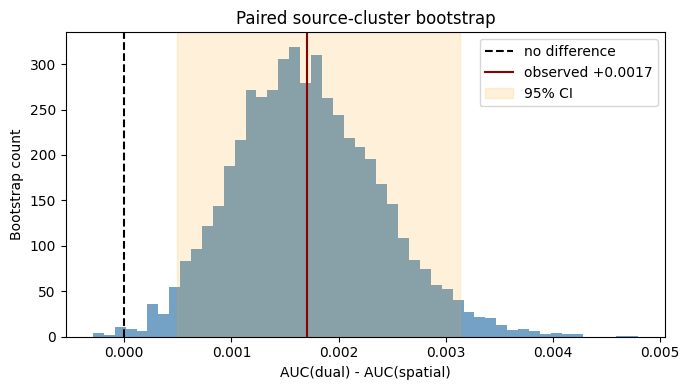

Saved bootstrap cluster results and figure


In [8]:
# EXPERIMENT 1 - Paired source-cluster bootstrap confidence intervals
# Resamples the 75 FF++ test source-pair components and keeps the
# spatial and dual predictions paired inside every resampled component.

BOOTSTRAP_SEED = 42
N_BOOTSTRAP = 5000

spatial_bootstrap_df = pd.read_csv(f"{PRED_DIR}/spatial_test_final.csv")
dual_bootstrap_df = pd.read_csv(f"{PRED_DIR}/dual_test_final.csv")

bootstrap_result, bootstrap_draws = paired_cluster_bootstrap(
    first_df=spatial_bootstrap_df,
    second_df=dual_bootstrap_df,
    first_name="spatial",
    second_name="dual",
    n_bootstrap=N_BOOTSTRAP,
    seed=BOOTSTRAP_SEED,
)

print("PAIRED SOURCE-CLUSTER BOOTSTRAP")
print(f"  Components       : {bootstrap_result['n_components']}")
print(f"  Videos           : {bootstrap_result['n_videos']}")
print(f"  Valid resamples  : {bootstrap_result['n_bootstrap_valid']}")
print(f"  Spatial AUC      : {bootstrap_result['first_auc']:.4f} "
      f"CI [{bootstrap_result['first_auc_ci95'][0]:.4f}, "
      f"{bootstrap_result['first_auc_ci95'][1]:.4f}]")
print(f"  Dual AUC         : {bootstrap_result['second_auc']:.4f} "
      f"CI [{bootstrap_result['second_auc_ci95'][0]:.4f}, "
      f"{bootstrap_result['second_auc_ci95'][1]:.4f}]")
print(f"  Difference       : "
      f"{bootstrap_result['auc_difference_second_minus_first']:+.4f} "
      f"CI [{bootstrap_result['auc_difference_ci95'][0]:+.4f}, "
      f"{bootstrap_result['auc_difference_ci95'][1]:+.4f}]")
print(f"  Bootstrap share with dual higher: "
      f"{bootstrap_result['fraction_resamples_second_higher']:.3f}")
print("  This share is descriptive, not a formal p-value.")
print(f"  Interpretation: {bootstrap_result['interpretation']}")

experiment_save_json(
    bootstrap_result,
    f"{ADDITIONAL_EXP_DIR}/bootstrap_cluster_results.json",
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    bootstrap_draws["auc_difference"],
    bins=50,
    color="steelblue",
    alpha=0.75,
)
ax.axvline(0, color="black", linestyle="--", label="no difference")
ax.axvline(
    bootstrap_result["auc_difference_second_minus_first"],
    color="darkred",
    label=(
        "observed "
        f"{bootstrap_result['auc_difference_second_minus_first']:+.4f}"
    ),
)
ax.axvspan(
    bootstrap_result["auc_difference_ci95"][0],
    bootstrap_result["auc_difference_ci95"][1],
    color="orange",
    alpha=0.15,
    label="95% CI",
)
ax.set_xlabel("AUC(dual) - AUC(spatial)")
ax.set_ylabel("Bootstrap count")
ax.set_title("Paired source-cluster bootstrap")
ax.legend()
plt.tight_layout()
plt.savefig(
    f"{ADDITIONAL_EXP_DIR}/bootstrap_auc_difference.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("Saved bootstrap cluster results and figure")

## 6.2 Video-level calibration

A single temperature is fitted using validation labels only. It is applied to
frame logits before the deployed mean-probability aggregation, so video ordering
can change and raw and calibrated AUCs are both reported. NLL, Brier score, a
10-bin ECE estimate and reliability plots are evaluated on the untouched FF++
test set. ECE depends on the chosen binning and is interpreted alongside the
proper scoring rules rather than in isolation.

VIDEO-LEVEL TEMPERATURE CALIBRATION
  Selected temperature : 1.3322
  Validation videos     : 719
  Test videos           : 738

FF++ TEST CALIBRATION
  Metric            Raw   Calibrated
  AUC            0.9901       0.9901
  NLL            0.1195       0.1206
  BRIER          0.0316       0.0321
  ECE            0.0290       0.0312


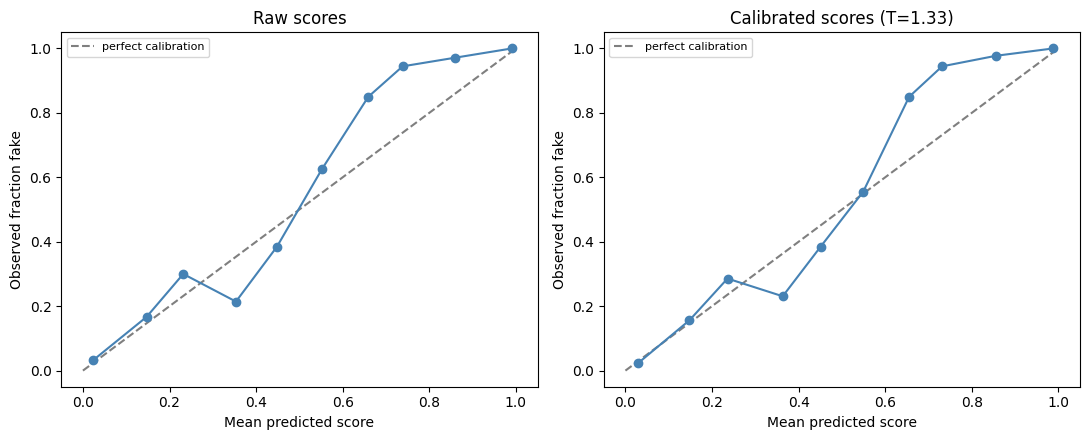

Saved calibration results, predictions and reliability figure


In [9]:
# Fits temperature on validation-video labels only, using the deployed
# aggregation: mean(sigmoid(frame_logit / T))
# Test labels are used only for the final calibration evaluation.

CALIBRATION_BINS = 10

with open(f"{EXP_DIR}/step4_final_decision_video_auc_v2.json") as f:
    calibration_decision = json.load(f)

validation_frame_tag = (
    "step4_video_auc_v2_tuned_dual_val_final_frames"
    if calibration_decision["decision"] == "promote_tuned"
    else "step4_video_auc_v2_current_dual_val_final_frames"
)

validation_frame_path = f"{PRED_DIR}/{validation_frame_tag}.csv"
test_frame_path = f"{PRED_DIR}/dual_test_final_frames.csv"

for path in [validation_frame_path, test_frame_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Required frame prediction file missing: {path}")

validation_frames = pd.read_csv(validation_frame_path)
test_frames = pd.read_csv(test_frame_path)

required_frame_columns = {"video_id", "true_label", "frame_logit"}
for name, dataframe in {"validation": validation_frames,"test": test_frames,}.items():
    missing = required_frame_columns - set(dataframe.columns)
    if missing:
        raise ValueError(f"{name} frame predictions are missing {sorted(missing)}")

    label_counts = dataframe.groupby("video_id")["true_label"].nunique()
    if (label_counts != 1).any():
        raise RuntimeError(f"{name} contains inconsistent labels within a video.")

def calibration_video_table(frames, temperature):
    working = frames[["video_id", "true_label", "frame_logit"]].copy()
    working["video_score"] = expit(working["frame_logit"].to_numpy(dtype=float) / float(temperature))

    return (
        working.groupby("video_id", sort=True)
        .agg(true_label=("true_label", "first"),
             video_score=("video_score", "mean"),
             n_frames=("video_score", "size"))
        .reset_index()
    )

def calibration_ece(labels, scores, n_bins=10):
    labels = np.asarray(labels, dtype=int)
    scores = np.asarray(scores, dtype=float)
    edges = np.linspace(0, 1, n_bins + 1)
    assignments = np.clip(np.digitize(scores, edges) - 1, 0, n_bins - 1)

    ece_value = 0.0
    points = []
    for bin_index in range(n_bins):
        mask = assignments == bin_index
        count = int(mask.sum())
        if count == 0:
            continue

        mean_score = float(scores[mask].mean())
        observed_rate = float(labels[mask].mean())
        ece_value += (count / len(labels)) * abs(observed_rate - mean_score)

        points.append({
            "bin": int(bin_index),
            "count": count,
            "mean_score": mean_score,
            "observed_fake_rate": observed_rate,
        })
    return float(ece_value), points

def calibration_metrics(table, n_bins=10):
    labels = table["true_label"].to_numpy(dtype=int)
    scores = table["video_score"].to_numpy(dtype=float)
    ece_value, points = calibration_ece(labels, scores, n_bins=n_bins)

    return {
        "auc": float(roc_auc_score(labels, scores)),
        "nll": video_log_loss(labels, scores),
        "brier": float(np.mean((scores - labels) ** 2)),
        "ece": ece_value,
        "n_videos": int(len(table)),
        "reliability_points": points,
    }

def validation_nll(log_temperature):
    temperature = float(np.exp(log_temperature))
    table = calibration_video_table(validation_frames, temperature)
    return video_log_loss(table["true_label"], table["video_score"])

temperature_fit = minimize_scalar(
    validation_nll,
    bounds=(np.log(0.05), np.log(10.0)),
    method="bounded",
    options={"xatol": 1e-6},
)

if not temperature_fit.success:
    raise RuntimeError(f"Temperature fitting failed: {temperature_fit.message}")

best_temperature = float(np.exp(temperature_fit.x))

validation_raw = calibration_video_table(validation_frames, 1.0)
validation_calibrated = calibration_video_table(validation_frames,best_temperature,)
test_raw = calibration_video_table(test_frames, 1.0)
test_calibrated = calibration_video_table(test_frames, best_temperature)

if not np.array_equal(
    test_raw["video_id"].to_numpy(),
    test_calibrated["video_id"].to_numpy(),
):
    raise RuntimeError("Raw and calibrated test video IDs differ.")

validation_raw_metrics = calibration_metrics(validation_raw, CALIBRATION_BINS)
validation_cal_metrics = calibration_metrics(validation_calibrated, CALIBRATION_BINS)
test_raw_metrics = calibration_metrics(test_raw, CALIBRATION_BINS)
test_cal_metrics = calibration_metrics(test_calibrated, CALIBRATION_BINS)

calibrated_test_predictions = test_raw[["video_id", "true_label", "n_frames"]].copy()
calibrated_test_predictions["raw_video_score"] = test_raw["video_score"]
calibrated_test_predictions["calibrated_video_score"] = test_calibrated["video_score"]
calibrated_test_predictions["raw_pred_label"] = (calibrated_test_predictions["raw_video_score"] >= 0.5).astype(int)
calibrated_test_predictions["calibrated_pred_label"] = (calibrated_test_predictions["calibrated_video_score"] >= 0.5).astype(int)

_atomic_dataframe_save(
    calibrated_test_predictions,
    f"{ADDITIONAL_EXP_DIR}/calibrated_dual_test_predictions.csv",
)

print("VIDEO-LEVEL TEMPERATURE CALIBRATION")
print(f"  Selected temperature : {best_temperature:.4f}")
print(f"  Validation videos     : {len(validation_raw):,}")
print(f"  Test videos           : {len(test_raw):,}")
print("\nFF++ TEST CALIBRATION")
print(f"  {'Metric':<8} {'Raw':>12} {'Calibrated':>12}")
for metric in ["auc", "nll", "brier", "ece"]:
    print(f"  {metric.upper():<8} {test_raw_metrics[metric]:>12.4f} "
          f"{test_cal_metrics[metric]:>12.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, metrics, title in [
    (axes[0], test_raw_metrics, "Raw scores"),
    (axes[1], test_cal_metrics, f"Calibrated scores (T={best_temperature:.2f})"),
]:
    points = metrics["reliability_points"]
    x_values = [point["mean_score"] for point in points]
    y_values = [point["observed_fake_rate"] for point in points]

    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="perfect calibration")
    ax.plot(x_values, y_values, "o-", color="steelblue")
    ax.set_xlabel("Mean predicted score")
    ax.set_ylabel("Observed fraction fake")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    f"{ADDITIONAL_EXP_DIR}/calibration_reliability.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

calibration_result = {
    "temperature": best_temperature,
    "fit_split": "FF++ validation",
    "evaluation_split": "FF++ test",
    "aggregation": "mean sigmoid(frame_logit / temperature)",
    "n_bins_ece": CALIBRATION_BINS,
    "validation_raw": validation_raw_metrics,
    "validation_calibrated": validation_cal_metrics,
    "test_raw": test_raw_metrics,
    "test_calibrated": test_cal_metrics,
    "note": (
        "Video AUC is reported before and after calibration because applying "
        "temperature to frame logits before aggregation can change video ranking."
    ),
}

experiment_save_json(
    calibration_result,
    f"{ADDITIONAL_EXP_DIR}/calibration_results.json",
)

print("Saved calibration results, predictions and reliability figure")

## 6.3 Frame-count sensitivity

The locked dual model is evaluated with maximum crop counts of 10, 20 and 30.
This is a post-selection sensitivity analysis, not a new search over the test
set. It records actual mean crop usage because some videos contain fewer than
the requested cap. Pipeline time includes loading and preprocessing; controlled
forward latency is measured separately in Experiment 7.


dual test clean:   0%|          | 0/738 [00:00<?, ?it/s]

Saved 738 video rows to /kaggle/working/experiments/predictions/dual_test_10frames.csv
Saved 7364 frame rows to /kaggle/working/experiments/predictions/dual_test_10frames_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0

Dual test, maximum 10 frames coverage
  Expected  : 738
  Evaluated : 738
  Missing   : 0
  Coverage  : 100.00%
10 maximum frames | actual mean 10.0 | AUC 0.9892 | accuracy 0.9580 | pipeline 53 ms/video

Dual test, maximum 20 frames coverage
  Expected  : 738
  Evaluated : 738
  Missing   : 0
  Coverage  : 100.00%
20 maximum frames | actual mean 19.7 | AUC 0.9901 | accuracy 0.9634 | pipeline 106 ms/video


dual test clean:   0%|          | 0/738 [00:00<?, ?it/s]

Saved 738 video rows to /kaggle/working/experiments/predictions/dual_test_30frames.csv
Saved 21217 frame rows to /kaggle/working/experiments/predictions/dual_test_30frames_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0

Dual test, maximum 30 frames coverage
  Expected  : 738
  Evaluated : 738
  Missing   : 0
  Coverage  : 100.00%
30 maximum frames | actual mean 28.7 | AUC 0.9899 | accuracy 0.9593 | pipeline 160 ms/video


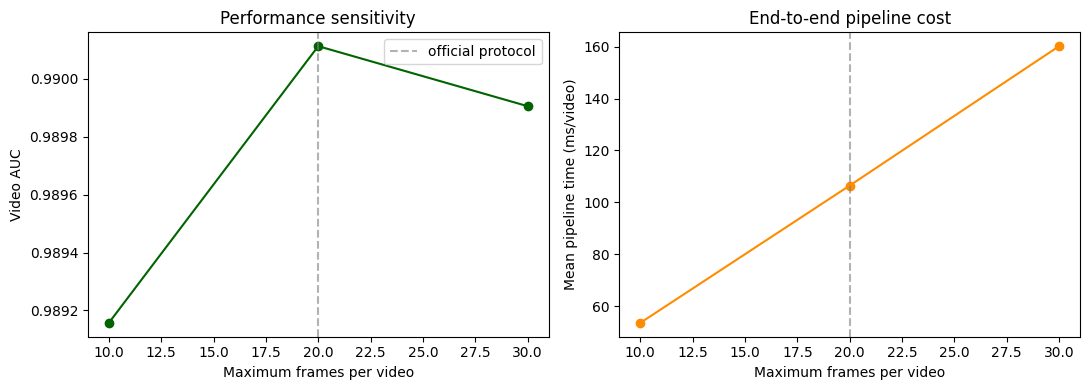


This experiment does not select a new frame count or change the final model.
Saved frame-count sensitivity results and figure


In [12]:
# EXPERIMENT 3 - Frame-count sensitivity analysis
# Evaluates the locked official dual model with maximum frame counts of 10, 20 and 30.
# This is a post-selection sensitivity analysis and does not change the official 20-frame deployment protocol.

FRAME_CONDITIONS = [10, 20, 30]
frame_sensitivity_results = {}

for maximum_frames in FRAME_CONDITIONS:
    if maximum_frames == 20:
        video_predictions = pd.read_csv(f"{PRED_DIR}/dual_test_final.csv")
    else:
        video_predictions, _ = generate_predictions(
            model=dual_model,
            manifest_path=MANIFEST_FF,
            split="test",
            processed_root=FF_PROCESSED,
            device=device,
            dual=True,
            model_name="dual",
            max_frames=maximum_frames,
            has_split=True,
            batch_size=20,
            condition="clean",
            output_tag=f"dual_test_{maximum_frames}frames",
        )

    coverage = validate_prediction_coverage(
        prediction_df=video_predictions,
        manifest_path=MANIFEST_FF,
        split="test",
        has_split=True,
        description=f"Dual test, maximum {maximum_frames} frames",
        require_complete=True,
    )

    metrics = metrics_from_predictions(video_predictions)
    actual_frames = video_predictions["n_frames"].astype(int)

    frame_sensitivity_results[str(maximum_frames)] = {
        "requested_maximum_frames": int(maximum_frames),
        "actual_mean_frames": float(actual_frames.mean()),
        "actual_median_frames": float(actual_frames.median()),
        "actual_minimum_frames": int(actual_frames.min()),
        "actual_maximum_frames": int(actual_frames.max()),
        "coverage": coverage,
        "metrics": metrics,
    }

    print(
        f"{maximum_frames:>2} maximum frames | "
        f"actual mean {actual_frames.mean():.1f} | "
        f"AUC {metrics['auc']:.4f} | "
        f"accuracy {metrics['acc']:.4f} | "
        f"pipeline {metrics['mean_scoring_pipeline_ms']:.0f} ms/video"
    )

experiment_save_json(
    {
        "experiment_type": "post-selection frame-count sensitivity analysis",
        "official_protocol_maximum_frames": 20,
        "model_selection_performed": False,
        "results": frame_sensitivity_results,
    },
    f"{ADDITIONAL_EXP_DIR}/frame_count_sensitivity.json",
)

frame_x = FRAME_CONDITIONS
frame_auc = [
    frame_sensitivity_results[str(value)]["metrics"]["auc"]
    for value in frame_x
]
frame_pipeline_time = [
    frame_sensitivity_results[str(value)]["metrics"]
    ["mean_scoring_pipeline_ms"]
    for value in frame_x
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(frame_x, frame_auc, "o-", color="darkgreen")
axes[0].axvline(20, linestyle="--", color="gray", alpha=0.6,label="official protocol")
axes[0].set_xlabel("Maximum frames per video")
axes[0].set_ylabel("Video AUC")
axes[0].set_title("Performance sensitivity")
axes[0].legend()

axes[1].plot(frame_x, frame_pipeline_time, "o-", color="darkorange")
axes[1].axvline(20, linestyle="--", color="gray", alpha=0.6)
axes[1].set_xlabel("Maximum frames per video")
axes[1].set_ylabel("Mean pipeline time (ms/video)")
axes[1].set_title("End-to-end pipeline cost")

plt.tight_layout()
plt.savefig( f"{ADDITIONAL_EXP_DIR}/frame_count_sensitivity.png", dpi=150,bbox_inches="tight",)
plt.show()

print("\nThis experiment does not select a new frame count or change the final model.")
print("Saved frame-count sensitivity results and figure")

## 6.4 Strict frequency-residual ablation

The official dual checkpoint is evaluated twice on exactly the same FF++ test
videos: normally and with $\alpha P(f)$ set to zero. No weights are retrained.
This isolates a component inside the trained architecture more directly than
comparing two independently trained networks. It remains mechanistic evidence,
not complete causal proof, because disabling the residual changes the input
distribution seen by the final classifier.

dual_frequency_disabled test frequency_residual_disabled:   0%|          | 0/738 [00:00<?, ?it/s]

Saved 738 video rows to /kaggle/working/experiments/predictions/dual_test_frequency_residual_disabled.csv
Saved 14544 frame rows to /kaggle/working/experiments/predictions/dual_test_frequency_residual_disabled_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0

Dual test with frequency residual disabled coverage
  Expected  : 738
  Evaluated : 738
  Missing   : 0
  Coverage  : 100.00%
STRICT FREQUENCY-RESIDUAL ABLATION
  Residual disabled AUC : 0.9663
  Official dual AUC     : 0.9901
  Difference            : +0.0238
  Cluster-bootstrap CI  : [+0.0119, +0.0365]
  Interpretation        : The 95% cluster-bootstrap interval favours official dual over frequency residual disabled.


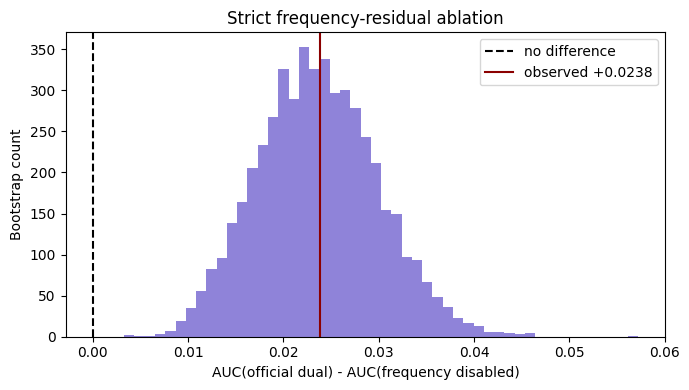

Saved strict frequency-residual ablation results and figure


In [11]:
# EXPERIMENT 4 - Strict frequency-residual ablation
# Uses the existing official dual checkpoint but removes alpha * P(f) from the
# fused representation. No weights are retrained or changed.

class DualFrequencyDisabled(nn.Module):
    def __init__(self, trained_dual_model):
        super().__init__()
        self.trained_dual_model = trained_dual_model

    def forward(self, normalized_images, raw_images):
        spatial_features = self.trained_dual_model.spatial.get_features(
            normalized_images
        )
        logits = self.trained_dual_model.classifier(
            spatial_features
        ).squeeze(1)
        disabled_alpha = torch.zeros(
            (normalized_images.size(0), 1),
            device=normalized_images.device,
            dtype=spatial_features.dtype,
        )
        return logits, disabled_alpha


dual_model.eval()
dual_frequency_disabled = DualFrequencyDisabled(dual_model).to(device)
dual_frequency_disabled.eval()

frequency_disabled_df, frequency_disabled_frames_df = generate_predictions(
    model=dual_frequency_disabled,
    manifest_path=MANIFEST_FF,
    split="test",
    processed_root=FF_PROCESSED,
    device=device,
    dual=True,
    model_name="dual_frequency_disabled",
    max_frames=TRAIN_FRAMES,
    has_split=True,
    batch_size=20,
    condition="frequency_residual_disabled",
    output_tag="dual_test_frequency_residual_disabled",
)

frequency_disabled_coverage = validate_prediction_coverage(
    prediction_df=frequency_disabled_df,
    manifest_path=MANIFEST_FF,
    split="test",
    has_split=True,
    description="Dual test with frequency residual disabled",
    require_complete=True,
)

official_dual_df = pd.read_csv(f"{PRED_DIR}/dual_test_final.csv")

if set(official_dual_df["video_id"].astype(str)) != set(
    frequency_disabled_df["video_id"].astype(str)
):
    raise RuntimeError("Official and ablated models evaluated different videos.")

official_dual_metrics = metrics_from_predictions(official_dual_df)
frequency_disabled_metrics = metrics_from_predictions(frequency_disabled_df)

frequency_ablation_bootstrap, frequency_ablation_draws = paired_cluster_bootstrap(
    first_df=frequency_disabled_df,
    second_df=official_dual_df,
    first_name="frequency residual disabled",
    second_name="official dual",
    n_bootstrap=5000,
    seed=84,
)

print("STRICT FREQUENCY-RESIDUAL ABLATION")
print(f"  Residual disabled AUC : {frequency_disabled_metrics['auc']:.4f}")
print(f"  Official dual AUC     : {official_dual_metrics['auc']:.4f}")
print(f"  Difference            : "
      f"{official_dual_metrics['auc'] - frequency_disabled_metrics['auc']:+.4f}")
print(f"  Cluster-bootstrap CI  : "
      f"[{frequency_ablation_bootstrap['auc_difference_ci95'][0]:+.4f}, "
      f"{frequency_ablation_bootstrap['auc_difference_ci95'][1]:+.4f}]")
print(f"  Interpretation        : "
      f"{frequency_ablation_bootstrap['interpretation']}")

frequency_ablation_result = {
    "ablation": "alpha * projected frequency residual set to zero",
    "retraining": False,
    "maximum_frames_per_video": int(TRAIN_FRAMES),
    "coverage": frequency_disabled_coverage,
    "frequency_disabled_metrics": frequency_disabled_metrics,
    "official_dual_metrics": official_dual_metrics,
    "auc_difference_official_minus_disabled": float(
        official_dual_metrics["auc"] - frequency_disabled_metrics["auc"]
    ),
    "paired_cluster_bootstrap": frequency_ablation_bootstrap,
}

experiment_save_json(
    frequency_ablation_result,
    f"{ADDITIONAL_EXP_DIR}/frequency_residual_ablation.json",
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    frequency_ablation_draws["auc_difference"],
    bins=50,
    color="slateblue",
    alpha=0.75,
)
ax.axvline(0, color="black", linestyle="--", label="no difference")
ax.axvline(
    frequency_ablation_result["auc_difference_official_minus_disabled"],
    color="darkred",
    label=(
        "observed "
        f"{frequency_ablation_result['auc_difference_official_minus_disabled']:+.4f}"
    ),
)
ax.set_xlabel("AUC(official dual) - AUC(frequency disabled)")
ax.set_ylabel("Bootstrap count")
ax.set_title("Strict frequency-residual ablation")
ax.legend()
plt.tight_layout()
plt.savefig(
    f"{ADDITIONAL_EXP_DIR}/frequency_residual_ablation.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("Saved strict frequency-residual ablation results and figure")

### 6.4.1 Per-video counterfactual and exploratory manipulation analysis

The saved normal and residual-disabled scores are joined by `video_id`. Their
difference answers a local counterfactual question: how did this trained
model's fake score change when its frequency residual was removed? Positive
values mean that the residual raised the fake score; they do not automatically
mean that it improved correctness.

The additional manipulation-family table compares each fake family with the
same real control videos. It is explicitly exploratory: the rows share controls
and no multiplicity-adjusted hypothesis tests are performed.

In [12]:
# EXPERIMENT 4A- Per-video FF++ frequency counterfactual table
# Uses predictions already produced by CELL 17 and Experiment 4.
# Videos are matched by video_id and checked against the test manifest.

normal_path = f"{PRED_DIR}/dual_test_final.csv"
disabled_path = f"{PRED_DIR}/dual_test_frequency_residual_disabled.csv"

for required_path in [normal_path, disabled_path, MANIFEST_FF]:
    if not os.path.exists(required_path):
        raise FileNotFoundError(f"Required file missing: {required_path}")

normal_dual_df = pd.read_csv(normal_path)
disabled_dual_df = pd.read_csv(disabled_path)

required_prediction_columns = {"video_id", "true_label", "video_score", "pred_label",}

for name, dataframe in [("official dual", normal_dual_df),("frequency disabled", disabled_dual_df),]:
    missing = required_prediction_columns - set(dataframe.columns)
    if missing:
        raise ValueError(f"{name} predictions are missing: {sorted(missing)}")

    dataframe["video_id"] = dataframe["video_id"].astype(str)

    if dataframe["video_id"].duplicated().any():
        raise RuntimeError(f"Duplicate video_id found in {name} predictions.")

    if not dataframe["video_score"].between(0, 1).all():
        raise RuntimeError(f"Scores outside [0,1] found in {name} predictions.")

    score_labels = (dataframe["video_score"] >= 0.5).astype(int)
    if not np.array_equal(score_labels.to_numpy(), dataframe["pred_label"].astype(int).to_numpy()):
        raise RuntimeError(f"Stored labels do not match scores in {name} predictions.")

ff_manifest = pd.read_csv(MANIFEST_FF)
ff_test_manifest = ff_manifest[ff_manifest["split"] == "test"].copy()
ff_test_manifest["video_id"] = ff_test_manifest["video_id"].astype(str)

if ff_test_manifest["video_id"].duplicated().any():
    raise RuntimeError("The FF++ test manifest contains duplicate video IDs.")

expected_test_ids = set(ff_test_manifest["video_id"])
normal_ids = set(normal_dual_df["video_id"])
disabled_ids = set(disabled_dual_df["video_id"])

if normal_ids != expected_test_ids:
    raise RuntimeError(
        f"Official dual predictions do not match the FF++ test manifest: "
        f"missing={len(expected_test_ids-normal_ids)}, "
        f"unexpected={len(normal_ids-expected_test_ids)}."
    )

if disabled_ids != expected_test_ids:
    raise RuntimeError(
        f"Frequency-disabled predictions do not match the FF++ test manifest: "
        f"missing={len(expected_test_ids-disabled_ids)}, "
        f"unexpected={len(disabled_ids-expected_test_ids)}."
    )

manifest_labels = ff_test_manifest.set_index("video_id")["label"].astype(int)
normal_labels = normal_dual_df.set_index("video_id")["true_label"].astype(int)
disabled_labels = disabled_dual_df.set_index("video_id")["true_label"].astype(int)

if not normal_labels.sort_index().equals(manifest_labels.sort_index()):
    raise RuntimeError("Official dual labels do not match the FF++ test manifest.")

if not disabled_labels.sort_index().equals(manifest_labels.sort_index()):
    raise RuntimeError("Frequency-disabled labels do not match the FF++ test manifest.")

EXPECTED_TEST_VIDEOS = len(expected_test_ids)

disabled_subset = disabled_dual_df[[
    "video_id", "true_label", "video_score", "pred_label",
]].rename(columns={
    "true_label": "true_label_check",
    "video_score": "video_score_frequency_disabled",
    "pred_label": "pred_label_frequency_disabled",
})

counterfactual_df = normal_dual_df.merge(disabled_subset, on="video_id", how="inner", validate="one_to_one",)

if len(counterfactual_df) != EXPECTED_TEST_VIDEOS:
    raise RuntimeError(f"Expected {EXPECTED_TEST_VIDEOS} matched videos,got {len(counterfactual_df)}.")

if not (counterfactual_df["true_label"].astype(int) == counterfactual_df["true_label_check"].astype(int)).all():
    raise RuntimeError("True labels differ between normal and frequency-disabled predictions.")

counterfactual_df = counterfactual_df.drop(columns=["true_label_check"])

# Positive: the frequency residual increased the fake score.
# Negative: it decreased the fake score. This describes a score change,
# not whether the frequency residual was correct.
counterfactual_df["frequency_score_effect"] = (counterfactual_df["video_score"] - counterfactual_df["video_score_frequency_disabled"])
counterfactual_df["abs_frequency_score_effect"] = (counterfactual_df["frequency_score_effect"].abs())
counterfactual_df["frequency_effect_direction"] = np.select(
    [
        counterfactual_df["frequency_score_effect"] > 0,
        counterfactual_df["frequency_score_effect"] < 0,
    ],
    ["increased_fake_score", "decreased_fake_score"],
    default="no_change",
)

counterfactual_df["dual_correct"] = (counterfactual_df["pred_label"].astype(int) == counterfactual_df["true_label"].astype(int))
counterfactual_df["frequency_disabled_correct"] = (counterfactual_df["pred_label_frequency_disabled"].astype(int) == counterfactual_df["true_label"].astype(int))
counterfactual_df["prediction_flip"] = np.select(
    [
        counterfactual_df["dual_correct"]
        & ~counterfactual_df["frequency_disabled_correct"],
        ~counterfactual_df["dual_correct"]
        & counterfactual_df["frequency_disabled_correct"],
    ],
    ["frequency_fixed_prediction", "frequency_broke_prediction"],
    default="no_flip",
)

counterfactual_path = (f"{ADDITIONAL_EXP_DIR}/ff_test_frequency_counterfactual.csv")
_atomic_dataframe_save(counterfactual_df, counterfactual_path)

flip_counts = counterfactual_df["prediction_flip"].value_counts().to_dict()

print("FF++ TEST FREQUENCY COUNTERFACTUAL")
print(f"  Manifest videos            : {EXPECTED_TEST_VIDEOS}")
print(f"  Videos matched             : {len(counterfactual_df)}")
print(
    f"  Mean effect (dual-disabled): "
    f"{counterfactual_df['frequency_score_effect'].mean():+.4f}"
)
print(
    f"  Mean absolute effect       : "
    f"{counterfactual_df['abs_frequency_score_effect'].mean():.4f}"
)
print(
    f"  Increased fake score       : "
    f"{(counterfactual_df['frequency_effect_direction']=='increased_fake_score').sum()}"
)
print(
    f"  Decreased fake score       : "
    f"{(counterfactual_df['frequency_effect_direction']=='decreased_fake_score').sum()}"
)
print("\n  Prediction flips:")
for key, value in flip_counts.items():
    print(f"    {key:<28}: {value}")

experiment_save_json(
    {
        "n_manifest_videos": int(EXPECTED_TEST_VIDEOS),
        "n_matched_videos": int(len(counterfactual_df)),
        "mean_effect": float(counterfactual_df["frequency_score_effect"].mean()),
        "mean_absolute_effect": float(
            counterfactual_df["abs_frequency_score_effect"].mean()
        ),
        "flip_counts": {str(key): int(value) for key, value in flip_counts.items()},
        "note": (
            "A positive frequency_score_effect means the frequency residual "
            "increased the fake score. It does not establish correctness."
        ),
    },
    f"{ADDITIONAL_EXP_DIR}/frequency_counterfactual_summary.json",
)

print(f"\nSaved counterfactual table to {counterfactual_path}")

FF++ TEST FREQUENCY COUNTERFACTUAL
  Manifest videos            : 738
  Videos matched             : 738
  Mean effect (dual-disabled): +0.7546
  Mean absolute effect       : 0.7546
  Increased fake score       : 738
  Decreased fake score       : 0

  Prediction flips:
    frequency_fixed_prediction  : 571
    no_flip                     : 159
    frequency_broke_prediction  : 8

Saved counterfactual table to /kaggle/working/experiments/additional_experiments/ff_test_frequency_counterfactual.csv


In [13]:
disabled_scores = counterfactual_df["video_score_frequency_disabled"]
print(f"Frequency-disabled score distribution:")
print(f"  mean   : {disabled_scores.mean():.4f}")
print(f"  std    : {disabled_scores.std():.4f}")
print(f"  min/max: {disabled_scores.min():.4f} / {disabled_scores.max():.4f}")
print(f"  by true label:")
print(disabled_scores.groupby(counterfactual_df["true_label"]).describe())

Frequency-disabled score distribution:
  mean   : 0.0247
  std    : 0.0348
  min/max: 0.0001 / 0.9029
  by true label:
            count      mean       std       min       25%       50%       75%  \
true_label                                                                      
0           147.0  0.006855  0.005883  0.000126  0.002353  0.005201  0.009851   
1           591.0  0.029127  0.037464  0.000169  0.020510  0.026246  0.033707   

                 max  
true_label            
0           0.028213  
1           0.902877  


EXPLORATORY FREQUENCY EFFECT BY MANIPULATION
Each manipulation is compared with the same real-video control group.
  manipulation  official_dual_auc  frequency_disabled_auc  auc_difference  mean_fake_score_effect  mean_fake_gate_alpha
     Deepfakes           0.997012                0.980879        0.016133                0.937947              0.952766
     Face2Face           0.996599                0.969434        0.027165                0.935804              0.954059
      FaceSwap           0.998936                0.950761        0.048174                0.947937              0.960828
NeuralTextures           0.967963                0.964102        0.003861                0.819657              0.833191


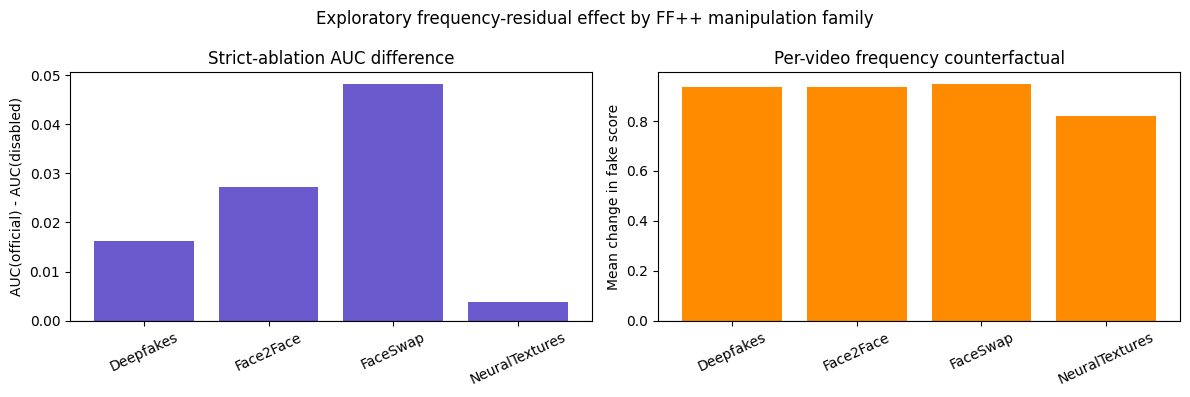


This analysis is descriptive. It does not establish that the
frequency residual detects a particular artefact or facial region.
Saved results to /kaggle/working/experiments/additional_experiments/frequency_effect_by_manipulation.csv


In [13]:
# EXPLORATORY ANALYSIS - Frequency-residual effect by manipulation family
#
# This is a descriptive follow-up to the strict ablation.
# Each manipulation family is compared with the same set of real FF++ test videos.
# The repeated real control group and the absence of multiplicity-adjusted hypothesis tests
# mean that these rows should not be interpreted as independent confirmatory tests.

required_columns = {
    "video_id",
    "true_label",
    "category",
    "video_score",
    "video_score_frequency_disabled",
    "frequency_score_effect",
    "prediction_flip",
}

missing_columns = required_columns - set(counterfactual_df.columns)

if missing_columns:
    raise ValueError(
        "Counterfactual table is missing columns: "
        f"{sorted(missing_columns)}"
    )

interaction_source = counterfactual_df.copy()
interaction_source["video_id"] = interaction_source["video_id"].astype(str)

if interaction_source["video_id"].duplicated().any():
    raise RuntimeError("Counterfactual table contains duplicate video IDs.")

if interaction_source["category"].isna().any():
    raise RuntimeError("Counterfactual table contains missing manipulation labels.")

# Recover mean gate alpha only if it is not already present in the
# Use the video-level mean gate alpha already saved by generate_predictions().
# The frame CSV is retained as a fallback for older prediction files.

if "mean_gate_alpha" in interaction_source.columns:
    interaction_source["mean_gate_alpha"] = pd.to_numeric(interaction_source["mean_gate_alpha"],errors="coerce",)
else:
    alpha_path = f"{PRED_DIR}/dual_test_final_frames.csv"

    if not os.path.exists(alpha_path):
        raise FileNotFoundError(f"Dual frame predictions missing: {alpha_path}")

    alpha_frames = pd.read_csv(alpha_path)
    alpha_required = {"video_id", "gate_alpha"}
    alpha_missing = alpha_required - set(alpha_frames.columns)

    if alpha_missing:
        raise ValueError(
            "Dual frame predictions are missing: "
            f"{sorted(alpha_missing)}"
        )

    alpha_frames["video_id"] = alpha_frames["video_id"].astype(str)

    alpha_by_video = (alpha_frames.groupby("video_id", as_index=False)["gate_alpha"].mean().rename(columns={"gate_alpha": "mean_gate_alpha"}))

    interaction_source = interaction_source.merge(alpha_by_video,on="video_id",how="left",validate="one_to_one",)

if interaction_source["mean_gate_alpha"].isna().any():
    missing_alpha = int(interaction_source["mean_gate_alpha"].isna().sum())
    raise RuntimeError(
        f"Gate alpha could not be recovered for "
        f"{missing_alpha} test videos."
    )

real_rows = interaction_source[interaction_source["category"] == "original"].copy()

if real_rows.empty:
    raise RuntimeError("No real FF++ test videos were found.")

interaction_rows = []

for category in FF_FAKE_FOLDERS:
    fake_rows = interaction_source[interaction_source["category"] == category].copy()

    if fake_rows.empty:
        raise RuntimeError(f"No FF++ test videos were found for {category}.")

    comparison = pd.concat([real_rows, fake_rows],ignore_index=True,)
    labels = comparison["true_label"].astype(int).to_numpy()
    official_scores = comparison["video_score"].astype(float).to_numpy()
    disabled_scores = comparison["video_score_frequency_disabled"].astype(float).to_numpy()

    official_auc = float(roc_auc_score(labels, official_scores))
    disabled_auc = float(roc_auc_score(labels, disabled_scores))

    interaction_rows.append({
        "manipulation": category,
        "n_real": int(len(real_rows)),
        "n_fake": int(len(fake_rows)),
        "official_dual_auc": official_auc,
        "frequency_disabled_auc": disabled_auc,
        "auc_difference": official_auc - disabled_auc,
        "mean_fake_score_effect": float(
            fake_rows["frequency_score_effect"].mean()
        ),
        "median_fake_score_effect": float(
            fake_rows["frequency_score_effect"].median()
        ),
        "mean_fake_gate_alpha": float(
            fake_rows["mean_gate_alpha"].mean()
        ),
        "frequency_fixed_fake_predictions": int(
            (fake_rows["prediction_flip"] == "frequency_fixed_prediction").sum()
        ),
        "frequency_broke_fake_predictions": int(
            (fake_rows["prediction_flip"] == "frequency_broke_prediction").sum()
        ),
    })

frequency_interaction_df = pd.DataFrame(interaction_rows)

interaction_path = (
    f"{ADDITIONAL_EXP_DIR}/frequency_effect_by_manipulation.csv"
)
_atomic_dataframe_save(frequency_interaction_df, interaction_path)

interaction_record = {
    "analysis_type": "exploratory manipulation-family comparison",
    "shared_real_control_videos": int(len(real_rows)),
    "confirmatory_test": False,
    "multiplicity_adjustment": False,
    "rows": frequency_interaction_df.to_dict("records"),
    "interpretation_note": (
        "The table describes how the trained model changes when its frequency "
        "residual is disabled. Manipulation rows share the same real control "
        "videos and are not independent confirmatory tests."
    ),
}

experiment_save_json(
    interaction_record,
    f"{ADDITIONAL_EXP_DIR}/frequency_effect_by_manipulation.json",
)

print("EXPLORATORY FREQUENCY EFFECT BY MANIPULATION")
print("Each manipulation is compared with the same real-video control group.")
print(frequency_interaction_df[["manipulation", "official_dual_auc", "frequency_disabled_auc", "auc_difference", "mean_fake_score_effect", "mean_fake_gate_alpha",]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(frequency_interaction_df["manipulation"], frequency_interaction_df["auc_difference"], color="slateblue",)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("AUC(official) - AUC(disabled)")
axes[0].set_title("Strict-ablation AUC difference")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(frequency_interaction_df["manipulation"],frequency_interaction_df["mean_fake_score_effect"],color="darkorange",)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Mean change in fake score")
axes[1].set_title("Per-video frequency counterfactual")
axes[1].tick_params(axis="x", rotation=25)

plt.suptitle("Exploratory frequency-residual effect by FF++ manipulation family")
plt.tight_layout()
plt.savefig(f"{ADDITIONAL_EXP_DIR}/frequency_effect_by_manipulation.png",dpi=150,bbox_inches="tight",)
plt.show()

print("\nThis analysis is descriptive. It does not establish that the")
print("frequency residual detects a particular artefact or facial region.")
print(f"Saved results to {interaction_path}")

## 6.5 Frequency-only baseline

This is a separately trained baseline, not an ablation. Its learning rate,
dropout, weight decay, seed and eight-epoch budget are fixed to match the
retained dual-model training configuration rather than tuned again. Validation
video AUC selects the checkpoint, with video log loss used inside the same AUC
tolerance rule. The result tests whether Fourier evidence is useful by itself.

In [10]:
# EXPERIMENT 5 - Frequency-only baseline
# Trains a new frequency-only model.
# Its training settings are fixed to match the retained dual model; they are not separately tuned for this baseline.

FREQ_VERSION = "frequency_only_v1"
FREQ_SEED = 42
FREQ_LR = 5e-4
FREQ_DROPOUT = 0.4
FREQ_WEIGHT_DECAY = 1e-4
FREQ_EPOCHS = 8
FREQ_ETA_MIN = 1e-6
FREQ_TIE_TOLERANCE = 0.001

FREQ_DIR = f"{ADDITIONAL_EXP_DIR}/{FREQ_VERSION}"
FREQ_EPOCH_DIR = f"{FREQ_DIR}/epoch_checkpoints"
FREQ_PROGRESS_PATH = f"{FREQ_DIR}/training_progress.pth"
FREQ_HISTORY_PATH = f"{FREQ_DIR}/frequency_only_history.json"
FREQ_DECISION_PATH = f"{FREQ_DIR}/frequency_only_decision.json"
FREQ_CKPT_PATH = f"{CKPT_DIR}/frequency_only_best.pth"
FREQ_TEST_RESULT_PATH = f"{FREQ_DIR}/frequency_only_test_results.json"

os.makedirs(FREQ_EPOCH_DIR, exist_ok=True)

if torch.device(device).type != "cuda":
    raise RuntimeError(
        "Frequency-only training requires a GPU. Run Resume A, Cells 10-13, "
        "Step 2, Resume B, Experiment Setup and this cell.")

for required_name in ["train_loader", "val_loader"]:
    if required_name not in globals():
        raise RuntimeError(f"{required_name} is missing. Run Cell 11 first.")

class FrequencyOnlyModel(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()
        self.freq = FrequencyBranchV2()
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, raw_images):
        features = self.freq(raw_images)
        return self.classifier(features).squeeze(1)

class FrequencyPredictionAdapter(nn.Module):
    """Adapts the frequency-only model to the shared prediction function."""
    def __init__(self, frequency_model):
        super().__init__()
        self.frequency_model = frequency_model

    def forward(self, normalized_images, raw_images):
        logits = self.frequency_model(raw_images)
        unavailable_alpha = torch.full(
            (raw_images.size(0), 1),
            float("nan"),
            device=raw_images.device,
            dtype=logits.dtype,
        )
        return logits, unavailable_alpha

def set_frequency_seed():
    random.seed(FREQ_SEED)
    np.random.seed(FREQ_SEED)
    torch.manual_seed(FREQ_SEED)
    torch.cuda.manual_seed_all(FREQ_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def capture_frequency_rng():
    return {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch": torch.get_rng_state(),
        "cuda": torch.cuda.get_rng_state_all(),
    }

def restore_frequency_rng(state):
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch"].cpu())
    torch.cuda.set_rng_state_all([
        cuda_state.cpu()
        for cuda_state in state["cuda"]
    ])

def train_frequency_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for _, raw_images, labels in loader:
        raw_images = raw_images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(raw_images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * raw_images.size(0)
        predictions = (torch.sigmoid(logits) >= 0.5).float()
        correct += (predictions == labels).sum().item()
        total += raw_images.size(0)

    return total_loss / total, correct / total


def evaluate_frequency_frames(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    labels_all = []
    scores_all = []

    with torch.inference_mode():
        for _, raw_images, labels in loader:
            raw_images = raw_images.to(device)
            labels = labels.to(device)

            logits = model(raw_images)
            loss = criterion(logits, labels)
            scores = torch.sigmoid(logits)

            total_loss += loss.item() * raw_images.size(0)
            correct += ((scores >= 0.5).float() == labels).sum().item()
            total += raw_images.size(0)
            labels_all.extend(labels.detach().cpu().numpy().tolist())
            scores_all.extend(scores.detach().cpu().numpy().tolist())

    return {
        "loss": float(total_loss / total),
        "accuracy": float(correct / total),
        "auc": float(roc_auc_score(labels_all, scores_all)),
    }


frequency_config = {
    "version": FREQ_VERSION,
    "seed": FREQ_SEED,
    "learning_rate": FREQ_LR,
    "dropout": FREQ_DROPOUT,
    "weight_decay": FREQ_WEIGHT_DECAY,
    "epochs": FREQ_EPOCHS,
    "eta_min": FREQ_ETA_MIN,
    "tie_tolerance": FREQ_TIE_TOLERANCE,
    "maximum_frames_per_video": int(TRAIN_FRAMES),
    "batch_size": int(BS),
    "selection_metric": "validation video AUC",
    "tie_break": "validation video log loss",
    "settings_basis": "fixed to retained dual-model training configuration",
    "manifest_sha256": experiment_file_sha256(MANIFEST_FF),
}

frequency_signature = hashlib.sha256(json.dumps(frequency_config, sort_keys=True).encode("utf-8")).hexdigest()

def select_frequency_epoch(history):
    maximum_auc = max(row["video_val_auc"] for row in history)
    close_rows = [row for row in history if row["video_val_auc"] >= maximum_auc - FREQ_TIE_TOLERANCE]
    return min(close_rows, key=lambda row: (row["video_val_log_loss"], row["epoch"]))


if os.path.exists(FREQ_DECISION_PATH):
    with open(FREQ_DECISION_PATH) as f:
        frequency_decision = json.load(f)

    if frequency_decision.get("signature") != frequency_signature:
        raise RuntimeError("Existing frequency-only result uses a different configuration.")

    if not os.path.exists(FREQ_CKPT_PATH):
        raise FileNotFoundError("Frequency-only decision exists but frequency_only_best.pth is missing.")

    print("Frequency-only training was already completed.")
    print(f"  Selected epoch : {frequency_decision['selected_epoch']}")
    print(f"  Validation AUC : {frequency_decision['selected_video_val_auc']:.4f}")

else:
    set_frequency_seed()
    freq_model = FrequencyOnlyModel(dropout=FREQ_DROPOUT).to(device)
    freq_optimizer = optim.AdamW(
        freq_model.parameters(),
        lr=FREQ_LR,
        weight_decay=FREQ_WEIGHT_DECAY,
    )
    freq_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        freq_optimizer,
        T_max=FREQ_EPOCHS,
        eta_min=FREQ_ETA_MIN,
    )
    freq_criterion = nn.BCEWithLogitsLoss()
    frequency_history = []
    start_epoch = 1

    if os.path.exists(FREQ_PROGRESS_PATH):
        progress = torch.load(
            FREQ_PROGRESS_PATH,
            map_location=device,
            weights_only=False,
        )

        if progress.get("signature") != frequency_signature:
            raise RuntimeError("Existing frequency-only progress uses a different configuration.")

        freq_model.load_state_dict(progress["model_state"])
        freq_optimizer.load_state_dict(progress["optimizer_state"])
        freq_scheduler.load_state_dict(progress["scheduler_state"])
        frequency_history = progress["history"]
        start_epoch = int(progress["completed_epoch"]) + 1
        restore_frequency_rng(progress["rng_state"])

        print(f"Resuming frequency-only training after epoch {start_epoch - 1}.")

    print("FREQUENCY-ONLY BASELINE")
    print(f"  Learning rate : {FREQ_LR:.0e}")
    print(f"  Dropout       : {FREQ_DROPOUT}")
    print(f"  Epochs        : {FREQ_EPOCHS}")
    print("  Settings are fixed to match the retained dual-model run.\n")

    for epoch in range(start_epoch, FREQ_EPOCHS + 1):
        epoch_start = time.time()

        train_loss, train_accuracy = train_frequency_epoch(freq_model,train_loader,freq_optimizer,freq_criterion,)
        frame_validation = evaluate_frequency_frames(freq_model,val_loader,freq_criterion,)

        freq_scheduler.step()

        validation_adapter = FrequencyPredictionAdapter(freq_model).to(device)
        validation_video_df, _ = generate_predictions(
            model=validation_adapter,
            manifest_path=MANIFEST_FF,
            split="val",
            processed_root=FF_PROCESSED,
            device=device,
            dual=True,
            model_name=f"frequency_only_epoch_{epoch:02d}",
            max_frames=TRAIN_FRAMES,
            has_split=True,
            batch_size=20,
            condition="clean",
            output_tag=f"frequency_only_val_epoch{epoch:02d}",
        )

        validate_prediction_coverage(
            prediction_df=validation_video_df,
            manifest_path=MANIFEST_FF,
            split="val",
            has_split=True,
            description=f"Frequency-only validation epoch {epoch}",
            require_complete=True,
        )

        video_validation = metrics_from_predictions(validation_video_df)
        validation_log_loss = video_log_loss(validation_video_df["true_label"],validation_video_df["video_score"],)
        elapsed = time.time() - epoch_start

        epoch_record = {
            "epoch": int(epoch),
            "train_loss": float(train_loss),
            "train_accuracy": float(train_accuracy),
            "frame_val_loss": frame_validation["loss"],
            "frame_val_accuracy": frame_validation["accuracy"],
            "frame_val_auc": frame_validation["auc"],
            "video_val_auc": float(video_validation["auc"]),
            "video_val_log_loss": float(validation_log_loss),
            "lr_after_epoch": float(freq_optimizer.param_groups[0]["lr"]),
            "epoch_seconds": float(elapsed),
        }
        frequency_history.append(epoch_record)

        epoch_checkpoint_path = (f"{FREQ_EPOCH_DIR}/frequency_only_epoch_{epoch:02d}.pth")

        experiment_save_torch(
            {
                "signature": frequency_signature,
                "epoch": int(epoch),
                "model_state": freq_model.state_dict(),
                "video_val_auc": float(video_validation["auc"]),
                "video_val_log_loss": float(validation_log_loss),
                "frame_val_auc": frame_validation["auc"],
                "config": frequency_config,
            },
            epoch_checkpoint_path,
        )

        experiment_save_json(frequency_history, FREQ_HISTORY_PATH)

        experiment_save_torch(
            {
                "signature": frequency_signature,
                "completed_epoch": int(epoch),
                "model_state": freq_model.state_dict(),
                "optimizer_state": freq_optimizer.state_dict(),
                "scheduler_state": freq_scheduler.state_dict(),
                "history": frequency_history,
                "rng_state": capture_frequency_rng(),
            },
            FREQ_PROGRESS_PATH,)

        print(
            f"epoch {epoch:02d}/{FREQ_EPOCHS} | "
            f"train loss {train_loss:.4f} acc {train_accuracy:.3f} | "
            f"frame val AUC {frame_validation['auc']:.4f} | "
            f"VIDEO val AUC {video_validation['auc']:.4f} "
            f"log loss {validation_log_loss:.4f} | {elapsed:.0f}s"
        )
        print("          epoch checkpoint and restart progress saved")

        del validation_adapter, validation_video_df
        torch.cuda.empty_cache()

    if len(frequency_history) != FREQ_EPOCHS:
        raise RuntimeError(
            f"Expected {FREQ_EPOCHS} frequency-only epochs, "
            f"found {len(frequency_history)}."
        )

    selected_frequency = select_frequency_epoch(frequency_history)
    selected_frequency_epoch = int(selected_frequency["epoch"])
    selected_frequency_path = (
        f"{FREQ_EPOCH_DIR}/frequency_only_epoch_{selected_frequency_epoch:02d}.pth"
    )

    selected_checkpoint = torch.load(
        selected_frequency_path,
        map_location="cpu",
        weights_only=False,
    )

    experiment_save_torch(
        {
            "signature": frequency_signature,
            "epoch": selected_frequency_epoch,
            "model_state": selected_checkpoint["model_state"],
            "video_val_auc": float(selected_frequency["video_val_auc"]),
            "video_val_log_loss": float(selected_frequency["video_val_log_loss"]),
            "frame_val_auc": float(selected_frequency["frame_val_auc"]),
            "config": frequency_config,
        },
        FREQ_CKPT_PATH,
    )

    frequency_decision = {
        "signature": frequency_signature,
        "config": frequency_config,
        "selected_epoch": selected_frequency_epoch,
        "selected_video_val_auc": float(selected_frequency["video_val_auc"]),
        "selected_video_val_log_loss": float(
            selected_frequency["video_val_log_loss"]
        ),
        "checkpoint": FREQ_CKPT_PATH,
        "history": frequency_history,
    }

    experiment_save_json(frequency_decision, FREQ_DECISION_PATH)

    print("\nFREQUENCY-ONLY CHECKPOINT SELECTED")
    print(f"  Epoch          : {selected_frequency_epoch}")
    print(f"  Video val AUC  : {selected_frequency['video_val_auc']:.4f}")
    print(f"  Video log loss : {selected_frequency['video_val_log_loss']:.4f}")

    del freq_model, freq_optimizer, freq_scheduler, freq_criterion
    torch.cuda.empty_cache()


freq_model = FrequencyOnlyModel(dropout=FREQ_DROPOUT).to(device)
frequency_checkpoint = torch.load(FREQ_CKPT_PATH, map_location=device, weights_only=False,)
if frequency_checkpoint.get("signature") != frequency_signature:
    raise RuntimeError("frequency_only_best.pth belongs to a different experiment configuration.")
freq_model.load_state_dict(frequency_checkpoint["model_state"])
freq_model.eval()

frequency_adapter = FrequencyPredictionAdapter(freq_model).to(device)
frequency_adapter.eval()

frequency_test_df, frequency_test_frames_df = generate_predictions(
    model=frequency_adapter,
    manifest_path=MANIFEST_FF,
    split="test",
    processed_root=FF_PROCESSED,
    device=device,
    dual=True,
    model_name="frequency_only",
    max_frames=TRAIN_FRAMES,
    has_split=True,
    batch_size=20,
    condition="clean",
    output_tag=f"{FREQ_VERSION}_test_final",
)

frequency_test_coverage = validate_prediction_coverage(
    prediction_df=frequency_test_df,
    manifest_path=MANIFEST_FF,
    split="test",
    has_split=True,
    description="Frequency-only FF++ test",
    require_complete=True,
)

frequency_test_metrics = metrics_from_predictions(frequency_test_df)
FREQ_ONLY_VIDEO_AUC = float(frequency_test_metrics["auc"])

print("\nARCHITECTURE COMPARISON - FF++ TEST VIDEO AUC")
print(f"  {'Spatial only':<22} {SPATIAL_VIDEO_AUC:>10.4f}")
print(f"  {'Frequency only':<22} {FREQ_ONLY_VIDEO_AUC:>10.4f}")
print(f"  {'Dual spatial + FFT':<22} {DUAL_VIDEO_AUC:>10.4f}")

frequency_test_result = {
    "experiment_type": "separately trained frequency-only baseline",
    "hyperparameters_separately_tuned": False,
    "settings_basis": "fixed to retained dual-model training configuration",
    "checkpoint": FREQ_CKPT_PATH,
    "selected_epoch": int(frequency_checkpoint["epoch"]),
    "validation_video_auc": float(frequency_checkpoint["video_val_auc"]),
    "validation_video_log_loss": float(
        frequency_checkpoint["video_val_log_loss"]
    ),
    "test_coverage": frequency_test_coverage,
    "test_metrics": frequency_test_metrics,
    "spatial_test_video_auc": float(SPATIAL_VIDEO_AUC),
    "dual_test_video_auc": float(DUAL_VIDEO_AUC),
}

experiment_save_json(frequency_test_result, FREQ_TEST_RESULT_PATH)
print("Saved frequency-only baseline results")

FREQUENCY-ONLY BASELINE
  Learning rate : 5e-04
  Dropout       : 0.4
  Epochs        : 8
  Settings are fixed to match the retained dual-model run.



frequency_only_epoch_01 val clean:   0%|          | 0/719 [00:00<?, ?it/s]

Saved 719 video rows to /kaggle/working/experiments/predictions/frequency_only_val_epoch01.csv
Saved 14160 frame rows to /kaggle/working/experiments/predictions/frequency_only_val_epoch01_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0

Frequency-only validation epoch 1 coverage
  Expected  : 719
  Evaluated : 719
  Missing   : 0
  Coverage  : 100.00%
epoch 01/8 | train loss 0.6920 acc 0.520 | frame val AUC 0.5635 | VIDEO val AUC 0.5668 log loss 0.8304 | 481s
          epoch checkpoint and restart progress saved


frequency_only_epoch_02 val clean:   0%|          | 0/719 [00:00<?, ?it/s]

Saved 719 video rows to /kaggle/working/experiments/predictions/frequency_only_val_epoch02.csv
Saved 14160 frame rows to /kaggle/working/experiments/predictions/frequency_only_val_epoch02_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0

Frequency-only validation epoch 2 coverage
  Expected  : 719
  Evaluated : 719
  Missing   : 0
  Coverage  : 100.00%
epoch 02/8 | train loss 0.6891 acc 0.539 | frame val AUC 0.5815 | VIDEO val AUC 0.5912 log loss 0.7221 | 451s
          epoch checkpoint and restart progress saved


...

Saved 719 video rows to /kaggle/working/experiments/predictions/frequency_only_val_epoch06.csv
Saved 14160 frame rows to /kaggle/working/experiments/predictions/frequency_only_val_epoch06_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0

Frequency-only validation epoch 6 coverage
  Expected  : 719
  Evaluated : 719
  Missing   : 0
  Coverage  : 100.00%
epoch 06/8 | train loss 0.6832 acc 0.558 | frame val AUC 0.6071 | VIDEO val AUC 0.6194 log loss 0.6719 | 417s
          epoch checkpoint and restart progress saved


frequency_only_epoch_07 val clean:   0%|          | 0/719 [00:00<?, ?it/s]

Saved 719 video rows to /kaggle/working/experiments/predictions/frequency_only_val_epoch07.csv
Saved 14160 frame rows to /kaggle/working/experiments/predictions/frequency_only_val_epoch07_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0

Frequency-only validation epoch 7 coverage
  Expected  : 719
  Evaluated : 719
  Missing   : 0
  Coverage  : 100.00%
epoch 07/8 | train loss 0.6822 acc 0.559 | frame val AUC 0.6091 | VIDEO val AUC 0.6208 log loss 0.7539 | 416s
          epoch checkpoint and restart progress saved
Saved 719 video rows to /kaggle/working/experiments/predictions/frequency_only_val_epoch08.csv
Saved 14160 frame rows to /kaggle/working/experiments/predictions/frequency_only_val_epoch08_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0

Frequency-only validation epoch 8 coverage
  Expected  : 719
  Evaluated : 719
  Missing   : 0
  Coverage  : 100.00%
epoch 08/8 | train loss 0.6803 acc 0.565 | frame val AUC 0.6107 | VIDEO val AUC 0.6243 log

frequency_only test clean:   0%|          | 0/738 [00:00<?, ?it/s]

Saved 738 video rows to /kaggle/working/experiments/predictions/frequency_only_v1_test_final.csv
Saved 14544 frame rows to /kaggle/working/experiments/predictions/frequency_only_v1_test_final_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0

Frequency-only FF++ test coverage
  Expected  : 738
  Evaluated : 738
  Missing   : 0
  Coverage  : 100.00%

ARCHITECTURE COMPARISON - FF++ TEST VIDEO AUC
  Spatial only               0.9884
  Frequency only             0.6439
  Dual spatial + FFT         0.9901
Saved frequency-only baseline results


## 6.6 Controlled robustness evaluation

Spatial and dual predictions use identical deterministic corruptions and the
same test-video coverage. Blur, brightness, contrast, JPEG compression and
Gaussian noise are applied at fixed severities. These families overlap with
training augmentation, so the experiment measures controlled degradation
rather than performance on wholly unseen corruption types.


ROBUSTNESS CONDITION: clean

Spatial robustness clean coverage
  Expected  : 738
  Evaluated : 738
  Missing   : 0
  Coverage  : 100.00%

Dual robustness clean coverage
  Expected  : 738
  Evaluated : 738
  Missing   : 0
  Coverage  : 100.00%
  Spatial AUC 0.9884 drop +0.0000 | Dual AUC 0.9901 drop +0.0000
  Condition result and restart progress saved

ROBUSTNESS CONDITION: jpeg_quality30


spatial test jpeg_quality30:   0%|          | 0/738 [00:00<?, ?it/s]

Saved 738 video rows to /kaggle/working/experiments/predictions/robustness_v2_spatial_test_jpeg_quality30.csv
Saved 14544 frame rows to /kaggle/working/experiments/predictions/robustness_v2_spatial_test_jpeg_quality30_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0


dual test jpeg_quality30:   0%|          | 0/738 [00:00<?, ?it/s]

Saved 738 video rows to /kaggle/working/experiments/predictions/robustness_v2_dual_test_jpeg_quality30.csv
Saved 14544 frame rows to /kaggle/working/experiments/predictions/robustness_v2_dual_test_jpeg_quality30_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0

Spatial robustness jpeg_quality30 coverage
  Expected  : 738
  Evaluated : 738
  Missing   : 0
  Coverage  : 100.00%

Dual robustness jpeg_quality30 coverage
  Expected  : 738
  Evaluated : 738
  Missing   : 0
  Coverage  : 100.00%
  Spatial AUC 0.9481 drop +0.0403 | Dual AUC 0.9491 drop +0.0410
  Condition result and restart progress saved

ROBUSTNESS CONDITION: jpeg_quality60


...

Saved 738 video rows to /kaggle/working/experiments/predictions/robustness_v2_dual_test_contrast_high.csv
Saved 14544 frame rows to /kaggle/working/experiments/predictions/robustness_v2_dual_test_contrast_high_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0

Spatial robustness contrast_high coverage
  Expected  : 738
  Evaluated : 738
  Missing   : 0
  Coverage  : 100.00%

Dual robustness contrast_high coverage
  Expected  : 738
  Evaluated : 738
  Missing   : 0
  Coverage  : 100.00%
  Spatial AUC 0.9868 drop +0.0016 | Dual AUC 0.9886 drop +0.0015
  Condition result and restart progress saved

ROBUSTNESS CONDITION: noise_sigma10


spatial test noise_sigma10:   0%|          | 0/738 [00:00<?, ?it/s]

Saved 738 video rows to /kaggle/working/experiments/predictions/robustness_v2_spatial_test_noise_sigma10.csv
Saved 14544 frame rows to /kaggle/working/experiments/predictions/robustness_v2_spatial_test_noise_sigma10_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0


dual test noise_sigma10:   0%|          | 0/738 [00:00<?, ?it/s]

Saved 738 video rows to /kaggle/working/experiments/predictions/robustness_v2_dual_test_noise_sigma10.csv
Saved 14544 frame rows to /kaggle/working/experiments/predictions/robustness_v2_dual_test_noise_sigma10_frames.csv
Videos without usable crops: 0
Unreadable crop files: 0

Spatial robustness noise_sigma10 coverage
  Expected  : 738
  Evaluated : 738
  Missing   : 0
  Coverage  : 100.00%

Dual robustness noise_sigma10 coverage
  Expected  : 738
  Evaluated : 738
  Missing   : 0
  Coverage  : 100.00%
  Spatial AUC 0.8964 drop +0.0920 | Dual AUC 0.8980 drop +0.0921
  Condition result and restart progress saved


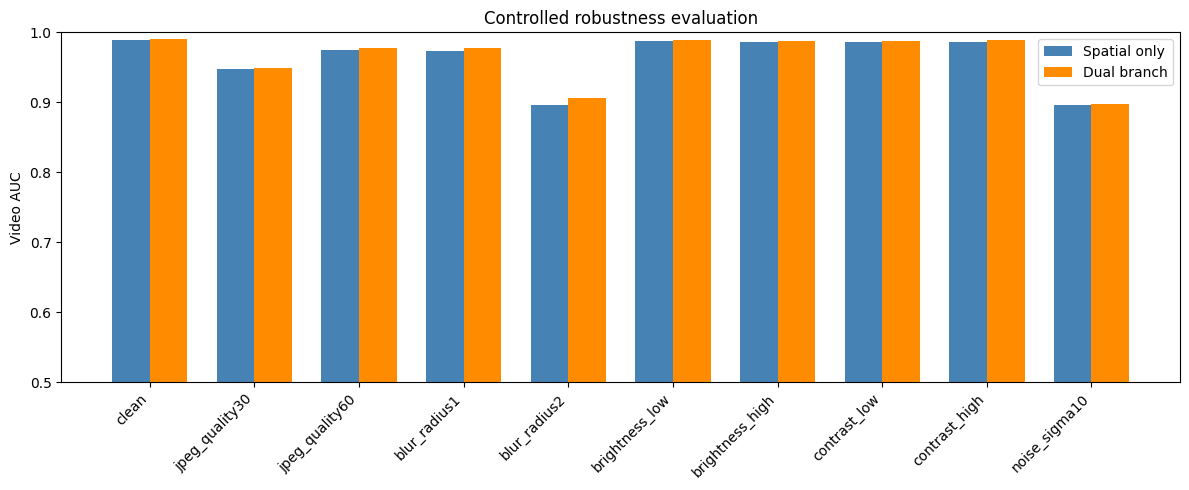

Saved robustness results and comparison figure


In [14]:
# EXPERIMENT 6 - Controlled robustness evaluation
# These corruption families overlap with the training augmentation families.
# The experiment measures performance at fixed severities rather than claiming that every corruption type is entirely unseen.
# A progress record is saved after each model/condition. After a restart, only missing predictions are generated. Existing crops and official checkpoints are never modified.

from PIL import ImageFilter, ImageEnhance

ROBUSTNESS_VERSION = "robustness_v2"
ROBUSTNESS_SEED = 789
ROBUSTNESS_PROGRESS_PATH = (f"{ADDITIONAL_EXP_DIR}/{ROBUSTNESS_VERSION}_progress.json")
ROBUSTNESS_RESULT_PATH = (f"{ADDITIONAL_EXP_DIR}/robustness_results.json")

if torch.device(device).type != "cuda":
    raise RuntimeError(
        "Robustness inference requires a GPU. Run Resume A, Cell 10, "
        "Cell 12, Step 2, Resume B, Resume C and Experiment Setup first.")

for object_name in [
    "spatial_model",
    "dual_model",
    "sp_test_df",
    "du_test_df",
]:
    if object_name not in globals():
        raise RuntimeError(f"{object_name} is missing. Run Resume B and Resume C first.")

def jpeg_compression(quality):
    def transform(image):
        buffer = io.BytesIO()
        image.save(buffer, format="JPEG", quality=quality)
        buffer.seek(0)
        return PILImage.open(buffer).convert("RGB")
    return transform


def gaussian_blur(radius):
    return lambda image: image.filter(ImageFilter.GaussianBlur(radius=radius))

def brightness_change(factor):
    return lambda image: ImageEnhance.Brightness(image).enhance(factor)

def contrast_change(factor):
    return lambda image: ImageEnhance.Contrast(image).enhance(factor)

def gaussian_noise(sigma):
    def transform(image):
        array = np.asarray(image).astype(np.float32)
        noise = np.random.normal(0, sigma, array.shape)
        array = np.clip(array + noise, 0, 255).astype(np.uint8)
        return PILImage.fromarray(array)
    return transform

robustness_conditions = {
    "clean": None,
    "jpeg_quality30": jpeg_compression(30),
    "jpeg_quality60": jpeg_compression(60),
    "blur_radius1": gaussian_blur(1.0),
    "blur_radius2": gaussian_blur(2.0),
    "brightness_low": brightness_change(0.7),
    "brightness_high": brightness_change(1.3),
    "contrast_low": contrast_change(0.7),
    "contrast_high": contrast_change(1.3),
    "noise_sigma10": gaussian_noise(10),
}

robustness_config = {
    "version": ROBUSTNESS_VERSION,
    "seed": ROBUSTNESS_SEED,
    "conditions": list(robustness_conditions.keys()),
    "maximum_frames_per_video": 20,
    "manifest_sha256": experiment_file_sha256(MANIFEST_FF),
    "spatial_checkpoint_sha256": experiment_file_sha256(
        f"{CKPT_DIR}/spatial_best.pth"
    ),
    "dual_checkpoint_sha256": experiment_file_sha256(
        FINAL_DUAL_CHECKPOINT
    ),
}

robustness_signature = hashlib.sha256(json.dumps(robustness_config, sort_keys=True).encode("utf-8")).hexdigest()

if os.path.exists(ROBUSTNESS_PROGRESS_PATH):
    with open(ROBUSTNESS_PROGRESS_PATH) as f:
        robustness_progress = json.load(f)

    if robustness_progress.get("signature") != robustness_signature:
        raise RuntimeError("Existing robustness progress belongs to a different manifest or checkpoint. It has not been overwritten.")
else:
    robustness_progress = {"signature": robustness_signature,"completed_predictions": {},}

def robustness_tag(model_name, condition_name):
    return (f"{ROBUSTNESS_VERSION}_{model_name}_test_{condition_name}")

def robustness_prediction_is_complete(model_name, condition_name):
    completed = robustness_progress["completed_predictions"].get(condition_name,[],)

    if model_name not in completed:
        return False

    if condition_name == "clean":
        tag = f"{model_name}_test_final"
    else:
        tag = robustness_tag(model_name, condition_name)

    return (
        os.path.exists(f"{PRED_DIR}/{tag}.csv")
        and os.path.exists(f"{PRED_DIR}/{tag}_frames.csv")
    )


def mark_robustness_prediction_complete(model_name, condition_name):
    completed = robustness_progress["completed_predictions"].setdefault(condition_name, [],)
    if model_name not in completed:
        completed.append(model_name)
    experiment_save_json(robustness_progress, ROBUSTNESS_PROGRESS_PATH,)


def load_or_run_robustness_prediction(
    model_name,
    model,
    dual,
    condition_name,
    transform_function,
):
    if condition_name == "clean":
        tag = f"{model_name}_test_final"
        video_path = f"{PRED_DIR}/{tag}.csv"
        frame_path = f"{PRED_DIR}/{tag}_frames.csv"

        if not os.path.exists(video_path) or not os.path.exists(frame_path):
            raise FileNotFoundError( f"Clean baseline predictions are missing for {model_name}. Run Cell 17 first.")

        mark_robustness_prediction_complete(model_name, condition_name)
        return pd.read_csv(video_path)

    tag = robustness_tag(model_name, condition_name)

    if robustness_prediction_is_complete(model_name, condition_name):
        print(f"  Reusing saved {model_name} predictions")
        return pd.read_csv(f"{PRED_DIR}/{tag}.csv")

    np.random.seed(ROBUSTNESS_SEED)

    video_df, _ = generate_predictions(
        model=model,
        manifest_path=MANIFEST_FF,
        split="test",
        processed_root=FF_PROCESSED,
        device=device,
        dual=dual,
        model_name=model_name,
        max_frames=20,
        has_split=True,
        batch_size=20,
        condition=condition_name,
        output_tag=tag,
        image_transform=transform_function,
    )

    mark_robustness_prediction_complete(model_name, condition_name)
    return video_df


robustness_results = {
    "signature": robustness_signature,
    "config": robustness_config,
    "note": (
        "Corruption families overlap with training augmentation; "
        "this is a controlled fixed-severity evaluation."
    ),
    "conditions": {},
}

clean_spatial_auc = float(SPATIAL_VIDEO_AUC)
clean_dual_auc = float(DUAL_VIDEO_AUC)

for condition_name, transform_function in robustness_conditions.items():
    print(f"\nROBUSTNESS CONDITION: {condition_name}")

    spatial_condition_df = load_or_run_robustness_prediction(
        model_name="spatial",
        model=spatial_model,
        dual=False,
        condition_name=condition_name,
        transform_function=transform_function,
    )

    dual_condition_df = load_or_run_robustness_prediction(
        model_name="dual",
        model=dual_model,
        dual=True,
        condition_name=condition_name,
        transform_function=transform_function,
    )

    spatial_coverage = validate_prediction_coverage(
        prediction_df=spatial_condition_df,
        manifest_path=MANIFEST_FF,
        split="test",
        has_split=True,
        description=f"Spatial robustness {condition_name}",
        require_complete=True,
    )

    dual_coverage = validate_prediction_coverage(
        prediction_df=dual_condition_df,
        manifest_path=MANIFEST_FF,
        split="test",
        has_split=True,
        description=f"Dual robustness {condition_name}",
        require_complete=True,
    )

    if set(spatial_condition_df["video_id"].astype(str)) != set(
        dual_condition_df["video_id"].astype(str)
    ):
        raise RuntimeError(
            f"Spatial and dual video IDs differ for {condition_name}."
        )

    spatial_metrics = metrics_from_predictions(spatial_condition_df)
    dual_metrics = metrics_from_predictions(dual_condition_df)

    spatial_auc_drop = clean_spatial_auc - spatial_metrics["auc"]
    dual_auc_drop = clean_dual_auc - dual_metrics["auc"]

    robustness_results["conditions"][condition_name] = {
        "spatial": {
            "metrics": spatial_metrics,
            "auc_drop_from_clean": float(spatial_auc_drop),
            "coverage": spatial_coverage,
        },
        "dual": {
            "metrics": dual_metrics,
            "auc_drop_from_clean": float(dual_auc_drop),
            "coverage": dual_coverage,
        },
        "dual_minus_spatial_auc": float(
            dual_metrics["auc"] - spatial_metrics["auc"]
        ),
    }

    experiment_save_json(
        robustness_results,
        ROBUSTNESS_RESULT_PATH,
    )

    print(
        f"  Spatial AUC {spatial_metrics['auc']:.4f} "
        f"drop {spatial_auc_drop:+.4f} | "
        f"Dual AUC {dual_metrics['auc']:.4f} "
        f"drop {dual_auc_drop:+.4f}"
    )
    print("  Condition result and restart progress saved")

condition_names = list(robustness_conditions.keys())
spatial_aucs = [
    robustness_results["conditions"][name]["spatial"]["metrics"]["auc"]
    for name in condition_names
]
dual_aucs = [
    robustness_results["conditions"][name]["dual"]["metrics"]["auc"]
    for name in condition_names
]

positions = np.arange(len(condition_names))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(positions - bar_width / 2, spatial_aucs, bar_width, label="Spatial only", color="steelblue",)
ax.bar(positions + bar_width / 2, dual_aucs, bar_width, label="Dual branch",color="darkorange",)
ax.set_xticks(positions)
ax.set_xticklabels(condition_names, rotation=45, ha="right")
ax.set_ylabel("Video AUC")
ax.set_title("Controlled robustness evaluation")
ax.set_ylim(0.5, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig(f"{ADDITIONAL_EXP_DIR}/robustness_comparison.png",dpi=150,bbox_inches="tight",)
plt.show()

print("Saved robustness results and comparison figure")

## 6.7 Controlled inference timing

CUDA warm-up and synchronisation isolate model-forward time for fixed 224 × 224
tensors at batch sizes 1 and 20. Disk access, JPEG decoding, PIL conversion and
normalisation are excluded from the timed region. These results complement the
end-to-end pipeline times stored in prediction CSVs.

CONTROLLED FORWARD-PASS TIMING
  GPU: Tesla T4
  Warm-up: 30; repetitions: 100
  spatial          batch  1 | mean 15.189 ms | median 14.829 ms | std 1.043 ms/batch | 15.189 ms/image | 65.8 images/s
  dual             batch  1 | mean 16.411 ms | median 16.337 ms | std 0.620 ms/batch | 16.411 ms/image | 60.9 images/s
  frequency_only   batch  1 | mean 1.229 ms | median 1.208 ms | std 0.071 ms/batch | 1.229 ms/image | 813.7 images/s
  spatial          batch 20 | mean 64.137 ms | median 64.091 ms | std 0.485 ms/batch | 3.207 ms/image | 311.8 images/s
  dual             batch 20 | mean 69.533 ms | median 69.481 ms | std 0.404 ms/batch | 3.477 ms/image | 287.6 images/s
  frequency_only   batch 20 | mean 4.958 ms | median 4.953 ms | std 0.037 ms/batch | 0.248 ms/image | 4033.9 images/s


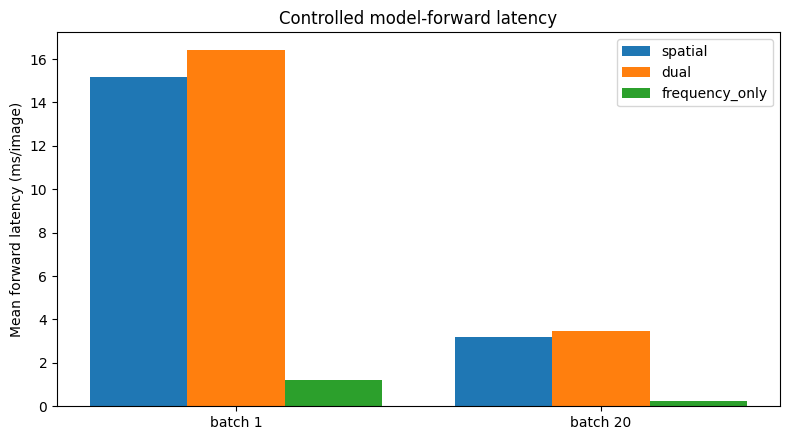

Saved controlled inference timing results and figure


In [12]:
# EXPERIMENT 7 - Controlled inference timing
# Load the saved frequency-only checkpoint explicitly. Timing covers the
# forward pass only; decoding, PIL conversion and transforms occur beforehand.

TIMING_WARMUP = 30
TIMING_REPETITIONS = 100
TIMING_BATCH_SIZES = [1, 20]
FREQUENCY_TIMING_CKPT = f"{CKPT_DIR}/frequency_only_best.pth"

if torch.device(device).type != "cuda":
    raise RuntimeError("Controlled timing requires a CUDA GPU.")

for object_name in [
    "spatial_model",
    "dual_model",
    "sp_test_df",
    "du_test_df",
]:
    if object_name not in globals():
        raise RuntimeError(f"{object_name} is missing. Run Resume B and Resume C first.")

if not os.path.exists(FREQUENCY_TIMING_CKPT):
    raise FileNotFoundError("frequency_only_best.pth is missing. Complete Experiment 5 before running the final timing comparison.")

class FrequencyOnlyTimingModel(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()
        self.freq = FrequencyBranchV2()
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, raw_images):
        features = self.freq(raw_images)
        return self.classifier(features).squeeze(1)

frequency_timing_checkpoint = torch.load(FREQUENCY_TIMING_CKPT, map_location=device, weights_only=False,)
frequency_timing_dropout = float(frequency_timing_checkpoint.get("config", {}).get("dropout", 0.4))
frequency_timing_model = FrequencyOnlyTimingModel(dropout=frequency_timing_dropout).to(device)
frequency_timing_model.load_state_dict(frequency_timing_checkpoint["model_state"])

timing_source = pd.read_csv(f"{PRED_DIR}/dual_test_final_frames.csv").iloc[0]
timing_label_folder = ("fake" if int(timing_source["true_label"]) == 1 else "real")
timing_image_path = os.path.join(FF_PROCESSED,"test", timing_label_folder, timing_source["frame_name"],)
timing_bgr = cv2.imread(timing_image_path)

if timing_bgr is None:
    raise RuntimeError(f"Could not read timing crop: {timing_image_path}")

timing_rgb = cv2.cvtColor(timing_bgr, cv2.COLOR_BGR2RGB)
timing_pil = PILImage.fromarray(timing_rgb)
timing_norm_single = norm_transform(timing_pil).unsqueeze(0).to(device)
timing_raw_single = raw_transform(timing_pil).unsqueeze(0).to(device)

spatial_model.eval()
dual_model.eval()
frequency_timing_model.eval()

def controlled_cuda_timing(model_name, forward_function, batch_size):
    for _ in range(TIMING_WARMUP):
        with torch.inference_mode():
            forward_function()
    torch.cuda.synchronize()
    elapsed_times = []
    for _ in range(TIMING_REPETITIONS):
        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)
        start_event.record()
        with torch.inference_mode():
            forward_function()
        end_event.record()
        end_event.synchronize()
        elapsed_times.append(float(start_event.elapsed_time(end_event)))
    elapsed_times = np.asarray(elapsed_times, dtype=float)

    return {
        "model": model_name,
        "batch_size": int(batch_size),
        "warmup_iterations": int(TIMING_WARMUP),
        "timed_repetitions": int(TIMING_REPETITIONS),
        "mean_batch_ms": float(elapsed_times.mean()),
        "median_batch_ms": float(np.median(elapsed_times)),
        "std_batch_ms": float(elapsed_times.std()),
        "mean_per_image_ms": float(elapsed_times.mean() / batch_size),
        "throughput_images_per_second": float(
            1000 * batch_size / elapsed_times.mean()
        ),
    }

timing_results = {
    "gpu": torch.cuda.get_device_name(0),
    "torch_version": torch.__version__,
    "cuda_version": torch.version.cuda,
    "input_shape": [3, 224, 224],
    "timed_region": "model forward pass only",
    "warmup_iterations": TIMING_WARMUP,
    "timed_repetitions": TIMING_REPETITIONS,
    "results": [],
    "pipeline_reference": {
        "spatial_mean_ms_per_video": float(
            sp_test_df["scoring_pipeline_ms"].mean()
        ),
        "spatial_median_ms_per_video": float(
            sp_test_df["scoring_pipeline_ms"].median()
        ),
        "dual_mean_ms_per_video": float(
            du_test_df["scoring_pipeline_ms"].mean()
        ),
        "dual_median_ms_per_video": float(
            du_test_df["scoring_pipeline_ms"].median()
        ),
        "pipeline_note": (
            "Includes crop loading, preprocessing, device transfer, "
            "forward passes and video aggregation."
        ),
    },
}

for timing_batch_size in TIMING_BATCH_SIZES:
    timing_norm = timing_norm_single.repeat(timing_batch_size, 1, 1, 1)
    timing_raw = timing_raw_single.repeat(timing_batch_size, 1, 1, 1)
    timing_results["results"].append(
        controlled_cuda_timing(
            model_name="spatial",
            forward_function=lambda: spatial_model(timing_norm),
            batch_size=timing_batch_size,
        )
    )

    timing_results["results"].append(
        controlled_cuda_timing(
            model_name="dual",
            forward_function=lambda: dual_model(timing_norm, timing_raw),
            batch_size=timing_batch_size,
        )
    )

    timing_results["results"].append(
        controlled_cuda_timing(
            model_name="frequency_only",
            forward_function=lambda: frequency_timing_model(timing_raw),
            batch_size=timing_batch_size,
        )
    )

print("CONTROLLED FORWARD-PASS TIMING")
print(f"  GPU: {timing_results['gpu']}")
print(f"  Warm-up: {TIMING_WARMUP}; repetitions: {TIMING_REPETITIONS}")

for result in timing_results["results"]:
    print(
        f"  {result['model']:<16} batch {result['batch_size']:>2} | "
        f"mean {result['mean_batch_ms']:.3f} ms | "
        f"median {result['median_batch_ms']:.3f} ms | "
        f"std {result['std_batch_ms']:.3f} ms/batch | "
        f"{result['mean_per_image_ms']:.3f} ms/image | "
        f"{result['throughput_images_per_second']:.1f} images/s"
    )
experiment_save_json(timing_results, f"{ADDITIONAL_EXP_DIR}/controlled_inference_timing.json",)

timing_plot_df = pd.DataFrame(timing_results["results"])
fig, ax = plt.subplots(figsize=(8, 4.5))

model_names = list(timing_plot_df["model"].unique())
plot_positions = np.arange(len(TIMING_BATCH_SIZES))
plot_width = 0.8 / len(model_names)

for model_index, model_name in enumerate(model_names):
    subset = timing_plot_df[timing_plot_df["model"] == model_name]
    subset = subset.set_index("batch_size").reindex(TIMING_BATCH_SIZES)
    offset = (model_index - (len(model_names) - 1) / 2) * plot_width
    ax.bar(plot_positions + offset, subset["mean_per_image_ms"], plot_width, label=model_name,)

ax.set_xticks(plot_positions)
ax.set_xticklabels([ f"batch {value}" for value in TIMING_BATCH_SIZES])
ax.set_ylabel("Mean forward latency (ms/image)")
ax.set_title("Controlled model-forward latency")
ax.legend()
plt.tight_layout()
plt.savefig(f"{ADDITIONAL_EXP_DIR}/controlled_inference_timing.png", dpi=150, bbox_inches="tight",)
plt.show()

del frequency_timing_model
torch.cuda.empty_cache()

print("Saved controlled inference timing results and figure")

## 6.8 Official Celeb-DF test-list evaluation

The earlier full-collection result is useful for broad zero-shot coverage but
is not directly comparable with published official-protocol results. This cell
builds a manifest from `List_of_testing_videos.txt`, reports face-crop coverage
and evaluates both locked models without additional training.

In [15]:
# EXPERIMENT 8 - Official Celeb-DF test-list evaluation
# Builds a manifest from List_of_testing_videos.txt and evaluates the existing
# spatial and official dual models without reprocessing any videos.

CELEB_TEST_LIST = os.path.join(
    CELEB_ROOT,
    "List_of_testing_videos.txt",
)
CELEB_OFFICIAL_MANIFEST = (
    f"{ADDITIONAL_EXP_DIR}/celeb_official_test_manifest.csv"
)

if not os.path.exists(CELEB_TEST_LIST):
    raise FileNotFoundError(
        f"Celeb-DF official test list missing: {CELEB_TEST_LIST}"
    )

full_celeb_manifest = pd.read_csv(MANIFEST_CELEB)
full_celeb_manifest["video_id"] = full_celeb_manifest["video_id"].astype(str)

manifest_by_id = {
    row["video_id"]: row.to_dict()
    for _, row in full_celeb_manifest.iterrows()
}

official_records = []

with open(CELEB_TEST_LIST) as f:
    for line_number, line in enumerate(f, start=1):
        line = line.strip()
        if not line:
            continue

        parts = line.split(maxsplit=1)
        if len(parts) != 2:
            raise ValueError(
                f"Unexpected official-list format at line {line_number}: {line}"
            )

        official_token, relative_path = parts
        relative_path = relative_path.replace("\\", "/")
        category = relative_path.split("/", 1)[0]
        video_stem = os.path.splitext(os.path.basename(relative_path))[0]
        video_id = f"{category}_{video_stem}"

        if category in ["Celeb-real", "YouTube-real"]:
            project_label = 0
            expected_official_token = 1
        elif category == "Celeb-synthesis":
            project_label = 1
            expected_official_token = 0
        else:
            raise ValueError(
                f"Unknown Celeb-DF category in official list: {category}"
            )

        if int(official_token) != expected_official_token:
            raise ValueError(
                f"Official label token does not match folder identity at "
                f"line {line_number}: {line}"
            )

        if video_id not in manifest_by_id:
            raise RuntimeError(
                f"Official test video is missing from celeb_manifest.csv: {video_id}"
            )

        manifest_row = manifest_by_id[video_id].copy()

        if int(manifest_row["label"]) != project_label:
            raise RuntimeError(f"Manifest label mismatch for {video_id}")

        manifest_row["official_relative_path"] = relative_path
        manifest_row["official_list_token"] = int(official_token)
        official_records.append(manifest_row)

official_celeb_manifest = pd.DataFrame(official_records)

if official_celeb_manifest.empty:
    raise RuntimeError("The official Celeb-DF test manifest is empty.")

if official_celeb_manifest["video_id"].duplicated().any():
    raise RuntimeError("The official Celeb-DF test list contains duplicate videos.")

if official_celeb_manifest["label"].nunique() != 2:
    raise RuntimeError("The official Celeb-DF test list requires both classes.")

_atomic_dataframe_save(
    official_celeb_manifest,
    CELEB_OFFICIAL_MANIFEST,
)

print("OFFICIAL CELEB-DF TEST MANIFEST")
print(f"  Videos : {len(official_celeb_manifest):,}")
print(official_celeb_manifest.groupby("label_str").size().to_string())

spatial_celeb_official_df, spatial_celeb_official_frames = generate_predictions(
    model=spatial_model,
    manifest_path=CELEB_OFFICIAL_MANIFEST,
    split="official_test",
    processed_root=CELEB_PROCESSED,
    device=device,
    dual=False,
    model_name="spatial",
    max_frames=20,
    has_split=False,
    batch_size=20,
    condition="clean",
    output_tag="spatial_celeb_official_test",
)

dual_celeb_official_df, dual_celeb_official_frames = generate_predictions(
    model=dual_model,
    manifest_path=CELEB_OFFICIAL_MANIFEST,
    split="official_test",
    processed_root=CELEB_PROCESSED,
    device=device,
    dual=True,
    model_name="dual",
    max_frames=20,
    has_split=False,
    batch_size=20,
    condition="clean",
    output_tag="dual_celeb_official_test",
)

spatial_official_coverage = validate_prediction_coverage(
    prediction_df=spatial_celeb_official_df,
    manifest_path=CELEB_OFFICIAL_MANIFEST,
    split="official_test",
    has_split=False,
    description="Spatial Celeb-DF official test",
    require_complete=False,
)

dual_official_coverage = validate_prediction_coverage(
    prediction_df=dual_celeb_official_df,
    manifest_path=CELEB_OFFICIAL_MANIFEST,
    split="official_test",
    has_split=False,
    description="Dual Celeb-DF official test",
    require_complete=False,
)

if set(spatial_celeb_official_df["video_id"].astype(str)) != set(
    dual_celeb_official_df["video_id"].astype(str)
):
    raise RuntimeError(
        "Spatial and dual models evaluated different official Celeb-DF videos."
    )

spatial_official_metrics = metrics_from_predictions(spatial_celeb_official_df)
dual_official_metrics = metrics_from_predictions(dual_celeb_official_df)

official_crop_coverage = {
    "evaluated_videos": int(len(dual_celeb_official_df)),
    "total_selected_crops": int(dual_celeb_official_df["n_frames"].sum()),
    "mean_selected_crops_per_video": float(
        dual_celeb_official_df["n_frames"].mean()
    ),
    "minimum_selected_crops_per_video": int(
        dual_celeb_official_df["n_frames"].min()
    ),
    "maximum_selected_crops_per_video": int(
        dual_celeb_official_df["n_frames"].max()
    ),
}

print("\nOFFICIAL CELEB-DF TEST-LIST RESULTS")
print(f"  Spatial video AUC : {spatial_official_metrics['auc']:.4f}")
print(f"  Dual video AUC    : {dual_official_metrics['auc']:.4f}")
print(f"  Difference        : "
      f"{dual_official_metrics['auc'] - spatial_official_metrics['auc']:+.4f}")
print(f"  Dual coverage      : {dual_official_coverage['coverage']:.2%}")
print(f"  Selected crops     : {official_crop_coverage['total_selected_crops']:,}")
print(f"  Mean crops/video   : "
      f"{official_crop_coverage['mean_selected_crops_per_video']:.1f}")

official_celeb_result = {
    "protocol": "Celeb-DF v2 List_of_testing_videos.txt",
    "training_on_celeb_df": False,
    "maximum_frames_per_video": 20,
    "spatial": spatial_official_metrics,
    "dual": dual_official_metrics,
    "spatial_coverage": spatial_official_coverage,
    "dual_coverage": dual_official_coverage,
    "face_crop_coverage": official_crop_coverage,
    "dual_minus_spatial_auc": float(
        dual_official_metrics["auc"] - spatial_official_metrics["auc"]
    ),
    "full_collection_dual_auc": float(CELEB_AUC),
}

experiment_save_json(
    official_celeb_result,
    f"{ADDITIONAL_EXP_DIR}/celeb_official_test_results.json",
)

print("Saved official Celeb-DF manifest and evaluation results")

OFFICIAL CELEB-DF TEST MANIFEST
  Videos : 518
label_str
fake    340
real    178


spatial official_test clean:   0%|          | 0/518 [00:00<?, ?it/s]

Premature end of JPEG file


Saved 502 video rows to /kaggle/working/experiments/predictions/spatial_celeb_official_test.csv
Saved 9340 frame rows to /kaggle/working/experiments/predictions/spatial_celeb_official_test_frames.csv
Videos without usable crops: 16
Unreadable crop files: 0


dual official_test clean:   0%|          | 0/518 [00:00<?, ?it/s]

Premature end of JPEG file


Saved 502 video rows to /kaggle/working/experiments/predictions/dual_celeb_official_test.csv
Saved 9340 frame rows to /kaggle/working/experiments/predictions/dual_celeb_official_test_frames.csv
Videos without usable crops: 16
Unreadable crop files: 0

Spatial Celeb-DF official test coverage
  Expected  : 518
  Evaluated : 502
  Missing   : 16
  Coverage  : 96.91%

Dual Celeb-DF official test coverage
  Expected  : 518
  Evaluated : 502
  Missing   : 16
  Coverage  : 96.91%

OFFICIAL CELEB-DF TEST-LIST RESULTS
  Spatial video AUC : 0.8305
  Dual video AUC    : 0.8362
  Difference        : +0.0057
  Dual coverage      : 96.91%
  Selected crops     : 9,340
  Mean crops/video   : 18.6
Saved official Celeb-DF manifest and evaluation results


### 6.8.1 Fixed-threshold errors and class-specific coverage

AUC measures ranking across all possible thresholds and does not show which
errors occur at the deployed 0.5 threshold. This audit therefore plots
confusion matrices for both models on FF++ and the official Celeb-DF subset.
Counts are accompanied by percentages within each true class, which is
important because the datasets contain more manipulated than authentic videos.
It also reports face-crop coverage separately by class so that missing external
videos are not hidden by a single overall percentage. No threshold is selected
or changed here.


CLASS-SPECIFIC FACE-CROP COVERAGE
          dataset   model label_name  expected  evaluated  missing  coverage
             FF++ Spatial       real       147        147        0  1.000000
             FF++ Spatial       fake       591        591        0  1.000000
             FF++    Dual       real       147        147        0  1.000000
             FF++    Dual       fake       591        591        0  1.000000
Celeb-DF official Spatial       real       178        162       16  0.910112
Celeb-DF official Spatial       fake       340        340        0  1.000000
Celeb-DF official    Dual       real       178        162       16  0.910112
Celeb-DF official    Dual       fake       340        340        0  1.000000
FF++               Spatial | accuracy 0.9336 | balanced accuracy 0.9509 | FPR 0.0204 | FNR 0.0778
FF++               Dual    | accuracy 0.9634 | balanced accuracy 0.9567 | FPR 0.0544 | FNR 0.0321
Celeb-DF official  Spatial | accuracy 0.7171 | balanced accuracy 0.7330 | FPR

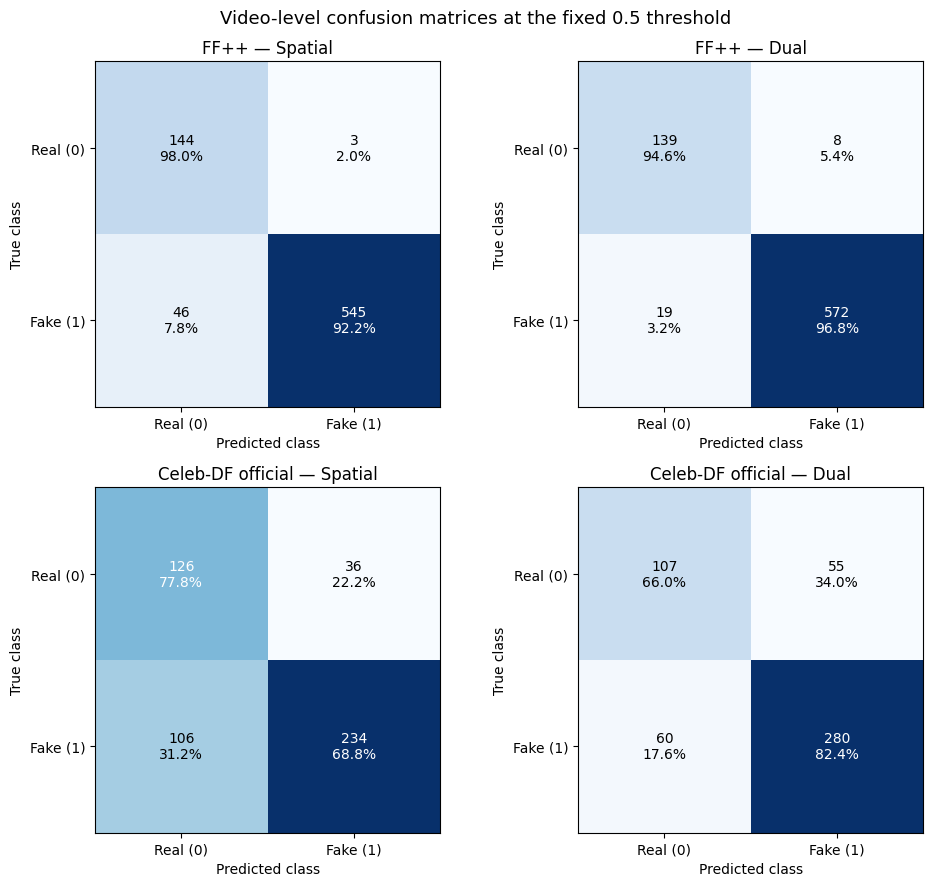


Saved class coverage to /kaggle/working/experiments/additional_experiments/coverage_by_class.csv
Saved confusion-matrix figure to /kaggle/working/experiments/additional_experiments/fixed_threshold_confusion_matrices.png


In [14]:
# EVALUATION AUDIT - confusion matrices and class-specific coverage

ff_result_path = f"{CKPT_DIR}/ff_test_results_final.json"
celeb_official_result_path = (f"{ADDITIONAL_EXP_DIR}/celeb_official_test_results.json")
celeb_official_manifest_path = (f"{ADDITIONAL_EXP_DIR}/celeb_official_test_manifest.csv")

for required_path in [ff_result_path,celeb_official_result_path,celeb_official_manifest_path,]:
    if not os.path.exists(required_path):
        raise FileNotFoundError(f"Required evaluation artifact missing: {required_path}")

with open(ff_result_path) as file:
    fixed_threshold_ff = json.load(file)

with open(celeb_official_result_path) as file:
    fixed_threshold_celeb = json.load(file)

ff_test_manifest = pd.read_csv(MANIFEST_FF)
ff_test_manifest = ff_test_manifest[ff_test_manifest["split"] == "test"].copy()
celeb_official_manifest = pd.read_csv(celeb_official_manifest_path)

prediction_sources = {
    ("FF++", "Spatial"): pd.read_csv(f"{PRED_DIR}/spatial_test_final.csv"),
    ("FF++", "Dual"): pd.read_csv(f"{PRED_DIR}/dual_test_final.csv"),
    ("Celeb-DF official", "Spatial"): pd.read_csv(f"{PRED_DIR}/spatial_celeb_official_test.csv"),
    ("Celeb-DF official", "Dual"): pd.read_csv(f"{PRED_DIR}/dual_celeb_official_test.csv"),
}

saved_metric_sources = {
    ("FF++", "Spatial"): fixed_threshold_ff["spatial"],
    ("FF++", "Dual"): fixed_threshold_ff["dual"],
    ("Celeb-DF official", "Spatial"): fixed_threshold_celeb["spatial"],
    ("Celeb-DF official", "Dual"): fixed_threshold_celeb["dual"],
}

manifest_sources = {
    "FF++": ff_test_manifest,
    "Celeb-DF official": celeb_official_manifest,
}

def class_coverage_rows(dataset_name, model_name, manifest, predictions):
    expected = manifest.groupby("label").size().to_dict()
    evaluated = predictions.groupby("true_label").size().to_dict()
    rows = []
    for label, label_name in [(0, "real"), (1, "fake")]:
        n_expected = int(expected.get(label, 0))
        n_evaluated = int(evaluated.get(label, 0))
        rows.append({
            "dataset": dataset_name,
            "model": model_name,
            "label": int(label),
            "label_name": label_name,
            "expected": n_expected,
            "evaluated": n_evaluated,
            "missing": n_expected - n_evaluated,
            "coverage": (
                n_evaluated / n_expected if n_expected else None
            ),
        })
    return rows

coverage_rows = []
metric_sources = {}

for (dataset_name, model_name), predictions in prediction_sources.items():
    if predictions["video_id"].duplicated().any():
        raise RuntimeError(f"Duplicate video IDs in {dataset_name} {model_name} predictions.")

    manifest = manifest_sources[dataset_name][["video_id", "label"]].copy()
    if manifest["video_id"].duplicated().any():
        raise RuntimeError(f"Duplicate video IDs in the {dataset_name} manifest.")

    identity_check = predictions[["video_id", "true_label"]].merge(manifest,on="video_id",how="left",validate="one_to_one",indicator=True,)
    if (identity_check["_merge"] != "both").any():
        raise RuntimeError(
            f"Unknown video IDs in {dataset_name} {model_name} predictions."
        )
    if not (
        identity_check["true_label"].astype(int)
        == identity_check["label"].astype(int)
    ).all():
        raise RuntimeError(
            f"Label mismatch in {dataset_name} {model_name} predictions."
        )

    calculated_metrics = metrics_from_predictions(predictions)
    saved_metrics = saved_metric_sources[(dataset_name, model_name)]
    if calculated_metrics["cm"] != saved_metrics["cm"]:
        raise RuntimeError(
            f"Saved metrics disagree with {dataset_name} {model_name} predictions."
        )
    metric_sources[(dataset_name, model_name)] = calculated_metrics

    coverage_rows.extend(
        class_coverage_rows(
            dataset_name,
            model_name,
            manifest_sources[dataset_name],
            predictions,
        )
    )

coverage_by_class = pd.DataFrame(coverage_rows)
coverage_path = f"{ADDITIONAL_EXP_DIR}/coverage_by_class.csv"
_atomic_dataframe_save(coverage_by_class, coverage_path)

print("CLASS-SPECIFIC FACE-CROP COVERAGE")
display_columns = [
    "dataset", "model", "label_name", "expected",
    "evaluated", "missing", "coverage",
]
print(coverage_by_class[display_columns].to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
figure_order = [
    ("FF++", "Spatial"),
    ("FF++", "Dual"),
    ("Celeb-DF official", "Spatial"),
    ("Celeb-DF official", "Dual"),
]

audit_record = {
    "threshold": 0.5,
    "positive_class": "fake/manipulated",
    "selection_note": "The threshold was fixed before test evaluation.",
    "coverage_by_class": coverage_rows,
    "results": {},
}

for axis, key in zip(axes.flat, figure_order):
    dataset_name, model_name = key
    metrics = metric_sources[key]
    matrix = np.asarray(metrics["cm"], dtype=int)

    if matrix.shape != (2, 2):
        raise RuntimeError(
            f"Unexpected confusion-matrix shape for {dataset_name} {model_name}."
        )

    row_totals = matrix.sum(axis=1, keepdims=True)
    row_percentages = np.divide(
        matrix,
        row_totals,
        out=np.zeros_like(matrix, dtype=float),
        where=row_totals != 0,
    )

    axis.imshow(matrix, cmap="Blues")
    for row_index in range(2):
        for column_index in range(2):
            axis.text(
                column_index,
                row_index,
                f"{matrix[row_index, column_index]:,}\n"
                f"{row_percentages[row_index, column_index]:.1%}",
                ha="center",
                va="center",
                color=(
                    "white"
                    if matrix[row_index, column_index] > matrix.max() / 2
                    else "black"
                ),
            )

    axis.set_xticks([0, 1])
    axis.set_xticklabels(["Real (0)", "Fake (1)"])
    axis.set_yticks([0, 1])
    axis.set_yticklabels(["Real (0)", "Fake (1)"])
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("True class")
    axis.set_title(f"{dataset_name} — {model_name}")

    record_key = f"{dataset_name.lower().replace(' ', '_').replace('-', '_')}__{model_name.lower()}"
    audit_record["results"][record_key] = {
        "confusion_matrix": matrix.tolist(),
        "accuracy": float(metrics["acc"]),
        "balanced_accuracy": float(metrics["balanced_acc"]),
        "specificity": float(metrics["specificity"]),
        "false_positive_rate": float(metrics["fpr"]),
        "false_negative_rate": float(metrics["fnr"]),
    }

    print(
        f"{dataset_name:<18} {model_name:<7} | "
        f"accuracy {metrics['acc']:.4f} | "
        f"balanced accuracy {metrics['balanced_acc']:.4f} | "
        f"FPR {metrics['fpr']:.4f} | FNR {metrics['fnr']:.4f}"
    )

fig.suptitle(
    "Video-level confusion matrices at the fixed 0.5 threshold",
    fontsize=13,
)
plt.tight_layout()
confusion_figure_path = (
    f"{ADDITIONAL_EXP_DIR}/fixed_threshold_confusion_matrices.png"
)
plt.savefig(confusion_figure_path, dpi=150, bbox_inches="tight")
plt.show()

experiment_save_json(
    audit_record,
    f"{ADDITIONAL_EXP_DIR}/fixed_threshold_error_audit.json",
)

print(f"\nSaved class coverage to {coverage_path}")
print(f"Saved confusion-matrix figure to {confusion_figure_path}")

## 6.9 Validation-locked selective triage

The absolute distance between the dual score and 0.5 is used only as a ranking
signal for referral. Margin thresholds are fitted on FF++ validation at target
coverages of 80%, 90% and 95%, then locked and applied unchanged to FF++ test
and the evaluable Celeb-DF official-list subset. Risk–coverage curves and AURC
show how error changes as more cases are handled automatically. Because the
scores are not calibrated probabilities, the margin is not called confidence.


FF++ validation triage input coverage
  Expected  : 719
  Evaluated : 719
  Missing   : 0
  Coverage  : 100.00%
LOCKED MARGIN THRESHOLDS - FF++ VALIDATION ONLY
  Target 80% -> threshold 0.4223 (validation coverage 80.1%)
  Target 90% -> threshold 0.2903 (validation coverage 90.1%)
  Target 95% -> threshold 0.1713 (validation coverage 95.1%)

FF++ test triage input coverage
  Expected  : 738
  Evaluated : 738
  Missing   : 0
  Coverage  : 100.00%

Celeb-DF official triage input coverage
  Expected  : 518
  Evaluated : 502
  Missing   : 16
  Coverage  : 96.91%

SELECTIVE TRIAGE - FF++ TEST
  Target 80% | eligible coverage 76.7% | end-to-end coverage 76.7% | accepted acc 0.9965 | FPR 0.0000 FNR 0.0041 | referred error 0.1453
  Target 90% | eligible coverage 89.2% | end-to-end coverage 89.2% | accepted acc 0.9863 | FPR 0.0087 FNR 0.0147 | referred error 0.2250
  Target 95% | eligible coverage 94.3% | end-to-end coverage 94.3% | accepted acc 0.9784 | FPR 0.0238 FNR 0.0211 | referred error 

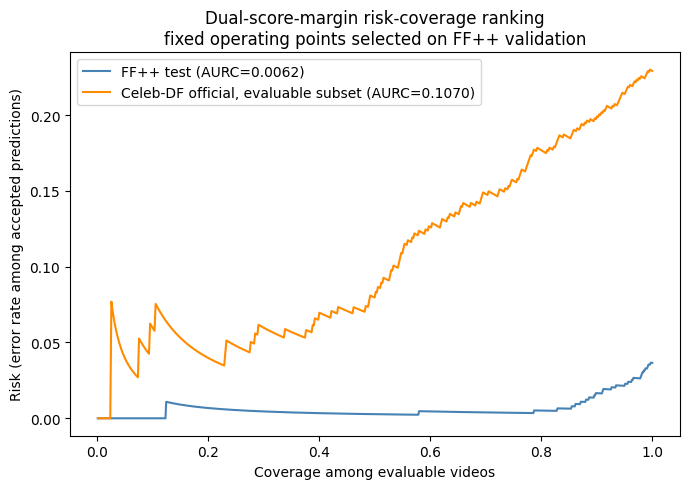


Saved triage thresholds, results and risk-coverage figure


In [6]:
# EXPERIMENT 9 - Selective triage using the dual-score margin
# Thresholds are selected on FF++ validation, locked, then evaluated on
# FF++ test and the usable subset of the Celeb-DF official test list.

TARGET_COVERAGES = [0.80, 0.90, 0.95]

def prepare_triage_predictions(dataframe, description):
    required = {"video_id", "true_label", "video_score"}
    missing = required - set(dataframe.columns)

    if missing:
        raise ValueError(f"{description} is missing: {sorted(missing)}")

    dataframe = dataframe.copy()
    dataframe["video_id"] = dataframe["video_id"].astype(str)

    if dataframe.empty:
        raise ValueError(f"{description} is empty.")

    if dataframe["video_id"].duplicated().any():
        raise RuntimeError(f"{description} contains duplicate video IDs.")

    if not dataframe["video_score"].between(0, 1).all():
        raise RuntimeError(f"{description} contains scores outside [0,1].")

    dataframe["true_label"] = dataframe["true_label"].astype(int)
    dataframe["pred_label"] = (dataframe["video_score"] >= 0.5).astype(int)
    dataframe["margin"] = (dataframe["video_score"] - 0.5).abs()

    return dataframe


validation_path = (
    f"{PRED_DIR}/step4_video_auc_v2_current_dual_val_final.csv"
)

if not os.path.exists(validation_path):
    raise FileNotFoundError(f"Validation predictions missing: {validation_path}")

val_dual_df = prepare_triage_predictions(
    pd.read_csv(validation_path),
    "FF++ validation predictions",
)

validation_coverage = validate_prediction_coverage(
    prediction_df=val_dual_df,
    manifest_path=MANIFEST_FF,
    split="val",
    has_split=True,
    description="FF++ validation triage input",
    require_complete=True,
)

sorted_margins = np.sort(val_dual_df["margin"].to_numpy())
n_val = len(sorted_margins)
margin_thresholds = {}

for target_coverage in TARGET_COVERAGES:
    cutoff_index = int(np.floor((1 - target_coverage) * n_val))
    cutoff_index = min(max(cutoff_index, 0), n_val - 1)
    margin_thresholds[target_coverage] = float(sorted_margins[cutoff_index])

print("LOCKED MARGIN THRESHOLDS - FF++ VALIDATION ONLY")
for target_coverage, threshold in margin_thresholds.items():
    achieved = float((val_dual_df["margin"] >= threshold).mean())
    print(
        f"  Target {target_coverage:.0%} -> threshold {threshold:.4f} "
        f"(validation coverage {achieved:.1%})"
    )

experiment_save_json(
    {
        "target_coverages": TARGET_COVERAGES,
        "margin_thresholds": margin_thresholds,
        "fit_split": "FF++ validation",
        "n_validation_videos": int(n_val),
        "validation_coverage_check": validation_coverage,
    },
    f"{ADDITIONAL_EXP_DIR}/triage_thresholds.json",
)


def evaluate_triage(dataframe, thresholds, expected_total=None):
    dataframe = prepare_triage_predictions(dataframe, "triage predictions")
    expected_total = len(dataframe) if expected_total is None else int(expected_total)

    if expected_total < len(dataframe):
        raise ValueError("expected_total cannot be smaller than the evaluated subset.")

    results = {}

    for target_coverage, threshold in thresholds.items():
        accepted = dataframe[dataframe["margin"] >= threshold]
        referred = dataframe[dataframe["margin"] < threshold]

        cm = confusion_matrix(
            accepted["true_label"],
            accepted["pred_label"],
            labels=[0, 1],
        )
        tn, fp, fn, tp = cm.ravel()

        accepted_accuracy = (
            float(accuracy_score(accepted["true_label"], accepted["pred_label"]))
            if len(accepted) else None
        )
        accepted_fpr = float(fp / (fp + tn)) if (fp + tn) else None
        accepted_fnr = float(fn / (fn + tp)) if (fn + tp) else None
        accepted_balanced_accuracy = (
            float(((tp / (tp + fn)) + (tn / (tn + fp))) / 2)
            if (tp + fn) and (tn + fp) else None
        )
        accepted_error_rate = (
            float((accepted["pred_label"] != accepted["true_label"]).mean())
            if len(accepted) else None
        )
        referred_error_rate = (
            float((referred["pred_label"] != referred["true_label"]).mean())
            if len(referred) else None
        )

        results[target_coverage] = {
            "threshold": float(threshold),
            "eligible_videos": int(len(dataframe)),
            "expected_total_videos": int(expected_total),
            "unable_to_assess": int(expected_total - len(dataframe)),
            "eligible_coverage": float(len(accepted) / len(dataframe)),
            "end_to_end_automatic_coverage": float(len(accepted) / expected_total),
            "n_accepted": int(len(accepted)),
            "n_referred": int(len(referred)),
            "accepted_real": int((accepted["true_label"] == 0).sum()),
            "accepted_fake": int((accepted["true_label"] == 1).sum()),
            "referred_real": int((referred["true_label"] == 0).sum()),
            "referred_fake": int((referred["true_label"] == 1).sum()),
            "accepted_accuracy": accepted_accuracy,
            "accepted_balanced_accuracy": accepted_balanced_accuracy,
            "accepted_fpr": accepted_fpr,
            "accepted_fnr": accepted_fnr,
            "accepted_error_rate": accepted_error_rate,
            "referred_error_rate": referred_error_rate,
        }
    return results

def risk_coverage_curve(dataframe):
    dataframe = prepare_triage_predictions(dataframe, "risk-coverage predictions")
    ranked = dataframe.sort_values("margin", ascending=False).reset_index(drop=True)

    correct = (ranked["pred_label"].to_numpy() == ranked["true_label"].to_numpy()).astype(float)

    n_predictions = len(ranked)
    coverage = np.arange(1, n_predictions + 1, dtype=float) / n_predictions
    cumulative_risk = 1 - (np.cumsum(correct) / np.arange(1, n_predictions + 1, dtype=float))

    # Discrete AURC: mean selective risk over all achievable coverage levels.
    aurc = float(cumulative_risk.mean())

    return coverage, cumulative_risk, aurc


def format_metric(value):
    return "N/A" if value is None else f"{value:.4f}"


test_path = f"{PRED_DIR}/dual_test_final.csv"
celeb_path = f"{PRED_DIR}/dual_celeb_official_test.csv"
celeb_official_manifest_path = (
    f"{ADDITIONAL_EXP_DIR}/celeb_official_test_manifest.csv"
)

for required_path in [test_path, celeb_path, celeb_official_manifest_path]:
    if not os.path.exists(required_path):
        raise FileNotFoundError(f"Required triage input missing: {required_path}")

test_dual_df = prepare_triage_predictions(
    pd.read_csv(test_path),
    "FF++ test predictions",
)
test_coverage = validate_prediction_coverage(
    prediction_df=test_dual_df,
    manifest_path=MANIFEST_FF,
    split="test",
    has_split=True,
    description="FF++ test triage input",
    require_complete=True,
)

ff_expected_total = test_coverage["expected_videos"]
ff_test_triage = evaluate_triage(
    test_dual_df,
    margin_thresholds,
    expected_total=ff_expected_total,
)
ff_coverage_points, ff_risk_points, ff_aurc = risk_coverage_curve(test_dual_df)

celeb_official_df = prepare_triage_predictions(
    pd.read_csv(celeb_path),
    "Celeb-DF official test predictions",
)
celeb_coverage = validate_prediction_coverage(
    prediction_df=celeb_official_df,
    manifest_path=celeb_official_manifest_path,
    split="official_test",
    has_split=False,
    description="Celeb-DF official triage input",
    require_complete=False,
)

celeb_expected_total = celeb_coverage["expected_videos"]
celeb_triage = evaluate_triage(
    celeb_official_df,
    margin_thresholds,
    expected_total=celeb_expected_total,
)
celeb_coverage_points, celeb_risk_points, celeb_aurc = risk_coverage_curve(
    celeb_official_df
)

print("\nSELECTIVE TRIAGE - FF++ TEST")
for target_coverage, result in ff_test_triage.items():
    print(
        f"  Target {target_coverage:.0%} | eligible coverage "
        f"{result['eligible_coverage']:.1%} | end-to-end coverage "
        f"{result['end_to_end_automatic_coverage']:.1%} | accepted acc "
        f"{format_metric(result['accepted_accuracy'])} | FPR "
        f"{format_metric(result['accepted_fpr'])} FNR "
        f"{format_metric(result['accepted_fnr'])} | referred error "
        f"{format_metric(result['referred_error_rate'])}"
    )
print(f"  Discrete AURC on evaluable FF++ videos: {ff_aurc:.4f}")

print("\nSELECTIVE TRIAGE - CELEB-DF OFFICIAL TEST")
print(
    f"  Evaluable videos: {len(celeb_official_df)}/{celeb_expected_total}; "
    f"{celeb_expected_total-len(celeb_official_df)} unable to assess"
)
for target_coverage, result in celeb_triage.items():
    print(
        f"  Target {target_coverage:.0%} | eligible coverage "
        f"{result['eligible_coverage']:.1%} | end-to-end coverage "
        f"{result['end_to_end_automatic_coverage']:.1%} | accepted acc "
        f"{format_metric(result['accepted_accuracy'])} | FPR "
        f"{format_metric(result['accepted_fpr'])} FNR "
        f"{format_metric(result['accepted_fnr'])} | referred error "
        f"{format_metric(result['referred_error_rate'])}"
    )
print(
    f"  Discrete AURC on {len(celeb_official_df)} evaluable videos: "
    f"{celeb_aurc:.4f}"
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    ff_coverage_points,
    ff_risk_points,
    label=f"FF++ test (AURC={ff_aurc:.4f})",
    color="steelblue",
)
ax.plot(
    celeb_coverage_points,
    celeb_risk_points,
    label=f"Celeb-DF official, evaluable subset (AURC={celeb_aurc:.4f})",
    color="darkorange",
)
ax.set_xlabel("Coverage among evaluable videos")
ax.set_ylabel("Risk (error rate among accepted predictions)")
ax.set_title(
    "Dual-score-margin risk-coverage ranking\n"
    "fixed operating points selected on FF++ validation"
)
ax.legend()
plt.tight_layout()
plt.savefig(
    f"{ADDITIONAL_EXP_DIR}/risk_coverage_curve.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

experiment_save_json(
    {
        "margin_thresholds": margin_thresholds,
        "threshold_fit_split": "FF++ validation",
        "ff_test": {
            "per_coverage": ff_test_triage,
            "aurc": ff_aurc,
            "aurc_scope": "all 738 evaluable FF++ test videos",
        },
        "celeb_official_test": {
            "per_coverage": celeb_triage,
            "aurc": celeb_aurc,
            "aurc_scope": (
                f"{len(celeb_official_df)} evaluable videos; "
                f"{celeb_expected_total-len(celeb_official_df)} were unable to assess"
            ),
            "coverage_check": celeb_coverage,
        },
        "protocol": (
            "Margin thresholds were selected on FF++ validation only and "
            "evaluated unchanged. Full risk-coverage curves evaluate margin "
            "ranking on each labelled evaluation set."
        ),
    },
    f"{ADDITIONAL_EXP_DIR}/selective_triage_results.json",
)

print("\nSaved triage thresholds, results and risk-coverage figure")

## 6.10 Synthesis of experimental findings

- The cluster-bootstrap interval for the FF++ AUC difference is entirely
  positive, supporting a small but consistent dual-model improvement.
- The much larger residual-disabled gap shows that the final classifier relies
  on the fused representation, while the frequency-only AUC of 0.6439 shows
  that frequency evidence is not sufficient on its own.
- Temperature scaling slightly worsened test NLL, Brier score and ECE, so raw
  scores remain the official outputs and must not be described as calibrated
  probabilities.
- Performance is stable across 10-30 crops, while Gaussian noise is the clearest
  weakness in the tested robustness conditions.
- Celeb-DF and triage results deteriorate under domain shift, reinforcing the
  need for coverage reporting and human review rather than automatic accusation.


# 7. Explainability and exploratory uncertainty

Grad-CAM visualises spatial regions that influence the predicted class; it does
not localise a proven manipulation. The study samples 100 unique FF++ test
videos, stratified across real and manipulation categories. MC Dropout performs
50 stochastic passes on one selected crop from each of those videos. Its
dispersion is exploratory and is neither a calibrated confidence estimate nor
an input to the selective-triage rule.


## 7.1 Grad-CAM spatial sensitivity analysis

Grad-CAM is applied to a stratified sample of 100 FF++ test videos. The maps
show regions to which the model prediction is sensitive; they do not identify
or prove the presence of a particular manipulation artefact.

In [16]:
# CELL 20 - Grad-CAM

class GradCAM:
    """Hooks the last EfficientNet block of the spatial branch."""
    def __init__(self, model):
        self.model = model
        self.activations = None
        self.gradients = None
        layer = model.spatial.backbone.blocks[-1]
        self.forward_handle = layer.register_forward_hook(self._forward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()
        if output.requires_grad:
            output.register_hook(self._save_gradients)

    def _save_gradients(self, gradients):
        self.gradients = gradients.detach()

    def generate(self, img_tensor, img_raw_tensor):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        self.activations = None
        self.gradients = None
        img_tensor = (img_tensor.detach().requires_grad_(True))
        logits, _ = self.model(img_tensor,img_raw_tensor)

        prob = float(torch.sigmoid(logits).item())
        pred = 1 if prob >= 0.5 else 0
        # Explain evidence for the predicted class
        target = logits if pred == 1 else -logits
        target.backward()

        if self.activations is None:
            raise RuntimeError("Grad-CAM activations missing.")

        if self.gradients is None:
            raise RuntimeError("Grad-CAM gradients missing.")

        weights = self.gradients.mean(dim=[2, 3],keepdim=True)

        cam = torch.relu((weights* self.activations).sum(dim=1))
        cam = (cam.squeeze(0).cpu().numpy())
        cam = cam - cam.min()

        if cam.max() > 0:
            cam = cam / cam.max()
        cam = cv2.resize(cam,(224, 224))

        return cam, prob, pred

    def close(self):
        self.forward_handle.remove()

def overlay_heatmap(
    face_rgb,
    heatmap,
    alpha=0.45
):
    colour_map = cv2.cvtColor(
        cv2.applyColorMap(
            (heatmap * 255).astype(np.uint8),
            cv2.COLORMAP_JET
        ),
        cv2.COLOR_BGR2RGB
    )

    return (
        alpha * colour_map
        + (1 - alpha) * face_rgb
    ).astype(np.uint8)


if ("gradcam" in globals()and hasattr(gradcam, "close")):
    gradcam.close()

gradcam = GradCAM(dual_model)

print("Grad-CAM ready. Heatmaps explain the model's predicted class.")

Grad-CAM ready. Heatmaps explain the model's predicted class.


In [17]:
# CELL 21 — Grad-CAM for 100 unique test videos (75 fake, 25 real)

os.makedirs(f"{GRADCAM_DIR}/fake", exist_ok=True)
os.makedirs(f"{GRADCAM_DIR}/real", exist_ok=True)

GC_SEED = 123
GC_REAL_VIDEOS = 25
GC_FAKE_VIDEOS = 75
gc_rng = random.Random(GC_SEED)

#  Load FF++ test manifest 
manifest = pd.read_csv(MANIFEST_FF)
manifest = manifest[manifest["split"] == "test"].sort_values("video_id").copy()

#  Index crops per video 
crop_index = _index_crops(FF_PROCESSED, "test", True)

#  Build candidate list (middle crop per video) 
candidates = []
for _, row in manifest.iterrows():
    key = (row["video_id"], row["label_str"])
    crops = crop_index.get(key, [])
    if not crops:
        continue
    mid = crops[len(crops) // 2]
    candidates.append({
        "video_id": row["video_id"],
        "path": os.path.join(FF_PROCESSED, "test", row["label_str"], mid),
        "frame_name": mid,
        "true_label": int(row["label"]),
        "label_str": row["label_str"],
        "category": row["category"],
    })

#  Stratified selection 
real_cands = [c for c in candidates if c["true_label"] == 0]
if len(real_cands) < GC_REAL_VIDEOS:
    raise RuntimeError(f"Only {len(real_cands)} real videos found.")

selected_real = gc_rng.sample(real_cands, GC_REAL_VIDEOS)

base = GC_FAKE_VIDEOS // len(FF_FAKE_FOLDERS)
rem  = GC_FAKE_VIDEOS % len(FF_FAKE_FOLDERS)

selected_fake = []
fake_alloc = {}

for i, cat in enumerate(FF_FAKE_FOLDERS):
    need = base + (1 if i < rem else 0)
    cat_cands = [c for c in candidates if c["true_label"] == 1 and c["category"] == cat]
    if len(cat_cands) < need:
        raise RuntimeError(f"Only {len(cat_cands)} usable {cat} videos found.")
    chosen = gc_rng.sample(cat_cands, need)
    selected_fake.extend(chosen)
    fake_alloc[cat] = need

selected = selected_real + selected_fake
gc_rng.shuffle(selected)

#  Sanity checks 
if len(selected) != 100:
    raise RuntimeError(f"Expected 100 videos, got {len(selected)}.")
if len({c["video_id"] for c in selected}) != 100:
    raise RuntimeError("Duplicate video IDs in Grad-CAM selection.")

print("GRAD-CAM SAMPLE")
print(f"  Unique videos : {len(selected)}")
print(f"  Real          : {len(selected_real)}")
for cat in FF_FAKE_FOLDERS:
    print(f"  {cat:<14}: {fake_alloc[cat]}")

#  Generate Grad-CAM 
gc_records = []
dual_model.eval()

for idx, rec in enumerate(tqdm(selected, desc="Grad-CAM")):
    bgr = cv2.imread(rec["path"])
    if bgr is None:
        raise RuntimeError(f"Could not read crop: {rec['path']}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    pil = PILImage.fromarray(rgb)
    t_norm = norm_transform(pil).unsqueeze(0).to(device)
    t_raw  = raw_transform(pil).unsqueeze(0).to(device)

    heatmap, prob, pred = gradcam.generate(t_norm, t_raw)
    correct = (pred == rec["true_label"])

    composite = np.hstack([rgb, overlay_heatmap(rgb, heatmap)])
    true_name = "fake" if rec["true_label"] == 1 else "real"
    pred_name = "fake" if pred == 1 else "real"

    fname = f"{idx:03d}_true{true_name}_pred{pred_name}_{'ok' if correct else 'wrong'}.jpg"
    out = os.path.join(GRADCAM_DIR, true_name, fname)

    if not cv2.imwrite(out, cv2.cvtColor(composite, cv2.COLOR_RGB2BGR)):
        raise RuntimeError(f"Could not save Grad-CAM image: {out}")

    gc_records.append({
        "idx": idx,
        "video_id": rec["video_id"],
        "frame_name": rec["frame_name"],
        "path": rec["path"],
        "category": rec["category"],
        "true_label": rec["true_label"],
        "pred_label": pred,
        "prob": float(prob),
        "correct": bool(correct),
        "explained_class": pred_name,
    })

df_gc = pd.DataFrame(gc_records)
df_gc.to_csv(f"{GRADCAM_DIR}/gradcam_results.csv", index=False)

print(f"\nGrad-CAM complete on {len(df_gc)} unique videos")
print(f"  Sample accuracy: {df_gc['correct'].mean():.3f}")

for lbl, name in [(1, "fake"), (0, "real")]:
    sub = df_gc[df_gc["true_label"] == lbl]
    print(f"  {name} accuracy: {sub['correct'].mean():.3f} "
          f"({sub['correct'].sum()}/{len(sub)})")

GRAD-CAM SAMPLE
  Unique videos : 100
  Real          : 25
  Deepfakes     : 19
  Face2Face     : 19
  FaceSwap      : 19
  NeuralTextures: 18


Grad-CAM:   0%|          | 0/100 [00:00<?, ?it/s]


Grad-CAM complete on 100 unique videos
  Sample accuracy: 0.880
  fake accuracy: 0.920 (69/75)
  real accuracy: 0.760 (19/25)


In [11]:
# RESUME CELL D Restore Grad-CAM records after a restart
# Resume A is sufficient to load this CSV.
# Before Cell 23, also run Cell 10, Cell 12 and Resume B because MC Dropout

gradcam_results_path = f"{GRADCAM_DIR}/gradcam_results.csv"
mc_results_path = f"{MC_DIR}/mc_results.csv"

if not os.path.exists(gradcam_results_path):
    raise FileNotFoundError(
        f"Grad-CAM results are missing: {gradcam_results_path}"
    )

df_gc = pd.read_csv(gradcam_results_path)

if df_gc["correct"].dtype != bool:
    df_gc["correct"] = (
        df_gc["correct"]
        .astype(str)
        .str.lower()
        .map({"true": True, "false": False})
    )

if df_gc["correct"].isna().any():
    raise ValueError("Could not restore the Grad-CAM correctness column.")

print(
    f"Grad-CAM results restored: {len(df_gc)} rows, "
    f"sample accuracy {df_gc['correct'].mean():.3f}"
)

if os.path.exists(mc_results_path):
    df_mc = pd.read_csv(mc_results_path)

    if df_mc["correct"].dtype != bool:
        df_mc["correct"] = (
            df_mc["correct"]
            .astype(str)
            .str.lower()
            .map({"true": True, "false": False})
        )

    if df_mc["correct"].isna().any():
        raise ValueError("Could not restore the MC Dropout correctness column.")

    print(
        f"MC Dropout results restored: {len(df_mc)} rows, "
        f"mean variance {df_mc['variance'].mean():.6f}"
    )
else:
    print("MC Dropout results are not present yet. Run Cell 23 before Cell 24.")

Grad-CAM results restored: 100 rows, sample accuracy 0.880
MC Dropout results restored: 100 rows, mean variance 0.000034


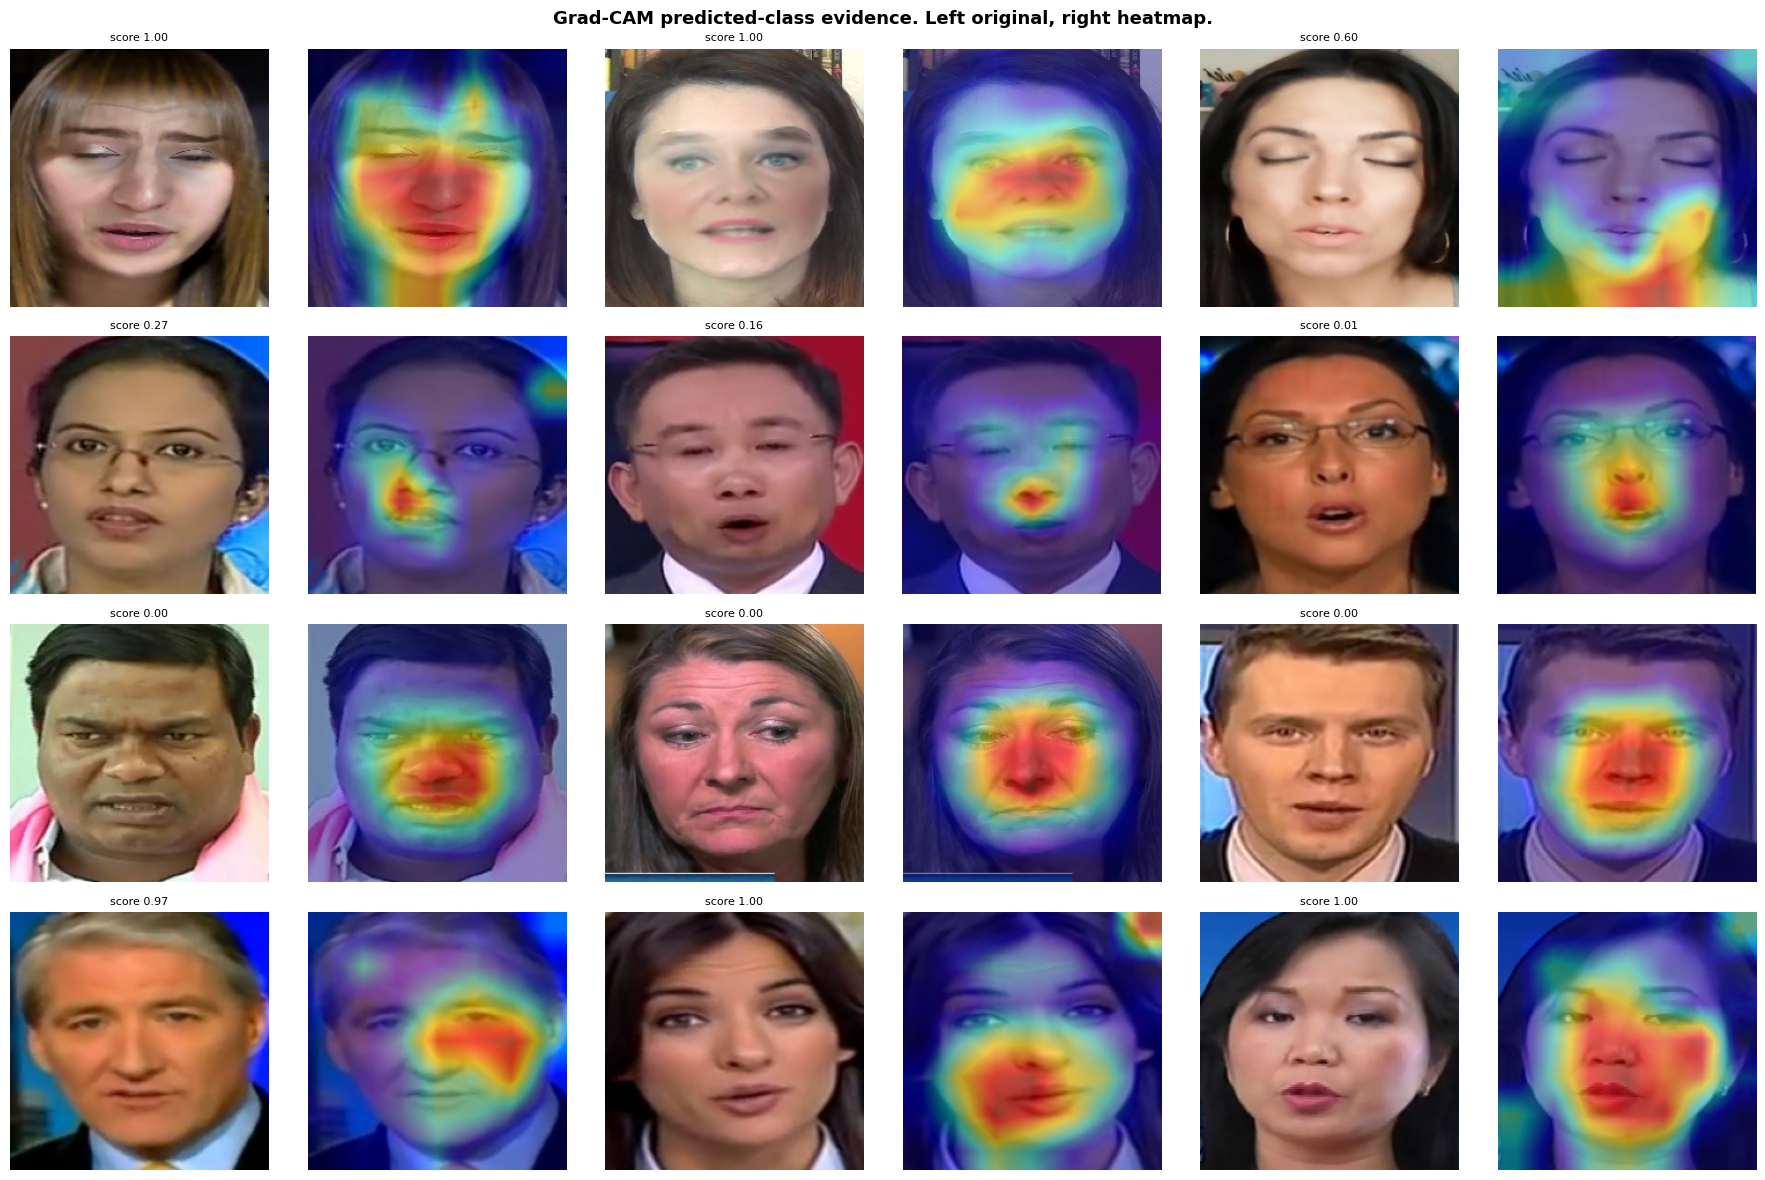

Saved gradcam_grid.png


In [12]:
# CELL 22 - Grad-CAM grid figure

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
fig.suptitle("Grad-CAM predicted-class evidence. Left original, right heatmap.",
             fontsize=13, fontweight='bold')
groups = [
    (df_gc[(df_gc.true_label == 1) & (df_gc.correct)],       "Fake, detected"),
    (df_gc[(df_gc.true_label == 1) & (~df_gc.correct)],      "Fake, missed"),
    (df_gc[(df_gc.true_label == 0) & (df_gc.correct)],       "Real, passed"),
    (df_gc[(df_gc.true_label == 0) & (~df_gc.correct)],      "Real, false alarm"),
]
for r, (subset, title) in enumerate(groups):
    axes[r, 0].set_ylabel(title, fontsize=9)
    for k, (_, row) in enumerate(subset.head(3).iterrows()):
        lab  = "fake" if row.true_label == 1 else "real"
        pstr = "fake" if row.pred_label == 1 else "real"
        fname = (f"{int(row.idx):03d}_true{lab}_pred{pstr}_"
                 f"{'ok' if row.correct else 'wrong'}.jpg")
        fpath = os.path.join(GRADCAM_DIR, lab, fname)
        if not os.path.exists(fpath):
            continue
        comp = cv2.cvtColor(cv2.imread(fpath), cv2.COLOR_BGR2RGB)
        for ci, part in enumerate([comp[:, :224, :], comp[:, 224:, :]]):
            ax = axes[r, k * 2 + ci]
            ax.imshow(part)
            if ci == 0:
                ax.set_title(f"score {row.prob:.2f}", fontsize=8)
            ax.axis("off")
for r in range(4):
    for c in range(6):
        if not axes[r, c].images:
            axes[r, c].axis("off")
plt.tight_layout()
plt.savefig(f"{GRADCAM_DIR}/gradcam_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved gradcam_grid.png")

## 7.2 MC Dropout

In [19]:
# CELL 23 - MC Dropout uncertainty, T = 50 stochastic passes

# Variance and standard deviation measure dispersion across stochastic forward passes. 
# note to self: They are not calibrated confidence probabilities

MC_SEED   = 456
MC_PASSES = 50

random.seed(MC_SEED)
np.random.seed(MC_SEED)
torch.manual_seed(MC_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MC_SEED)

def mc_dropout_predict(
    model,
    img_tensor,
    img_raw_tensor,
    n_passes=50,):
    """
    Keeps the model in evaluation mode, including BatchNorm layers,while activating only Dropout layers.
    """
    def enable_dropout(module):
        if isinstance(module, nn.Dropout):
            module.train()

    model.eval()
    model.apply(enable_dropout)

    probabilities = []

    with torch.inference_mode():
        for _ in range(n_passes):
            logits, _ = model(img_tensor, img_raw_tensor)
            probability = torch.sigmoid(logits).item()
            probabilities.append(probability)

    # Restore normal deterministic inference mode.
    model.eval()

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64,)

    mean_probability = float(probabilities.mean())
    predicted_label = (1 if mean_probability >= 0.5 else 0)

    return {
        "mean_prob" : mean_probability,
        "variance"  : float(probabilities.var()),
        "std"       : float(probabilities.std()),
        "pred_label": int(predicted_label),
        "prediction":"fake" if predicted_label == 1 else "real",
    }

mc_records = []
dual_model.eval()

for _, row in tqdm(
    df_gc.iterrows(),
    total=len(df_gc),
    desc="MC Dropout",):
    image_path = row["path"]
    true_label = int(row["true_label"])

    bgr = cv2.imread(image_path)

    if bgr is None:
        raise RuntimeError(f"Could not read crop: {image_path}")

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    pil = PILImage.fromarray(rgb)

    normalized_tensor = (norm_transform(pil).unsqueeze(0).to(device))

    raw_tensor = (raw_transform(pil).unsqueeze(0).to(device))

    result = mc_dropout_predict(model=dual_model,img_tensor=normalized_tensor,
        img_raw_tensor=raw_tensor,n_passes=MC_PASSES,)

    mc_correct = (result["pred_label"] == true_label)

    mc_records.append({
        "video_id"   : row["video_id"],
        "path"       : image_path,
        "category"   : row["category"],
        "true_label" : true_label,
        "correct"    : bool(mc_correct),
        **result,
    })

df_mc = pd.DataFrame(mc_records)

mc_results_path = f"{MC_DIR}/mc_results.csv"
df_mc.to_csv(mc_results_path, index=False)

correct_rows = df_mc[df_mc["correct"]]
wrong_rows = df_mc[~df_mc["correct"]]

print(f"\nMC Dropout complete on {len(df_mc)} crops")
print(f"  Correct predictions : {len(correct_rows)}")
print(f"  Wrong predictions : {len(wrong_rows)}")
print(f"  Mean predictive variance : {df_mc['variance'].mean():.6f}")
print(f"  Mean predictive std : {df_mc['std'].mean():.6f}")

if len(correct_rows) > 0:
    print(f"Mean variance,correct:{correct_rows['variance'].mean():.6f}")

if len(wrong_rows) > 0:
    print(f"Mean variance, wrong : {wrong_rows['variance'].mean():.6f}")
else:
    print("  Mean variance, wrong: N/A (no wrong predictions)")

print(f"\nSaved MC Dropout results to {mc_results_path}")
print("\nThese dispersion values are uncertainty indicators,")
print("not calibrated confidence probabilities.")

MC Dropout:   0%|          | 0/100 [00:00<?, ?it/s]


MC Dropout complete on 100 crops
  Correct predictions : 88
  Wrong predictions : 12
  Mean predictive variance : 0.000034
  Mean predictive std : 0.002868
Mean variance,correct:0.000022
Mean variance, wrong : 0.000123

Saved MC Dropout results to /kaggle/working/mc_dropout/mc_results.csv

These dispersion values are uncertainty indicators,
not calibrated confidence probabilities.


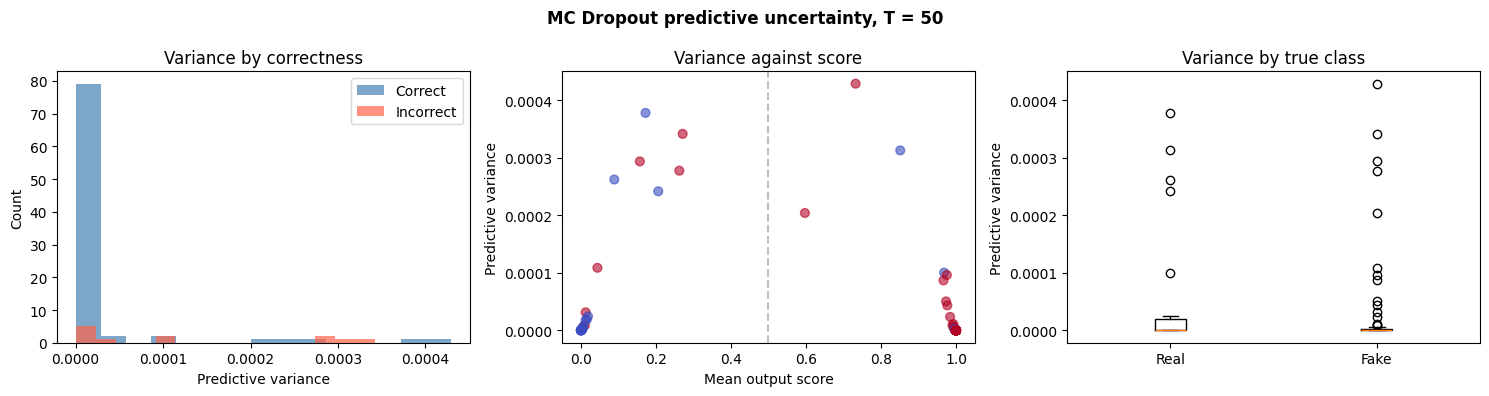

Saved mc_uncertainty.png


In [13]:
# CELL 24 - MC Dropout figures

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("MC Dropout predictive uncertainty, T = 50", fontsize=12, fontweight='bold')
axes[0].hist(df_mc[df_mc.correct]['variance'],  bins=15, alpha=0.7,
             label='Correct', color='steelblue')
axes[0].hist(df_mc[~df_mc.correct]['variance'], bins=15, alpha=0.7,
             label='Incorrect', color='tomato')
axes[0].set_xlabel('Predictive variance'); axes[0].set_ylabel('Count')
axes[0].set_title('Variance by correctness'); axes[0].legend()

axes[1].scatter(df_mc['mean_prob'], df_mc['variance'],
                c=df_mc['true_label'], cmap='coolwarm', alpha=0.6, s=40)
axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Mean output score'); axes[1].set_ylabel('Predictive variance')
axes[1].set_title('Variance against score')

axes[2].boxplot([df_mc[df_mc.true_label == 0]['variance'],
                 df_mc[df_mc.true_label == 1]['variance']],
                labels=['Real', 'Fake'])
axes[2].set_ylabel('Predictive variance'); axes[2].set_title('Variance by true class')
plt.tight_layout()
plt.savefig(f"{MC_DIR}/mc_uncertainty.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved mc_uncertainty.png")

## 7.3 Scope of the uncertainty analysis

The 100-crop experiment supports only an exploratory comparison of predictive
dispersion between correct and incorrect sampled predictions. It is not a
complete video-level validation/test uncertainty study. MC Dropout is therefore
recorded where available but is not used to accept, reject or refer cases in the
notebook or dashboard.

In [6]:
# MC DROPOUT STATUS - documentation only, no new inference

print("MC DROPOUT STATUS")
print("MC Dropout was evaluated on 100 single crops, one crop from each")
print("of the 100 videos selected for the Grad-CAM study. It was not a")
print("complete video-level validation/test evaluation. MC Dropout therefore")
print("remains an exploratory diagnostic and does not control Experiment 9,")
print("the evidence-record decision, or the dashboard manual-review rule.")

MC DROPOUT STATUS
MC Dropout was evaluated on 100 single crops, one crop from each
of the 100 videos selected for the Grad-CAM study. It was not a
complete video-level validation/test evaluation. MC Dropout therefore
remains an exploratory diagnostic and does not control Experiment 9,
the evidence-record decision, or the dashboard manual-review rule.


# 8. Decision-support evidence layer

This section translates existing model signals into auditable records for the
software demonstration. It does not alter model weights or invent new
probabilities. Each output remains traceable to a measured score, crop count,
gate value or saved explanation artifact.

The research triage policy has three states: `automatic_decision`,
`inconclusive_manual_review` and `unable_to_assess`. For the interface, an
automatic decision is additionally displayed as `likely_manipulated` or
`likely_authentic`. Keeping the triage status and display outcome separate
prevents the class label from being mistaken for a fourth referral state.

Fresh dashboard uploads should call the same reusable inference and record-
building functions in application code; the deployed service does not execute
this notebook.

## 8.1 Consolidated video evidence table

Saved FF++ predictions are joined by `video_id` and checked for complete,
one-to-one coverage. The resulting table is the common source for the narrative
and export record; it prevents positional joins and keeps every local
counterfactual attached to the correct video.

In [15]:
# EVIDENCE LAYER 1 - Consolidated video-level evidence table
# Combines already-computed FF++ test signals using video_id.

spatial_path = f"{PRED_DIR}/spatial_test_final.csv"
dual_frames_path = f"{PRED_DIR}/dual_test_final_frames.csv"

for required_path in [spatial_path, dual_frames_path]:
    if not os.path.exists(required_path):
        raise FileNotFoundError(f"Required file missing: {required_path}")

spatial_df = pd.read_csv(spatial_path)
dual_frames_df = pd.read_csv(dual_frames_path)

spatial_required = {
    "video_id", "true_label", "video_score", "pred_label", "n_frames",
}
frame_required = {
    "video_id", "true_label", "frame_score", "gate_alpha",
}

if spatial_required - set(spatial_df.columns):
    raise ValueError(
        f"Spatial predictions are missing: "
        f"{sorted(spatial_required-set(spatial_df.columns))}"
    )

if frame_required - set(dual_frames_df.columns):
    raise ValueError(
        f"Dual frame predictions are missing: "
        f"{sorted(frame_required-set(dual_frames_df.columns))}"
    )

spatial_df["video_id"] = spatial_df["video_id"].astype(str)
dual_frames_df["video_id"] = dual_frames_df["video_id"].astype(str)

if spatial_df["video_id"].duplicated().any():
    raise RuntimeError("Duplicate video_id found in spatial predictions.")

expected_ids = set(counterfactual_df["video_id"].astype(str))
spatial_ids = set(spatial_df["video_id"])
frame_ids = set(dual_frames_df["video_id"])

if spatial_ids != expected_ids:
    raise RuntimeError("Spatial and counterfactual predictions contain different videos.")

if frame_ids != expected_ids:
    raise RuntimeError("Frame and counterfactual predictions contain different videos.")

frame_stats = dual_frames_df.groupby("video_id").agg(
    frame_count_check=("frame_score", "size"),
    frame_score_mean=("frame_score", "mean"),
    frame_score_std=("frame_score", "std"),
    frame_score_min=("frame_score", "min"),
    frame_score_max=("frame_score", "max"),
    mean_gate_alpha=("gate_alpha", "mean"),
).reset_index()

evidence_df = counterfactual_df[[
    "video_id", "true_label", "category", "n_frames",
    "video_score", "pred_label",
    "video_score_frequency_disabled", "pred_label_frequency_disabled",
    "frequency_score_effect", "abs_frequency_score_effect",
    "frequency_effect_direction", "prediction_flip",
]].rename(columns={
    "video_score": "dual_score",
    "pred_label": "dual_pred_label",
})

spatial_subset = spatial_df[[
    "video_id", "true_label", "video_score", "pred_label", "n_frames",
]].rename(columns={
    "true_label": "spatial_true_label_check",
    "video_score": "spatial_score",
    "pred_label": "spatial_pred_label",
    "n_frames": "spatial_n_frames",
})

evidence_df = evidence_df.merge(
    spatial_subset,
    on="video_id",
    how="inner",
    validate="one_to_one",
)
evidence_df = evidence_df.merge(
    frame_stats,
    on="video_id",
    how="inner",
    validate="one_to_one",
)

if len(evidence_df) != EXPECTED_TEST_VIDEOS:
    raise RuntimeError(
        f"Evidence table has {len(evidence_df)} rows; "
        f"expected {EXPECTED_TEST_VIDEOS}."
    )

if evidence_df["video_id"].duplicated().any():
    raise RuntimeError("Duplicate video_id found in the evidence table.")

if not (
    evidence_df["true_label"].astype(int)
    == evidence_df["spatial_true_label_check"].astype(int)
).all():
    raise RuntimeError("Spatial and dual true labels differ.")

if not (
    evidence_df["n_frames"].astype(int)
    == evidence_df["spatial_n_frames"].astype(int)
).all():
    raise RuntimeError("Spatial and dual prediction files used different frame counts.")

if not (
    evidence_df["n_frames"].astype(int)
    == evidence_df["frame_count_check"].astype(int)
).all():
    raise RuntimeError("Video and frame prediction files have inconsistent frame counts.")

if evidence_df[[
    "frame_score_mean", "frame_score_min", "frame_score_max", "mean_gate_alpha",
]].isna().any().any():
    raise RuntimeError("Missing frame statistics or gate alpha in the evidence table.")

evidence_df = evidence_df.drop(columns=[
    "spatial_true_label_check", "frame_count_check",
])

evidence_df["model_agreement"] = (
    evidence_df["dual_pred_label"].astype(int)
    == evidence_df["spatial_pred_label"].astype(int)
)
evidence_df["score_disagreement"] = (
    evidence_df["dual_score"] - evidence_df["spatial_score"]
).abs()
evidence_df["dual_margin"] = (evidence_df["dual_score"] - 0.5).abs()

evidence_path = f"{ADDITIONAL_EXP_DIR}/ff_test_evidence_table.csv"
_atomic_dataframe_save(evidence_df, evidence_path)

print("VIDEO EVIDENCE TABLE")
print(f"  Videos                  : {len(evidence_df)}")
print(f"  Model agreement rate    : {evidence_df['model_agreement'].mean():.3f}")
print(f"  Mean score disagreement : {evidence_df['score_disagreement'].mean():.4f}")
print(f"  Mean dual margin        : {evidence_df['dual_margin'].mean():.4f}")
print(f"\nSaved evidence table to {evidence_path}")

VIDEO EVIDENCE TABLE
  Videos                  : 738
  Model agreement rate    : 0.957
  Mean score disagreement : 0.0495
  Mean dual margin        : 0.4400

Saved evidence table to /kaggle/working/experiments/additional_experiments/ff_test_evidence_table.csv


## 8.2 Input adequacy

The five-crop minimum matches dataset inclusion and provides an explicit
“unable to assess” path. Blur and brightness checks are descriptive warnings
only. Their hand-set boundaries were not validated as operating thresholds and
therefore do not control the model or triage decision.

Checks usable-face coverage and supplies descriptive blur/brightness warnings for new uploads. The five-crop minimum matches dataset inclusion, but it does not guarantee reliability. Blur and brightness boundaries are explicitly treated as display-only heuristics and do not control the triage decision.


In [16]:
# EVIDENCE LAYER 2 - Input-adequacy assessment for uploaded videos

MIN_USABLE_FRAMES = CFG["min_crops"]
BLUR_WARNING_THRESHOLD = 50.0
DARK_WARNING_THRESHOLD = 40.0
BRIGHT_WARNING_THRESHOLD = 220.0


def assess_input_adequacy(requested_frames, usable_crop_paths):
    """Describes whether enough readable face crops exist for inference."""
    requested_frames = int(requested_frames)

    if requested_frames < 1:
        raise ValueError("requested_frames must be at least 1.")

    crop_paths = sorted(str(path) for path in usable_crop_paths)

    # One face crop is retained per sampled frame. If a caller supplies more
    # paths than requested, apply the same uniform cap used by inference.
    if len(crop_paths) > requested_frames:
        selected_indices = np.linspace(
            0,
            len(crop_paths) - 1,
            requested_frames,
            dtype=int,
        )
        crop_paths = [crop_paths[index] for index in selected_indices]

    blur_scores = []
    brightness_values = []
    unreadable_paths = []

    for path in crop_paths:
        image = cv2.imread(path)

        if image is None:
            unreadable_paths.append(path)
            continue

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        blur_scores.append(
            float(cv2.Laplacian(gray, cv2.CV_64F).var())
        )
        brightness_values.append(float(gray.mean()))

    n_usable = len(blur_scores)
    usable_fraction = n_usable / requested_frames
    sufficient_evidence = n_usable >= MIN_USABLE_FRAMES
    warnings_list = []

    if unreadable_paths:
        warnings_list.append(
            f"{len(unreadable_paths)} selected face crops could not be read."
        )

    if not sufficient_evidence:
        warnings_list.append(
            f"Fewer than {MIN_USABLE_FRAMES} usable face crops were found; "
            "insufficient facial evidence for an authenticity assessment."
        )

    mean_blur = float(np.mean(blur_scores)) if blur_scores else None
    mean_brightness = (
        float(np.mean(brightness_values)) if brightness_values else None
    )

    if mean_blur is not None and mean_blur < BLUR_WARNING_THRESHOLD:
        warnings_list.append(
            "Low sharpness was detected by a display-only heuristic."
        )

    if mean_brightness is not None and (
        mean_brightness < DARK_WARNING_THRESHOLD
        or mean_brightness > BRIGHT_WARNING_THRESHOLD
    ):
        warnings_list.append(
            "Extreme brightness was detected by a display-only heuristic."
        )

    return {
        "requested_frames": requested_frames,
        "usable_frames": int(n_usable),
        "usable_fraction": float(usable_fraction),
        "sufficient_evidence": bool(sufficient_evidence),
        "mean_blur_variance": mean_blur,
        "mean_brightness": mean_brightness,
        "unreadable_crops": int(len(unreadable_paths)),
        "quality_threshold_status": (
            "blur and brightness boundaries are descriptive heuristics; "
            "they do not control triage"
        ),
        "warnings": warnings_list,
    }


# Demonstration on one FF++ test video.
demo_row = counterfactual_df.iloc[0]
demo_video_id = str(demo_row["video_id"])
demo_label_str = "fake" if int(demo_row["true_label"]) == 1 else "real"
demo_folder = os.path.join(FF_PROCESSED, "test", demo_label_str)
demo_crops = sorted([
    os.path.join(demo_folder, filename)
    for filename in os.listdir(demo_folder)
    if filename.startswith(demo_video_id + "_f")
    and filename.lower().endswith(".jpg")
])

demo_adequacy = assess_input_adequacy(
    requested_frames=TRAIN_FRAMES,
    usable_crop_paths=demo_crops,
)

print("INPUT-ADEQUACY ASSESSMENT DEMO")
for key, value in demo_adequacy.items():
    print(f"  {key:<25}: {value}")

INPUT-ADEQUACY ASSESSMENT DEMO
  requested_frames         : 20
  usable_frames            : 20
  usable_fraction          : 1.0
  sufficient_evidence      : True
  mean_blur_variance       : 52.67792153445843
  mean_brightness          : 88.54808872767858
  unreadable_crops         : 0
  quality_threshold_status : blur and brightness boundaries are descriptive heuristics; they do not control triage
  warnings                 : []


## 8.3 Deterministic narrative templates

Every sentence maps to a stored measurement. Gate alpha is described as a
multiplier relative to its midpoint, not as proof of contribution. The
frequency counterfactual reports exact direction and magnitude. Grad-CAM text
uses “influenced” rather than claiming localisation of an artefact. No language
model is used to generate forensic claims.

Every statement maps to a measured value. Gate alpha is described relative to its mathematical midpoint, while the counterfactual reports its exact direction and magnitude without inventing an unvalidated “strong/weak” boundary. Grad-CAM and MC Dropout text is only produced when that evidence exists for the video.

In [17]:
# EVIDENCE LAYER 3 - Deterministic narrative templates

def narrate_gate_alpha(mean_alpha):
    if mean_alpha is None or pd.isna(mean_alpha):
        return "Gate alpha was not available for this video."

    position = "above" if mean_alpha >= 0.5 else "below"

    return (
        f"The mean fusion-gate alpha was {mean_alpha:.2f}, {position} "
        "the gate midpoint of 0.50. Alpha is the weight assigned to "
        "the frequency residual; it is not by itself a contribution score."
    )


def narrate_frequency_counterfactual(effect):
    effect = float(effect)

    if effect > 0:
        return (
            f"Disabling the frequency residual decreased the manipulation "
            f"score by {effect:.3f}. The residual therefore increased this "
            "video's fake score."
        )

    if effect < 0:
        return (
            f"Disabling the frequency residual increased the manipulation "
            f"score by {abs(effect):.3f}. The residual therefore decreased "
            "this video's fake score."
        )

    return (
        "Disabling the frequency residual produced no score change at the "
        "reported precision."
    )


def narrate_gradcam(available):
    if not available:
        return "No Grad-CAM heatmap was generated for this video."

    return (
        "The Grad-CAM heatmap visualises sensitivity within the spatial "
        "pathway of the dual model for the predicted class. It does not "
        "localise or prove manipulation in the highlighted pixels."
    )


def narrate_mc_dropout(available):
    if not available:
        return "MC Dropout was not evaluated for this video."

    return (
        "MC Dropout was evaluated on one selected crop from this video as "
        "an exploratory diagnostic. It does not influence the final "
        "prediction or manual-review outcome."
    )


def narrate_model_agreement(agree, spatial_score, dual_score):
    if agree:
        return (
            f"The spatial score ({spatial_score:.3f}) and dual score "
            f"({dual_score:.3f}) produce the same predicted class."
        )

    return (
        f"The spatial score ({spatial_score:.3f}) and dual score "
        f"({dual_score:.3f}) produce different predicted classes. This "
        "disagreement is shown as a caution, but does not set the triage rule."
    )


def narrate_input_adequacy(adequacy):
    if not adequacy["sufficient_evidence"]:
        return (
            "Insufficient facial evidence was available. No authenticity "
            "assessment has been produced."
        )

    sentence = (
        f"{adequacy['usable_frames']} of {adequacy['requested_frames']} "
        "requested frames provided usable facial evidence."
    )

    if adequacy.get("warnings"):
        sentence += " " + " ".join(adequacy["warnings"])

    return sentence


def triage_outcome(dual_score, thresholds_by_coverage, sufficient_evidence):
    if not sufficient_evidence:
        return "unable_to_assess"

    dual_score = float(dual_score)
    margin = abs(dual_score - 0.5)
    threshold_90 = thresholds_by_coverage.get(0.90)

    if threshold_90 is None:
        raise KeyError("The locked 90% coverage threshold is missing.")

    if margin < threshold_90:
        return "inconclusive_manual_review"

    return "likely_manipulated" if dual_score >= 0.5 else "likely_authentic"


print("Narrative functions ready")
print("  Gate alpha: weight description, not contribution claim")
print("  Frequency: measured counterfactual direction and magnitude")
print("  Grad-CAM/MC Dropout: included only where actually available")

Narrative functions ready
  Gate alpha: weight description, not contribution claim
  Frequency: measured counterfactual direction and magnitude
  Grad-CAM/MC Dropout: included only where actually available


## 8.4 Reusable live counterfactual

For a fresh video, the application can score the same selected crops with the
official dual model and with its frequency residual disabled. The validation
below checks the live function against one saved batch result. It is an
application utility rather than a new experiment and can be skipped when only
reviewing the submitted results.

In [18]:
# EVIDENCE LAYER 4 - Reusable single-video frequency counterfactual
# Requires the retained dual model; a CUDA device is recommended for speed.

class DualFrequencyDisabledLive(nn.Module):
    def __init__(self, trained_dual_model):
        super().__init__()
        self.trained_dual_model = trained_dual_model

    def forward(self, normalized_images, raw_images):
        spatial_features = self.trained_dual_model.spatial.get_features(
            normalized_images
        )
        logits = self.trained_dual_model.classifier(
            spatial_features
        ).squeeze(1)
        return logits


def compute_video_frequency_counterfactual(
    dual_model_instance,
    image_paths,
    device,
    max_frames=20,
):
    """Runs normal and frequency-disabled inference on the same face crops."""
    if max_frames < 1:
        raise ValueError("max_frames must be at least 1.")

    image_paths = sorted(str(path) for path in image_paths)

    if len(image_paths) > max_frames:
        selected_indices = np.linspace(
            0,
            len(image_paths) - 1,
            max_frames,
            dtype=int,
        )
        image_paths = [image_paths[index] for index in selected_indices]

    normalized_images = []
    raw_images = []
    valid_paths = []

    for path in image_paths:
        bgr = cv2.imread(path)
        if bgr is None:
            continue

        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        pil = PILImage.fromarray(rgb)

        normalized_images.append(norm_transform(pil))
        raw_images.append(raw_transform(pil))
        valid_paths.append(path)

    if not normalized_images:
        return None

    normalized_batch = torch.stack(normalized_images).to(device)
    raw_batch = torch.stack(raw_images).to(device)

    disabled_model = DualFrequencyDisabledLive(dual_model_instance).to(device)
    disabled_model.eval()
    dual_model_instance.eval()

    with torch.inference_mode():
        normal_logits, gate_alphas = dual_model_instance(
            normalized_batch,
            raw_batch,
        )
        disabled_logits = disabled_model(
            normalized_batch,
            raw_batch,
        )

    normal_scores = torch.sigmoid(normal_logits).detach().float().cpu().numpy()
    disabled_scores = torch.sigmoid(disabled_logits).detach().float().cpu().numpy()

    normal_video_score = float(normal_scores.mean())
    disabled_video_score = float(disabled_scores.mean())

    return {
        "n_frames_used": int(len(valid_paths)),
        "dual_score": normal_video_score,
        "frequency_disabled_score": disabled_video_score,
        "frequency_score_effect": normal_video_score - disabled_video_score,
        "mean_gate_alpha": float(gate_alphas.detach().float().mean().cpu()),
        "frame_scores": normal_scores.tolist(),
        "frequency_disabled_frame_scores": disabled_scores.tolist(),
    }


# Validate one test video against the two saved batch prediction files.
validation_sample = counterfactual_df.iloc[0]
sample_video_id = str(validation_sample["video_id"])
sample_label_str = (
    "fake" if int(validation_sample["true_label"]) == 1 else "real"
)
sample_folder = os.path.join(
    FF_PROCESSED,
    "test",
    sample_label_str,
)
sample_crops = sorted([
    os.path.join(sample_folder, filename)
    for filename in os.listdir(sample_folder)
    if filename.startswith(sample_video_id + "_f")
    and filename.lower().endswith(".jpg")
])

live_result = compute_video_frequency_counterfactual(
    dual_model,
    sample_crops,
    device,
    max_frames=20,
)

if live_result is None:
    raise RuntimeError("The live validation video had no readable face crops.")

print("LIVE COUNTERFACTUAL VALIDATION")
print(f"  Video: {sample_video_id}")

checks = {
    "dual score": (
        live_result["dual_score"],
        float(validation_sample["video_score"]),
    ),
    "frequency-disabled score": (
        live_result["frequency_disabled_score"],
        float(validation_sample["video_score_frequency_disabled"]),
    ),
    "frequency score effect": (
        live_result["frequency_score_effect"],
        float(validation_sample["frequency_score_effect"]),
    ),
}

for name, (live_value, saved_value) in checks.items():
    difference = abs(live_value - saved_value)
    print(
        f"  {name:<26}: live={live_value:.6f}, "
        f"saved={saved_value:.6f}, difference={difference:.8f}"
    )

    if difference > 1e-4:
        raise RuntimeError(
            f"Live {name} does not match the saved batch result."
        )

print("\nLive counterfactual inference matches the saved prediction pipeline.")

LIVE COUNTERFACTUAL VALIDATION
  Video: Deepfakes_004_982
  dual score                : live=0.935472, saved=0.935472, difference=0.00000001
  frequency-disabled score  : live=0.023094, saved=0.023094, difference=0.00000000
  frequency score effect    : live=0.912378, saved=0.912378, difference=0.00000001

Live counterfactual inference matches the saved prediction pipeline.


## 8.5 Exportable evidence records

The JSON schema records the checkpoint hash, measured scores, crop coverage,
locked triage threshold, optional explanation availability and cautious
narrative. Ground truth is included only for offline academic evaluation. A
dashboard record for a new upload should omit ground truth and include the
uploaded-file hash.

In [19]:
# EVIDENCE LAYER 5 - Exportable offline evidence records

with open(f"{EXP_DIR}/step4_final_decision_video_auc_v2.json") as file:
    final_decision_record = json.load(file)

official_checkpoint = final_decision_record["final_checkpoint"]

if not os.path.exists(official_checkpoint):
    raise FileNotFoundError(
        f"Official checkpoint missing: {official_checkpoint}"
    )

official_checkpoint_sha256 = experiment_file_sha256(official_checkpoint)

with open(f"{ADDITIONAL_EXP_DIR}/triage_thresholds.json") as file:
    triage_threshold_record = json.load(file)

thresholds_by_coverage = {
    float(key): float(value)
    for key, value in triage_threshold_record["margin_thresholds"].items()
}

gradcam_path = f"{GRADCAM_DIR}/gradcam_results.csv"
mc_path = f"{MC_DIR}/mc_results.csv"

gradcam_video_ids = set()
mc_by_video = {}

if os.path.exists(gradcam_path):
    gradcam_records = pd.read_csv(gradcam_path)
    gradcam_video_ids = set(gradcam_records["video_id"].astype(str))

if os.path.exists(mc_path):
    mc_records = pd.read_csv(mc_path)
    mc_records["video_id"] = mc_records["video_id"].astype(str)
    mc_by_video = {
        row["video_id"]: {
            "variance": float(row["variance"]),
            "std": float(row["std"]),
            "scope": "one selected crop; exploratory only",
        }
        for _, row in mc_records.iterrows()
    }


def build_offline_evidence_record(
    row,
    thresholds_by_coverage,
    checkpoint_name,
    checkpoint_sha256,
    model_version="video_auc_v2",
):
    video_id = str(row["video_id"])
    usable_frames = int(row["n_frames"])
    requested_frames = int(TRAIN_FRAMES)
    sufficient_evidence = usable_frames >= MIN_USABLE_FRAMES

    adequacy = {
        "requested_frames": requested_frames,
        "usable_frames": usable_frames,
        "usable_fraction": float(usable_frames / requested_frames),
        "sufficient_evidence": bool(sufficient_evidence),
        "quality_metrics_computed": False,
        "warnings": (
            [] if sufficient_evidence else
            [f"Fewer than {MIN_USABLE_FRAMES} usable face crops were found."]
        ),
    }

    outcome = triage_outcome(
        row["dual_score"],
        thresholds_by_coverage,
        sufficient_evidence,
    )
    triage_status = (
        "automatic_decision"
        if outcome in ["likely_manipulated", "likely_authentic"]
        else outcome
    )

    gradcam_available = video_id in gradcam_video_ids
    mc_result = mc_by_video.get(video_id)
    category = None if pd.isna(row["category"]) else str(row["category"])

    return {
        "record_type": "offline_ff_test_evidence",
        "generated_utc": time.strftime(
            "%Y-%m-%dT%H:%M:%SZ",
            time.gmtime(),
        ),
        "video_id": video_id,
        "ground_truth": {
            "true_label": int(row["true_label"]),
            "category": category,
        },
        "model": {
            "version": model_version,
            "checkpoint_file": os.path.basename(checkpoint_name),
            "checkpoint_sha256": checkpoint_sha256,
        },
        "decision": {
            "triage_status": triage_status,
            "display_outcome": outcome,
            "outcome": outcome,  # retained for dashboard compatibility
            "predicted_label": (
                int(row["dual_pred_label"])
                if outcome not in ["unable_to_assess", "inconclusive_manual_review"]
                else None
            ),
            "dual_margin": float(row["dual_margin"]),
            "locked_90_coverage_margin_threshold": float(
                thresholds_by_coverage[0.90]
            ),
        },
        "scores": {
            "spatial_score": float(row["spatial_score"]),
            "dual_score": float(row["dual_score"]),
            "frequency_disabled_score": float(
                row["video_score_frequency_disabled"]
            ),
            "frequency_score_effect": float(row["frequency_score_effect"]),
        },
        "model_agreement": bool(row["model_agreement"]),
        "frame_evidence": {
            "n_frames": usable_frames,
            "frame_score_mean": float(row["frame_score_mean"]),
            "frame_score_std": (
                float(row["frame_score_std"])
                if not pd.isna(row["frame_score_std"]) else None
            ),
            "frame_score_min": float(row["frame_score_min"]),
            "frame_score_max": float(row["frame_score_max"]),
        },
        "gate_alpha": float(row["mean_gate_alpha"]),
        "input_adequacy": adequacy,
        "explainability": {
            "gradcam_available": bool(gradcam_available),
            "mc_dropout_available": bool(mc_result is not None),
            "mc_dropout": mc_result,
        },
        "narrative": {
            "gate_alpha": narrate_gate_alpha(row["mean_gate_alpha"]),
            "frequency_counterfactual": narrate_frequency_counterfactual(
                row["frequency_score_effect"]
            ),
            "gradcam": narrate_gradcam(gradcam_available),
            "mc_dropout": narrate_mc_dropout(mc_result is not None),
            "model_agreement": narrate_model_agreement(
                row["model_agreement"],
                row["spatial_score"],
                row["dual_score"],
            ),
            "input_adequacy": narrate_input_adequacy(adequacy),
        },
        "disclaimer": (
            "This is a research-prototype output, not proof of manipulation "
            "and not a calibrated probability. Human review is required "
            "before any consequential use."
        ),
    }


demo_evidence_row = evidence_df.iloc[0]
demo_record = build_offline_evidence_record(
    demo_evidence_row,
    thresholds_by_coverage,
    official_checkpoint,
    official_checkpoint_sha256,
)

demo_record_path = (
    f"{ADDITIONAL_EXP_DIR}/example_evidence_record_"
    f"{demo_evidence_row['video_id']}.json"
)
experiment_save_json(demo_record, demo_record_path)

print("EXAMPLE OFFLINE EVIDENCE RECORD")
print(json.dumps(demo_record, indent=2))
print(f"\nSaved example to {demo_record_path}")

all_records = [
    build_offline_evidence_record(
        row,
        thresholds_by_coverage,
        official_checkpoint,
        official_checkpoint_sha256,
    )
    for _, row in evidence_df.iterrows()
]

all_records_path = (
    f"{ADDITIONAL_EXP_DIR}/ff_test_evidence_records.json"
)
experiment_save_json(all_records, all_records_path)

print(f"\nSaved {len(all_records)} offline records to {all_records_path}")

EXAMPLE OFFLINE EVIDENCE RECORD
{
  "record_type": "offline_ff_test_evidence",
  "generated_utc": "2026-09-09T15:57:40Z",
  "video_id": "Deepfakes_004_982",
  "ground_truth": {
    "true_label": 1,
    "category": "Deepfakes"
  },
  "model": {
    "version": "video_auc_v2",
    "checkpoint_file": "dual_best.pth",
    "checkpoint_sha256": "2499bc2020eea1f7a7f0ca448312d64c4771f81f6e834944e682c4498df8dd42"
  },
  "decision": {
    "triage_status": "automatic_decision",
    "display_outcome": "likely_manipulated",
    "outcome": "likely_manipulated",
    "predicted_label": 1,
    "dual_margin": 0.43547248244285597,
    "locked_90_coverage_margin_threshold": 0.2903130567749031
  },
  "scores": {
    "spatial_score": 0.6973806648515165,
    "dual_score": 0.935472482442856,
    "frequency_disabled_score": 0.0230944835580885,
    "frequency_score_effect": 0.9123779988847674
  },
  "model_agreement": true,
  "frame_evidence": {
    "n_frames": 20,
    "frame_score_mean": 0.9354724824428559,
   

# 9. Conclusions, limitations and reproducibility record

The study supports a narrow conclusion: on this source-disjoint FF++ protocol,
the locked spatial–frequency model provides a small, statistically supported
video-AUC improvement over the spatial baseline. The frequency branch is most
useful in fusion rather than alone. The work does not support a claim of
universal deepfake detection: external AUC is lower, noise causes a substantial
drop, some external videos lack usable faces, demographic fairness has not been
established and temporal consistency is not modelled.

The cells below consolidate the saved metrics, state ethical and operational
limits, generate the model card and audit the output directory. They read
artifacts rather than re-estimating results from memory.

In [20]:
# FINAL RESULTS SUMMARY - consolidated record from saved experiment artifacts

summary_paths = {
    "ff_test": f"{CKPT_DIR}/ff_test_results_final.json",
    "celeb_full": f"{CKPT_DIR}/celeb_results_final.json",
    "step4": f"{EXP_DIR}/step4_final_decision_video_auc_v2.json",
    "bootstrap": f"{ADDITIONAL_EXP_DIR}/bootstrap_cluster_results.json",
    "calibration": f"{ADDITIONAL_EXP_DIR}/calibration_results.json",
    "frame_sensitivity": f"{ADDITIONAL_EXP_DIR}/frame_count_sensitivity.json",
    "strict_ablation": f"{ADDITIONAL_EXP_DIR}/frequency_residual_ablation.json",
    "frequency_only": (
        f"{ADDITIONAL_EXP_DIR}/frequency_only_v1/"
        "frequency_only_test_results.json"
    ),
    "robustness": f"{ADDITIONAL_EXP_DIR}/robustness_results.json",
    "timing": f"{ADDITIONAL_EXP_DIR}/controlled_inference_timing.json",
    "celeb_official": f"{ADDITIONAL_EXP_DIR}/celeb_official_test_results.json",
    "gradcam": f"{GRADCAM_DIR}/gradcam_results.csv",
    "mc_dropout": f"{MC_DIR}/mc_results.csv",
    "frequency_counterfactual": (
        f"{ADDITIONAL_EXP_DIR}/frequency_counterfactual_summary.json"
    ),
    "frequency_by_manipulation": (
        f"{ADDITIONAL_EXP_DIR}/frequency_effect_by_manipulation.json"
    ),
    "selective_triage": (
        f"{ADDITIONAL_EXP_DIR}/selective_triage_results.json"
    ),
    "fixed_threshold_audit": (
        f"{ADDITIONAL_EXP_DIR}/fixed_threshold_error_audit.json"
    ),
}

missing_summary_files = [
    path for path in summary_paths.values()
    if not os.path.exists(path)
]

if missing_summary_files:
    raise FileNotFoundError(
        "Complete the remaining experiment or explainability cells first:\n" +
        "\n".join(missing_summary_files)
    )

with open(summary_paths["ff_test"]) as f:
    summary_ff = json.load(f)
with open(summary_paths["celeb_full"]) as f:
    summary_celeb_full = json.load(f)
with open(summary_paths["step4"]) as f:
    summary_step4 = json.load(f)
with open(summary_paths["bootstrap"]) as f:
    summary_bootstrap = json.load(f)
with open(summary_paths["calibration"]) as f:
    summary_calibration = json.load(f)
with open(summary_paths["frame_sensitivity"]) as f:
    summary_frames = json.load(f)
with open(summary_paths["strict_ablation"]) as f:
    summary_strict = json.load(f)
with open(summary_paths["frequency_only"]) as f:
    summary_frequency = json.load(f)
with open(summary_paths["robustness"]) as f:
    summary_robustness = json.load(f)
with open(summary_paths["timing"]) as f:
    summary_timing = json.load(f)
with open(summary_paths["celeb_official"]) as f:
    summary_celeb_official = json.load(f)
with open(summary_paths["frequency_counterfactual"]) as f:
    summary_counterfactual = json.load(f)

with open(summary_paths["frequency_by_manipulation"]) as f:
    summary_frequency_interaction = json.load(f)

with open(summary_paths["selective_triage"]) as f:
    summary_triage = json.load(f)

with open(summary_paths["fixed_threshold_audit"]) as f:
    summary_fixed_threshold = json.load(f)

summary_gradcam = pd.read_csv(summary_paths["gradcam"])
summary_mc = pd.read_csv(summary_paths["mc_dropout"])

ff_spatial_auc = float(summary_ff["spatial"]["auc"])
ff_dual_auc = float(summary_ff["dual"]["auc"])
celeb_full_auc = float(summary_celeb_full["dual"]["auc"])
celeb_official_auc = float(summary_celeb_official["dual"]["auc"])
frequency_only_auc = float(summary_frequency["test_metrics"]["auc"])

print("DEEPFAKE DETECTION - FINAL RESULTS SUMMARY")
print("Group 9, University of the West of England\n")

print("Official model decision")
print(f"  Decision   : {summary_step4['decision']}")
print(f"  Checkpoint : {summary_step4['final_checkpoint']}")
print("  The FF++ test split was not used for model or checkpoint selection.\n")

print("FF++ test performance - 20-frame video protocol")
print(f"  Spatial video AUC : {ff_spatial_auc:.4f}")
print(f"  Dual video AUC    : {ff_dual_auc:.4f}")
print(f"  Difference        : {ff_dual_auc - ff_spatial_auc:+.4f}")
print(f"  Dual accuracy     : {summary_ff['dual']['acc']:.4f}")
print(f"  Dual F1           : {summary_ff['dual']['f1']:.4f}")
print(
    f"  Cluster-bootstrap difference 95% CI : "
    f"{summary_bootstrap['auc_difference_ci95']}\n"
)

print("Frequency evidence")
print(f"  Strict residual-disabled AUC : "
      f"{summary_strict['frequency_disabled_metrics']['auc']:.4f}")
print(f"  Official dual AUC            : "
      f"{summary_strict['official_dual_metrics']['auc']:.4f}")
print(f"  Frequency-only baseline AUC  : {frequency_only_auc:.4f}")
print("  The frequency-only result is a separately trained baseline, not an ablation.\n")

print("Calibration - FF++ test")
print(f"  Temperature    : {summary_calibration['temperature']:.4f}")
print(f"  Raw AUC / NLL  : "
      f"{summary_calibration['test_raw']['auc']:.4f} / "
      f"{summary_calibration['test_raw']['nll']:.4f}")
print(f"  Cal AUC / NLL  : "
      f"{summary_calibration['test_calibrated']['auc']:.4f} / "
      f"{summary_calibration['test_calibrated']['nll']:.4f}")
print(f"  Raw ECE / Brier: "
      f"{summary_calibration['test_raw']['ece']:.4f} / "
      f"{summary_calibration['test_raw']['brier']:.4f}")
print(f"  Cal ECE / Brier: "
      f"{summary_calibration['test_calibrated']['ece']:.4f} / "
      f"{summary_calibration['test_calibrated']['brier']:.4f}\n")

print("Cross-dataset evaluation")
print(f"  Celeb-DF full processed collection AUC : {celeb_full_auc:.4f}")
print(f"  Celeb-DF official test-list AUC         : {celeb_official_auc:.4f}")
print(f"  Official-list video coverage            : "
      f"{summary_celeb_official['dual_coverage']['coverage']:.2%}")
print("  Both are zero-shot evaluations; the two protocols are reported separately.\n")

print("Sensitivity and robustness")
for maximum_frames, result in summary_frames["results"].items():
    print(f"  Max {maximum_frames:>2} frames : AUC "
          f"{result['metrics']['auc']:.4f}, actual mean "
          f"{result['actual_mean_frames']:.1f}")

worst_robustness = min(
    summary_robustness["conditions"].items(),
    key=lambda item: item[1]["dual"]["metrics"]["auc"],
)
print(f"  Lowest dual robustness AUC : {worst_robustness[0]} = "
      f"{worst_robustness[1]['dual']['metrics']['auc']:.4f}\n")

print("Explainability and uncertainty")
print(f"  Grad-CAM videos       : {len(summary_gradcam)}")
print(f"  Single-crop accuracy on Grad-CAM sample: "
      f"{summary_gradcam['correct'].mean():.3f}")
print(f"  MC Dropout crops      : {len(summary_mc)}")
print(f"  Mean MC variance      : {summary_mc['variance'].mean():.6f}")
print("  MC variance is a dispersion indicator, not a calibrated probability.\n")

print("Controlled inference timing")
for row in summary_timing["results"]:
    print(
        f"  {row['model']:<16} batch {row['batch_size']:>2} : "
        f"{row['mean_batch_ms']:.3f} ms/batch, "
        f"{row['mean_per_image_ms']:.3f} ms/image"
    )

combined_summary = {
    "official_checkpoint_decision": summary_step4,
    "ff_test": summary_ff,
    "paired_cluster_bootstrap": summary_bootstrap,
    "calibration": summary_calibration,
    "frame_count_sensitivity": summary_frames,
    "strict_frequency_residual_ablation": summary_strict,
    "frequency_only_baseline": summary_frequency,
    "robustness": summary_robustness,
    "controlled_timing": summary_timing,
    "celeb_full_collection": summary_celeb_full,
    "celeb_official_test": summary_celeb_official,
    "frequency_counterfactual": summary_counterfactual,
    "exploratory_frequency_by_manipulation": (summary_frequency_interaction),
    "selective_triage": summary_triage,
    "fixed_threshold_error_audit": summary_fixed_threshold,
    "explainability": {
        "gradcam_videos": int(len(summary_gradcam)),
        "gradcam_sample_accuracy": float(summary_gradcam["correct"].mean()),
        "mc_dropout_crops": int(len(summary_mc)),
        "mean_mc_variance": float(summary_mc["variance"].mean()),
    },
}

experiment_save_json(
    combined_summary,
    f"{ADDITIONAL_EXP_DIR}/final_combined_results.json",
)

print(
    f"\nSaved combined record to "
    f"{ADDITIONAL_EXP_DIR}/final_combined_results.json"
)

DEEPFAKE DETECTION - FINAL RESULTS SUMMARY
Group 9, University of the West of England

Official model decision
  Decision   : keep_current
  Checkpoint : /kaggle/working/checkpoints/dual_best.pth
  The FF++ test split was not used for model or checkpoint selection.

FF++ test performance - 20-frame video protocol
  Spatial video AUC : 0.9884
  Dual video AUC    : 0.9901
  Difference        : +0.0017
  Dual accuracy     : 0.9634
  Dual F1           : 0.9769
  Cluster-bootstrap difference 95% CI : [0.0004906138021712581, 0.0031353556003538494]

Frequency evidence
  Strict residual-disabled AUC : 0.9663
  Official dual AUC            : 0.9901
  Frequency-only baseline AUC  : 0.6439
  The frequency-only result is a separately trained baseline, not an ablation.

Calibration - FF++ test
  Temperature    : 1.3322
  Raw AUC / NLL  : 0.9901 / 0.1195
  Cal AUC / NLL  : 0.9901 / 0.1206
  Raw ECE / Brier: 0.0290 / 0.0316
  Cal ECE / Brier: 0.0312 / 0.0321

Cross-dataset evaluation
  Celeb-DF full 

In [21]:
# CELL 25 - Results summary (final, reads all results from saved JSON)

final_combined_path = (
    f"{ADDITIONAL_EXP_DIR}/final_combined_results.json"
)

if not os.path.exists(final_combined_path):
    raise FileNotFoundError(
        "Run the FINAL RESULTS SUMMARY cell first: "
        f"{final_combined_path}"
    )

with open(final_combined_path) as f:
    final_results = json.load(f)

ff_results = final_results["ff_test"]
celeb_full_results = final_results["celeb_full_collection"]
celeb_official_results = final_results["celeb_official_test"]
bootstrap_results = final_results["paired_cluster_bootstrap"]
calibration_results = final_results["calibration"]
strict_ablation_results = final_results[
    "strict_frequency_residual_ablation"
]
frequency_only_results = final_results["frequency_only_baseline"]
explainability_results = final_results["explainability"]

dual_metrics = ff_results["dual"]
spatial_metrics = ff_results["spatial"]
auc_difference = dual_metrics["auc"] - spatial_metrics["auc"]
auc_difference_ci = bootstrap_results["auc_difference_ci95"]

objective_1_met = dual_metrics["auc"] >= 0.85
objective_2_full_met = celeb_full_results["dual"]["auc"] >= 0.75
objective_2_official_met = celeb_official_results["dual"]["auc"] >= 0.75
objective_3_point_met = auc_difference > 0
objective_3_statistically_supported = auc_difference_ci[0] > 0

print("DEEPFAKE DETECTION - PROJECT OBJECTIVE SUMMARY")
print("Group 9, University of the West of England\n")

print("Objective 1 - FF++ video AUC >= 0.85")
print(f"  Dual video AUC : {dual_metrics['auc']:.4f}")
print(f"  Accuracy       : {dual_metrics['acc']:.4f}")
print(f"  F1             : {dual_metrics['f1']:.4f}")
print(f"  Result         : {'met' if objective_1_met else 'not met'}\n")

print("Objective 2 - Celeb-DF zero-shot video AUC >= 0.75")
print(f"  Full processed collection : "
      f"{celeb_full_results['dual']['auc']:.4f} "
      f"({'met' if objective_2_full_met else 'not met'})")
print(f"  Official test list        : "
      f"{celeb_official_results['dual']['auc']:.4f} "
      f"({'met' if objective_2_official_met else 'not met'})")
print("  These protocols are reported separately.\n")

print("Objective 3 - Dual branch improves on the spatial baseline")
print(f"  Spatial AUC       : {spatial_metrics['auc']:.4f}")
print(f"  Dual AUC          : {dual_metrics['auc']:.4f}")
print(f"  Point difference  : {auc_difference:+.4f}")
print(f"  Cluster 95% CI    : "
      f"[{auc_difference_ci[0]:+.4f}, {auc_difference_ci[1]:+.4f}]")
print(f"  Point objective   : "
      f"{'met' if objective_3_point_met else 'not met'}")
print(f"  Clear statistical support : "
      f"{'yes' if objective_3_statistically_supported else 'not established'}\n")

print("Frequency evidence")
print(f"  Residual-disabled AUC : "
      f"{strict_ablation_results['frequency_disabled_metrics']['auc']:.4f}")
print(f"  Frequency-only AUC    : "
      f"{frequency_only_results['test_metrics']['auc']:.4f}")
print(f"  Official dual AUC     : {dual_metrics['auc']:.4f}\n")

print("Calibration")
print(f"  Temperature : {calibration_results['temperature']:.4f}")
print(f"  Test NLL    : {calibration_results['test_raw']['nll']:.4f} -> "
      f"{calibration_results['test_calibrated']['nll']:.4f}")
print(f"  Test ECE    : {calibration_results['test_raw']['ece']:.4f} -> "
      f"{calibration_results['test_calibrated']['ece']:.4f}")
print("  Raw and calibrated AUC are reported separately because frame-level")
print("  temperature scaling before aggregation can change video ranking.\n")

print("Objective 4 - Explainability and uncertainty")
print(f"  Grad-CAM videos  : {explainability_results['gradcam_videos']}")
print(f"  MC Dropout crops : {explainability_results['mc_dropout_crops']}")
print(f"  Mean MC variance : "
      f"{explainability_results['mean_mc_variance']:.6f}")
print("  MC variance is an uncertainty indicator, not calibrated confidence.\n")

print("Objective 5 - Software demonstration")
print("  Flask backend and React frontend are demonstrated separately.")
print("  The notebook provides the trained checkpoints and evaluation evidence.\n")

print("Final official dual checkpoint")
print(f"  Decision   : "
      f"{final_results['official_checkpoint_decision']['decision']}")
print(f"  Checkpoint : "
      f"{final_results['official_checkpoint_decision']['final_checkpoint']}\n")

print("Known limitations")
print("  Frames are analysed independently, without temporal modelling or")
print("  cross-frame face tracking. Only the highest-confidence detected face")
print("  is retained per sampled frame. Demographic fairness has not been")
print("  established. Celeb-DF full-collection and official-test results use")
print("  only videos with usable saved face crops. Detector scores should not")
print("  be treated as calibrated probabilities or proof of manipulation;")
print("  human review is required for any consequential deployment.")

DEEPFAKE DETECTION - PROJECT OBJECTIVE SUMMARY
Group 9, University of the West of England

Objective 1 - FF++ video AUC >= 0.85
  Dual video AUC : 0.9901
  Accuracy       : 0.9634
  F1             : 0.9769
  Result         : met

Objective 2 - Celeb-DF zero-shot video AUC >= 0.75
  Full processed collection : 0.8786 (met)
  Official test list        : 0.8362 (met)
  These protocols are reported separately.

Objective 3 - Dual branch improves on the spatial baseline
  Spatial AUC       : 0.9884
  Dual AUC          : 0.9901
  Point difference  : +0.0017
  Cluster 95% CI    : [+0.0005, +0.0031]
  Point objective   : met
  Clear statistical support : yes

Frequency evidence
  Residual-disabled AUC : 0.9663
  Frequency-only AUC    : 0.6439
  Official dual AUC     : 0.9901

Calibration
  Temperature : 1.3322
  Test NLL    : 0.1195 -> 0.1206
  Test ECE    : 0.0290 -> 0.0312
  Raw and calibrated AUC are reported separately because frame-level
  temperature scaling before aggregation can change

## 9.1 Ethical, legal and deployment considerations

This detector is a research prototype. A score is not proof that a person
created or appeared in manipulated media. False positives can cause serious
reputational harm, while false negatives can create unwarranted confidence in
inauthentic content. Consequential use therefore requires human review, clear
communication of uncertainty, an appeal process and corroborating evidence.

The project uses public research datasets and does not perform identity
recognition. Dataset licences, permitted research use and citation requirements
must be checked before redistributing videos, processed crops or weights. In a
deployed service, uploaded media may be personal data under UK GDPR and would
require a lawful basis, data minimisation, access controls, retention rules,
secure deletion and a clear privacy notice.

Demographic fairness has not been established because the manifests do not
provide a validated demographic audit protocol. No claim is made about equal
performance across age, gender presentation, skin tone or other groups. The
pipeline also analyses frames independently, retains only the
highest-confidence face in a sampled frame and does not track identities or
motion across time. Robustness tests cover selected corruptions, not all
real-world distribution shifts or adversarial attacks.

## 9.2 Model card

The model card is generated from saved JSON records so that performance,
coverage and selection details remain traceable. It separates intended and
unsupported uses, reports both Celeb-DF protocols and retains the calibration,
fairness and explainability limitations.

In [22]:
# MODEL CARD - generated from saved experimental artifacts

with open(f"{CKPT_DIR}/ff_test_results_final.json") as file:
    model_card_ff = json.load(file)

with open(f"{CKPT_DIR}/celeb_results_final.json") as file:
    model_card_celeb_full = json.load(file)

with open(f"{ADDITIONAL_EXP_DIR}/celeb_official_test_results.json") as file:
    model_card_celeb_official = json.load(file)

with open(f"{ADDITIONAL_EXP_DIR}/bootstrap_cluster_results.json") as file:
    model_card_bootstrap = json.load(file)

with open(f"{ADDITIONAL_EXP_DIR}/calibration_results.json") as file:
    model_card_calibration = json.load(file)

with open(f"{ADDITIONAL_EXP_DIR}/frequency_residual_ablation.json") as file:
    model_card_ablation = json.load(file)

with open(
    f"{ADDITIONAL_EXP_DIR}/frequency_only_v1/frequency_only_test_results.json"
) as file:
    model_card_frequency_only = json.load(file)

with open(f"{ADDITIONAL_EXP_DIR}/selective_triage_results.json") as file:
    model_card_triage = json.load(file)

with open(f"{EXP_DIR}/step4_final_decision_video_auc_v2.json") as file:
    model_card_decision = json.load(file)

print("MODEL CARD - DUAL-BRANCH DEEPFAKE DETECTOR")

print("\nINTENDED USE")
print("  Educational and analyst-triage research prototype for screening")
print("  videos containing face-swap or facial-reenactment manipulation.")

print("\nUNSUPPORTED USES")
print("  Audio-only deepfakes, fully synthetic scenes, identity verification,")
print("  automatic accusation, or legal/forensic judgement without human review.")

print("\nDATASETS AND SPLIT METHODOLOGY")
print("  FF++ uses source-pair components isolated across train, validation")
print("  and test. Celeb-DF v2 is zero-shot and was not used for training.")

print("\nPERFORMANCE - VIDEO LEVEL")
print(f"  FF++ test AUC                 : {model_card_ff['dual']['auc']:.4f}")
print(
    f"  FF++ test coverage            : "
    f"{model_card_ff['dual_coverage']['coverage']:.2%}"
)
print(
    f"  Celeb-DF full collection AUC  : "
    f"{model_card_celeb_full['dual']['auc']:.4f}"
)
print(
    f"  Celeb full collection coverage: "
    f"{model_card_celeb_full['dual_coverage']['coverage']:.2%}"
)
print(
    f"  Celeb-DF official test AUC    : "
    f"{model_card_celeb_official['dual']['auc']:.4f}"
)
print(
    f"  Celeb official test coverage  : "
    f"{model_card_celeb_official['dual_coverage']['coverage']:.2%}"
)
print(
    f"  Dual-spatial difference 95% CI: "
    f"[{model_card_bootstrap['auc_difference_ci95'][0]:+.4f}, "
    f"{model_card_bootstrap['auc_difference_ci95'][1]:+.4f}]"
)

print("\nFREQUENCY BRANCH EVIDENCE")
print(
    f"  Strict residual-disabled AUC  : "
    f"{model_card_ablation['frequency_disabled_metrics']['auc']:.4f}"
)
print(
    f"  Official dual AUC             : "
    f"{model_card_ablation['official_dual_metrics']['auc']:.4f}"
)
print(
    f"  Frequency-only baseline AUC   : "
    f"{model_card_frequency_only['test_metrics']['auc']:.4f}"
)
print(
    f"  Strict paired ablation 95% CI : "
    f"[{model_card_ablation['paired_cluster_bootstrap']['auc_difference_ci95'][0]:+.4f}, "
    f"{model_card_ablation['paired_cluster_bootstrap']['auc_difference_ci95'][1]:+.4f}]"
)
print("  Removing the residual changes the trained classifier's input")
print("  distribution; this is mechanistic evidence, not standalone causal proof.")

raw_nll = float(model_card_calibration["test_raw"]["nll"])
calibrated_nll = float(model_card_calibration["test_calibrated"]["nll"])
raw_ece = float(model_card_calibration["test_raw"]["ece"])
calibrated_ece = float(model_card_calibration["test_calibrated"]["ece"])

print("\nCALIBRATION")
print(
    f"  Temperature fitted on validation: "
    f"{model_card_calibration['temperature']:.4f}"
)
print(f"  Test NLL raw -> calibrated      : {raw_nll:.4f} -> {calibrated_nll:.4f}")
print(f"  Test ECE raw -> calibrated      : {raw_ece:.4f} -> {calibrated_ece:.4f}")

if calibrated_nll < raw_nll and calibrated_ece < raw_ece:
    print("  Both NLL and ECE improved; see the full calibration record.")
else:
    print("  Calibration was not retained because held-out measures did not improve.")

print("\nSELECTIVE TRIAGE")
print("  Margin thresholds were selected using FF++ validation only.")
for coverage_string, result in model_card_triage["ff_test"]["per_coverage"].items():
    accepted_accuracy = result["accepted_accuracy"]
    accuracy_text = "N/A" if accepted_accuracy is None else f"{accepted_accuracy:.4f}"
    print(
        f"  FF++ target {float(coverage_string):.0%}: eligible coverage "
        f"{result['eligible_coverage']:.1%}, accepted accuracy {accuracy_text}"
    )
print(
    f"  FF++ discrete AURC             : "
    f"{model_card_triage['ff_test']['aurc']:.4f}"
)
print(
    f"  Celeb official discrete AURC   : "
    f"{model_card_triage['celeb_official_test']['aurc']:.4f}"
)
celeb_triage_coverage = model_card_triage[
    "celeb_official_test"
]["coverage_check"]
print(
    f"  Celeb AURC uses {celeb_triage_coverage['evaluated_videos']} "
    f"evaluable videos; {celeb_triage_coverage['missing_videos']} "
    "were unable to assess."
)

print("\nKNOWN LIMITATIONS")
print("  Frames are analysed independently; motion consistency is not modelled.")
print("  Demographic fairness has not been established.")
print("  MC Dropout covers 100 single crops and remains exploratory.")
print("  Grad-CAM shows model sensitivity, not manipulation localisation.")
print("  Detector scores are not calibrated probabilities or forensic proof.")

print("\nFINAL CHECKPOINT")
print(f"  Decision  : {model_card_decision['decision']}")
print(f"  Checkpoint: {model_card_decision['final_checkpoint']}")

print("\nThis card is generated from saved experimental artifacts.")

MODEL CARD - DUAL-BRANCH DEEPFAKE DETECTOR

INTENDED USE
  Educational and analyst-triage research prototype for screening
  videos containing face-swap or facial-reenactment manipulation.

UNSUPPORTED USES
  Audio-only deepfakes, fully synthetic scenes, identity verification,
  automatic accusation, or legal/forensic judgement without human review.

DATASETS AND SPLIT METHODOLOGY
  FF++ uses source-pair components isolated across train, validation
  and test. Celeb-DF v2 is zero-shot and was not used for training.

PERFORMANCE - VIDEO LEVEL
  FF++ test AUC                 : 0.9901
  FF++ test coverage            : 100.00%
  Celeb-DF full collection AUC  : 0.8786
  Celeb full collection coverage: 98.99%
  Celeb-DF official test AUC    : 0.8362
  Celeb official test coverage  : 96.91%
  Dual-spatial difference 95% CI: [+0.0005, +0.0031]

FREQUENCY BRANCH EVIDENCE
  Strict residual-disabled AUC  : 0.9663
  Official dual AUC             : 0.9901
  Frequency-only baseline AUC   : 0.6439
  

## 9.3 Selected technical references

1. Rössler, A. et al. (2019). [FaceForensics++: Learning to Detect Manipulated Facial Images](https://openaccess.thecvf.com/content_ICCV_2019/html/Rossler_FaceForensics_Learning_to_Detect_Manipulated_Facial_Images_ICCV_2019_paper.html). *ICCV*.
2. Li, Y. et al. (2020). [Celeb-DF: A Large-Scale Challenging Dataset for DeepFake Forensics](https://openaccess.thecvf.com/content_CVPR_2020/html/Li_Celeb-DF_A_Large-Scale_Challenging_Dataset_for_DeepFake_Forensics_CVPR_2020_paper.html). *CVPR*.
3. Tan, M. and Le, Q. V. (2019). [EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks](https://proceedings.mlr.press/v97/tan19a.html). *ICML*.
4. Loshchilov, I. and Hutter, F. (2019). [Decoupled Weight Decay Regularization](https://openreview.net/forum?id=Bkg6RiCqY7). *ICLR*.
5. Guo, C. et al. (2017). [On Calibration of Modern Neural Networks](https://proceedings.mlr.press/v70/guo17a.html). *ICML*.
6. Selvaraju, R. R. et al. (2017). [Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization](https://openaccess.thecvf.com/content_ICCV_2017/html/Selvaraju_Grad-CAM_Visual_Explanations_ICCV_2017_paper.html). *ICCV*.
7. Gal, Y. and Ghahramani, Z. (2016). [Dropout as a Bayesian Approximation: Representing Model Uncertainty in Deep Learning](https://proceedings.mlr.press/v48/gal16.html). *ICML*.

The dissertation literature review should provide the full critical comparison
with recent deepfake-detection work. This list documents the primary methods
and datasets implemented directly in the notebook.


## 9.4 Artifact audit

The final diagnostic reports output size and file count. Large processed crop
caches should be preserved separately from the notebook, together with the
three trained checkpoints, final manifests, Step 4 decision record, prediction
CSVs and additional-experiment JSON files. No cell in the submitted default
path deletes source data; atomic `os.replace` operations are used only to
complete intended result/checkpoint writes safely.


In [23]:
# CELL 26 - Disk usage

def inspect_working(root="/kaggle/working"):
    total_bytes = total_files = 0
    for path, dirs, files in os.walk(root):
        total_files += len(files)
        for name in files:
            try:
                total_bytes += os.path.getsize(os.path.join(path, name))
            except OSError:
                pass
    print(f"Files: {total_files:,}")
    print(f"Size : {total_bytes / 1024**3:.2f} GB")

inspect_working()

Files: 259,204
Size : 9.00 GB
